# CFN Benchmark Analytics

Descriptive statistics and visualizations for the frozen CloudFormation benchmark (`cfn_benchmark/dataset/final_benchmark_with_prompts.csv`, 250 scenarios / 50 per difficulty level). Structured after the "Benchmark Characteristics" presentation in [Zhang et al., "Deployability-Centric Infrastructure-as-Code Generation" (FSE 2025 / arXiv:2506.05623)](https://arxiv.org/html/2506.05623v1#S1) -- their Fig. 3 (AWS service + difficulty distributions), Table 1 (difficulty criteria), and Section 3.2 comparison against IaC-Eval -- extended with construction-pipeline and prompt-quality views specific to how this benchmark was built (see `CLAUDE.md` for the full pipeline).


In [3]:
# ── 0. Setup ───────────────────────────────────────────────────────────────────
# Generic imports and paths only. This notebook's pipeline (sections 1-8)
# builds and gates the real-AWS benchmark purely from raw pipeline caches --
# it has NO dependency on either final benchmark file. Both frozen
# benchmarks (LocalStack and Real-AWS) are only loaded once, together, in
# section 9, right before the comparison/description sections that close
# out this notebook -- see that cell for why.
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette('muted')

BASE_DIR = Path('./cfn_benchmark')
DATASET_DIR = BASE_DIR / 'dataset'


In [31]:
# %%
# ── 1. Real-AWS Candidate Pool (lint+Trivy clean, deploy-target-agnostic) ────
# cfn_benchmark_builder.ipynb's own candidate pool (cfn_benchmark.csv) gates on
# deploy_pass from whichever deploy_cache_{TARGET}_{MODE}.csv was active when
# its cell 10 last ran -- historically overwhelmingly LocalStack-sourced (see
# CLAUDE.md's forensic finding: LocalStack's default account id appears
# 1,136x in that cache, the real dummy account 0x). Some scenarios are
# deployable on real AWS but not LocalStack (LOCALSTACK_UNSUPPORTED_DEST_FILES
# in the builder's cell 10 already documents one such case), and the reverse
# also happens too (LocalStack lets something through real AWS's deeper
# validation rejects) -- so a candidate pool for a REAL-AWS-verified
# benchmark can't be built from cfn_benchmark.csv at all. It needs to skip
# the deploy_pass gate entirely and only require lint+Trivy cleanliness,
# which are deploy-target-independent -- then cell 17 below gates the final
# selection on REAL AWS results from ground_truth_deploy_check_aws.csv.
#
# Recipe: the same merge pattern already used (read-only, chart-only) by
# cell 9's "Benchmark Construction Funnel" above, generalized to keep the
# columns needed for diversity sampling / dedup (aws_services, n_resources,
# resource_types) instead of just row counts.
import pandas as pd
import difflib
from collections import defaultdict
from pathlib import Path

BASE_DIR = Path('./cfn_benchmark')
DATASET_DIR = BASE_DIR / 'dataset'

AWS_CACHE_PATH = DATASET_DIR / 'df_aws_cache.csv'
LINT_CACHE_PATH = DATASET_DIR / 'lint_cache.csv'
SEC_CACHE_PATH = DATASET_DIR / 'security_cache.csv'
REAL_AWS_POOL_CSV = DATASET_DIR / 'real_aws_candidate_pool.csv'

if not AWS_CACHE_PATH.exists():
    raise FileNotFoundError(
        f"{AWS_CACHE_PATH} not found -- run cfn_benchmark_builder.ipynb's cells 5-7 at least once first."
    )

POOL_COLS = ['content_hash', 'dest_file', 'source_slug', 'source_category', 'licence_spdx',
             'github_url', 'file_ext', 'loc', 'tokens', 'n_resources', 'n_parameters',
             'resource_types', 'aws_services', 'difficulty']
_aws_header = pd.read_csv(AWS_CACHE_PATH, nrows=0).columns
_usecols = [c for c in POOL_COLS if c in _aws_header]
df_aws = pd.read_csv(AWS_CACHE_PATH, usecols=_usecols, low_memory=False)
print(f"AWS-targeted candidates: {len(df_aws):,}")

lint = pd.read_csv(LINT_CACHE_PATH, usecols=['content_hash', 'lint_pass'], low_memory=False).drop_duplicates('content_hash')
df_pool = df_aws.merge(lint, on='content_hash', how='left')
df_pool = df_pool[df_pool['lint_pass'] == True]
print(f"cfn-lint passed: {len(df_pool):,}")

sec = pd.read_csv(SEC_CACHE_PATH, usecols=['content_hash', 'trivy_pass'], low_memory=False).drop_duplicates('content_hash')
df_pool = df_pool.merge(sec, on='content_hash', how='left')
df_pool = df_pool[df_pool['trivy_pass'] == True]
print(f"Trivy clean (0 critical/high): {len(df_pool):,}")

# ── Quality exclusions -- same reasons as cfn_benchmark_builder.ipynb's cell
# 14 MANUAL_EXCLUDE_DEST_FILES (test fixtures, compliance-rule-list
# boilerplate, near-duplicates, genuinely-unfixable external dependencies).
# This is about scenario QUALITY, not deploy target, so it applies to this
# benchmark too. KEEP THIS DICT IN SYNC WITH cfn_benchmark_builder.ipynb's
# cell 14 BY HAND -- there is no shared import between these two notebooks,
# matching this project's existing duplicate-and-sync precedent (e.g. cell
# 13b's copy of calculate_difficulty_cfn).
MANUAL_EXCLUDE_DEST_FILES = {
    'manual_quality_review': [
        'cfn_templates/cloudtools__troposphere/tests/examples_output/WAF_Common_Attacks_Sample.template',
        'cfn_templates/cloudtools__troposphere/tests/examples_output/WAF_Regional_Common_Attacks_Sample.template',
        'cfn_templates/aws__aws-app-mesh-examples/walkthroughs/howto-mutual-tls-file-provided-by-acm/infrastructure/mesh.yaml',
    ],
    # Same degenerate pattern the cell-6 mask_rule_list filter now excludes at
    # the source (dozens of near-identical AWS::Config::ConfigRule resources
    # transcribing a compliance checklist) -- these rows were assembled into
    # the frozen benchmark before that filter existed, so they need a manual
    # drop here rather than disappearing on the next full pipeline rerun.
    'compliance_rule_list': [
        'cfn_templates/Tianyi2__IRIS/data/cloudformation_collected_templates_new/template_11820_Cyber-Resilience-Best-Practices-for-S3-EBS-DynamoDB.yml',
        'cfn_templates/awslabs__aws-config-rules/aws-config-conformance-packs/Operational-Best-Practices-for-Encryption-and-Keys.yaml',
        'cfn_templates/antoniasouza__aws1/aws-config-conformance-packs/Operational-Best-Practices-for-CIS-AWS-v1.4-Level1.yaml',
        'cfn_templates/awslabs__aws-config-rules/aws-config-conformance-packs/Operational-Best-Practices-for-CIS-AWS-FB-v1.3-Level1.yaml',
        'cfn_templates/antoniasouza__aws1/aws-config-conformance-packs/Operational-Best-Practices-for-AWS-Well-Architected-Reliability-Pillar.yaml',
        'cfn_templates/antoniasouza__aws1/aws-config-conformance-packs/Operational-Best-Practices-for-AI-and-ML.yaml',
        'cfn_templates/awslabs__aws-config-rules/aws-config-conformance-packs/Operational-Best-Practices-for-CIS-AWS-v1.3-Level2.yaml',
        'cfn_templates/awslabs__aws-config-rules/aws-config-conformance-packs/Operational-Best-Practices-for-CIS-AWS-v1.4-Level2.yaml',
        'cfn_templates/awslabs__aws-config-rules/aws-config-conformance-packs/Security-and-Governance-Best-Practices-for-Amazon-Bedrock.yaml',
        'cfn_templates/awslabs__aws-config-rules/aws-config-conformance-packs/Operational-Best-Practices-for-Datalakes-and-Analytics-Services.yaml',
        'cfn_templates/awslabs__aws-config-rules/aws-config-conformance-packs/Operational-Best-Practices-For-Security-Identity-and-Compliance-Services.yaml',
        'cfn_templates/awslabs__aws-config-rules/aws-config-conformance-packs/Operational-Best-Practices-for-NIST-800-172.yaml',
        'cfn_templates/mewil__aws-config-rules/aws-config-conformance-packs/Operational-Best-Practices-for-Security-Services.yaml',
        'cfn_templates/antoniasouza__aws1/aws-config-conformance-packs/Operational-Best-Practices-for-MAS-Notice-655.yaml',
        'cfn_templates/awslabs__aws-config-rules/aws-config-conformance-packs/Operational-Best-Practices-for-ACSC-Essential8.yaml',
    ],
    # Surfaced by cell 14b (post-resample near-duplicate check). For each
    # group, keep the row already deliberately curated (a manual fix) or
    # arbitrarily the first one found, and drop the rest as redundant --
    # near-identical boilerplate doesn't add architectural diversity.
    'near_duplicate': [
        # Same source as row 286 (cfn_templates_greenfield/subfuzion__voting-app/aws/worker.yml,
        # our manual fix) -- this is the untouched original, quick_ratio 0.875 vs the fix.
        'cfn_templates/subfuzion__voting-app/aws/worker.yml',
        # Both >=0.99 similar to row 6 (with_different_instance_profiles.yaml, kept).
        'cfn_templates/kubernetes-sigs__cluster-api-provider-aws/cmd/clusterawsadm/cloudformation/bootstrap/fixtures/with_ssm_secret_backend.yaml',
        'cfn_templates/kubernetes-sigs__cluster-api-provider-aws/cmd/clusterawsadm/cloudformation/bootstrap/fixtures/with_allow_assume_role.yaml',
        # Same source as row 297 (cfn_templates_greenfield/dxctechnology__dxcf-templates/
        # Core-VPCPeeringConnections.yaml, our manual fix) -- surfaced by cell 14b after
        # the TF-aligned threshold rebalance resampled the L5-scarce pool and picked up
        # the untouched original as a "new" candidate.
        'cfn_templates/dxctechnology__dxcf-templates/Core-VPCPeeringConnections.yaml',
        # Same source as row 264 (cfn_templates_greenfield/Barnard-PL-Labs__IaCAnalysis/
        # pipr_dataset/311269100.yaml, our manual fix -- added a dummy Secret for the
        # missing self-contained OauthToken dependency) -- surfaced by cell 14b after the
        # 2026-08-23 assembly rerun resampled row 377 as a "new" candidate that turned out
        # to be the same untouched original.
        'cfn_templates/Barnard-PL-Labs__IaCAnalysis/pipr_dataset/311269100.yaml',
        # Same source as row 295 (cfn_templates_greenfield/Sage-Bionetworks__Synapse-
        # Stack-Builder/.../private-subnet-green-test.json, our manual VPC/NAT self-
        # containment fix) -- surfaced by cell 14b after the dest_file-freshness dedup
        # (2026-08-25) freed up pool slots that let the untouched original get resampled
        # in as a "new" candidate. Synced from cfn_benchmark_builder.ipynb's cell 14 list.
        'cfn_templates/Sage-Bionetworks__Synapse-Stack-Builder/src/test/resources/vpc/private-subnet-green-test.json',
        # Same source as row 399 (cfn_templates_greenfield/Sage-Bionetworks-IT__
        # organizations-infra/.../security-hub.yaml, our manual fix removing the
        # colliding SecurityHub Hub resource) -- surfaced the same run as above.
        'cfn_templates/Sage-Bionetworks-IT__organizations-infra/org-formation/075-security-hub/security-hub.yaml',
        # Same source as row 420 (cfn_templates_greenfield/kalleeh__aws-msb/cfn/
        # vpc-regional.yaml, our manual Flow Logs self-containment + Trivy fixes) --
        # surfaced the same run as above (this time the ORIGINAL, not the fix, was the
        # one that got resampled in as "new").
        'cfn_templates/kalleeh__aws-msb/cfn/vpc-regional.yaml',
        # Same source as row X (cfn_templates_greenfield/aws-ia__cfn-mp-ql-rules/.../
        # quickstart-compliance-cjis/.../vpc-management.template and its dod-scca
        # sibling, our manual AZ/CIDR/AMI fixes, 2026-08-31) -- these are the
        # untouched originals, left in the raw pool otherwise and would be tested
        # and fail (or waste real-AWS budget) as separate, still-broken candidates
        # alongside their already-fixed greenfield siblings.
        'cfn_templates/aws-ia__cfn-mp-ql-rules/test/fixtures/templates/stackhelper/quickstart-compliance-cjis/submodules/quickstart-compliance-common/templates/vpc-management.template',
        'cfn_templates/aws-ia__cfn-mp-ql-rules/test/fixtures/templates/stackhelper/quickstart-compliance-dod-scca/submodules/quickstart-compliance-common/templates/vpc-management.template',
        # Region-scope review round (2026-08-28/31) -- originally 5 scenarios
        # named a hardcoded non-us-east-1 region in their prompt and/or ground
        # truth, fixed via a greenfield copy. 2026-09-01: the user explicitly
        # reverted 3 of the 5 (image-builder.json/.yaml, squarespace-commerce-
        # webhooks.yml) back to the ORIGINAL content in the real-AWS diff345
        # file -- squarespace-commerce-webhooks.yml turned out to have no
        # hardcoded region at all (only generic ${AWS::Region} refs, mis-
        # grouped into this batch), and the two image-builder originals'
        # `Region: us-west-2` (an ImageBuilder DistributionConfiguration
        # target, not a deploy-blocking value) already has a confirmed
        # deploy_pass=True real-AWS history under their own content_hash --
        # a deliberate, informed choice, not the "silently reverted by random
        # resampling" case this exclusion exists to prevent. Removed from
        # this list so they're available in the pool again and the section 7
        # existing-row protection can actually keep them. The other 2 (org-
        # sink-rules, create-studio-and-datascientist-vpc-only.yaml) were NOT
        # part of that revert and stay excluded under the original rationale.
        'cfn_templates/PRX__Infrastructure/event-rules/org-sink-rules/template.yml',
        'cfn_templates/aws-samples__sagemaker-studio-admin-iac-templates/src-cloudformation-iac/create-studio-and-datascientist-vpc-only.yaml',
    ],
    # Discovered via the real-AWS ground-truth deploy re-check
    # (CFN_Benchmark_Analytics.ipynb cells 12/13, 2026-08-22/23) -- LocalStack
    # passed these but real AWS correctly rejects them. Full triage in
    # dataset/ground_truth_deploy_failure_triage.csv. These are NOT template
    # bugs -- they're either test/scanner fixtures never meant to deploy
    # standalone, or a resource type/topology too far gone to minimally patch.
    'real_aws_deploy_incompatible': [
        # cloud-radar unit-test fixture -- its own Metadata.Cloud-Radar block
        # documents this is for local mock-attribute testing, never real AWS.
        'cfn_templates/DontShaveTheYak__cloud-radar/tests/templates/test_media_getatt.yaml',
        # AWS WAF Classic (v1) -- AWS stopped allowing new WebACLv1 creation
        # May 2025; same deprecated-WAF-Classic class as the mesh.yaml drop above.
        'cfn_templates/PRX__Infrastructure/security/waf-sample.yml',
        # caldas479/InfraPaC kics_cloudformation_* fixtures -- deliberately-broken
        # CFN snippets used to test a security *scanner's* detection rules, not
        # real infrastructure (3 rows, same source family).
        'cfn_templates/caldas479__InfraPaC/data/datasets/spec_bug_fix_kics_extended/cloudformation/aws/kics_cloudformation_aws_emr_security_configuration_encryptions_enabled_002/patch.yaml',
        'cfn_templates/caldas479__InfraPaC/data/datasets/spec_bug_fix_kics_extended/cloudformation/aws/kics_cloudformation_aws_elb_access_log_disabled_001/patch.yaml',
        'cfn_templates/caldas479__InfraPaC/data/datasets/spec_bug_fix_kics_extended/cloudformation/aws/kics_cloudformation_aws_alb_is_not_integrated_with_waf_001/patch.yaml',
        # Checkmarx/kics query test fixture -- deliberately-invalid CodeBuild
        # config to test a scanner rule, not real infra.
        'cfn_templates/Checkmarx__kics/assets/queries/common/passwords_and_secrets/test/negative39.yaml',
        # postman-cs/postman-aws-spec-discovery-action -- CDK-synthesized
        # nested-stack fixture from a static-analysis tool's own test suite,
        # not meant to deploy standalone.
        'cfn_templates/postman-cs__postman-aws-spec-discovery-action/tests/fixtures/iac-static/cdk-nested/cdk.out/assembly-Nested/ChildStack.template.json',
        # mapbox/cloudfriend unit-test fixture -- hardcoded fake bucket name
        # 'mah-bukkit'.
        'cfn_templates/mapbox__cloudfriend/test/fixtures/shortcuts/firehose-defaults.json',
        # aws/serverless-application-model SAM-translator golden-output test
        # fixtures -- literal placeholder Cognito user pool ARNs (arn:aws:1,
        # arn:aws:2), designed to test SAM's own error handling, not deployable
        # (2 rows: same fixture content forked into a second source repo).
        'cfn_templates/aws__serverless-application-model/tests/translator/output/aws-cn/state_machine_with_api_auth_default_scopes.json',
        'cfn_templates/bsunobs-github-io__serverless-application-model/tests/translator/output/aws-cn/state_machine_with_api_auth_default_scopes.json',
        # subfuzion/enable-appmesh route.yaml -- fixable in principle (missing
        # self-contained Mesh/VirtualRouter/3x VirtualNode), but AWS App Mesh
        # itself is being shut down 2026-09-30 (cfn-lint W3696) -- not worth
        # freezing a benchmark row on a service retiring within weeks.
        'cfn_templates/subfuzion__enable-appmesh/mesh/route.yaml',
        # aws-solutions-library-samples multi-region-resilient-microservice
        # failover.yaml -- references 10+ distinct dynamic Secrets Manager
        # lookups across a multi-region Aurora Global Database architecture
        # this stack assumes already exists; not a minimal fix, a full rebuild.
        'cfn_templates/aws-solutions-library-samples__guidance-for-multi-region-resilient-microservice-on-aws/deployment/failover.yaml',
        # aws/serverless-application-model test-fixture family, found on a
        # second real-AWS pass (2026-08-23): connector_sfn_to_sfn.json creates
        # two identically-named state machines within the same stack (a
        # collision only a translator test-output fixture would contain); the
        # custom-domain fixture uses the exact same placeholder cert ARN
        # (arn:aws:acm:...:123456789012:certificate/abc) as the already-excluded
        # 303/308 rows from the same tests/translator/output/ directory.
        'cfn_templates/aws__serverless-application-model/tests/translator/output/connector_sfn_to_sfn.json',
        'cfn_templates/aws__serverless-application-model/tests/translator/output/http_api_with_custom_domain_route53_multiple.json',
        # aws-sam-cli's own compatibility-test fixture for a null Condition
        # value -- deliberately exercises SAM's own template-extension handling,
        # not real infrastructure.
        'cfn_templates/aws__aws-sam-cli/tests/unit/lib/cfn_language_extensions/compatibility/templates/conditionWithNull.json',
        # cloudformation-validate's own test corpus of 'good' templates for ITS
        # validator -- uses AWS::DeviceFarm::DevicePool, a resource type real
        # CloudFormation doesn't recognize; a test fixture, not a deploy target.
        'cfn_templates/aws-cloudformation__cloudformation-validate/src/resources/templates/good/region_conditional_resource_type.yaml',
        # Tianyi2/IRIS template_17587_CI.yaml -- GitHubCIRole imports
        # Polymorph-CA-GitHubCAReadPolicyArn via Fn::ImportValue from a
        # completely different, unrelated real AWS project's own internal CI
        # pipeline (aws-cryptographic-material-providers-library), hardcodes
        # trust-policy references to 3 OTHER real AWS accounts' role ARNs
        # (370957321024, 587316601012, 658956600833), and its GitHub OIDC
        # federation trust is scoped to that external project's own repos.
        # None of this is satisfiable by any configuration in this account --
        # confirmed via CloudTrail investigation 2026-08-24 (no informative
        # StackStatusReason, and the content genuinely requires
        # infrastructure this account will never have access to). User
        # decision 2026-08-24: exclude and resample rather than keep as a
        # permanent below-100%-pass exception.
        'cfn_templates/Tianyi2__IRIS/data/cloudformation_collected_templates_new/template_17587_CI.yaml',
        # Same fixture family (2026-08-31 L5-triage sweep) -- literal placeholder
        # ARNs (arn:aws:1, arn:aws:2) or a hardcoded RoleArn pointing at a
        # nonexistent role, same class as the builder notebook's own
        # aws-cn/ variants. Synced from cfn_benchmark_builder.ipynb's cell 14.
        'cfn_templates/aws__serverless-application-model/tests/translator/output/state_machine_with_api_auth_default_scopes.json',
        'cfn_templates/bsunobs-github-io__serverless-application-model/tests/translator/output/state_machine_with_api_auth_default_scopes.json',
        'cfn_templates/aws__serverless-application-model/tests/translator/output/aws-cn/state_machine_with_events_and_alias.json',
    ],
}

MANUAL_EXCLUDE_SET = {p for paths in MANUAL_EXCLUDE_DEST_FILES.values() for p in paths}

df_pool = df_pool[~df_pool['dest_file'].isin(MANUAL_EXCLUDE_SET)]
df_pool = df_pool.drop_duplicates('content_hash').reset_index(drop=True)
print(f"After quality exclusions: {len(df_pool):,}")

# ── Dest_file-freshness reconciliation ────────────────────────────────────────
# This pool can carry MULTIPLE rows for the same dest_file: every time a
# manual-fix greenfield file gets edited and cell-register-manual-fixes
# (in cfn_benchmark_builder.ipynb) re-registers it, the new content_hash
# flows through lint->security into df_aws_cache.csv / lint_cache.csv /
# security_cache.csv, but the OLD (now-stale) content_hash row for that same
# dest_file is never removed upstream. Left alone, a dest_file with N
# historical edits contributes N candidate rows here, several of which point
# at pre-fix content that real AWS correctly still rejects -- exactly the
# same accumulation bug already found and fixed in cfn_benchmark_builder.ipynb's
# cell 14 (2026-08-25) for the LocalStack pool. This pool doesn't carry a
# `content` column (df_aws_cache.csv's content/content_norm columns are
# excluded via usecols above, since that file is ~450MB dominated by them),
# so freshness is checked by reading each dest_file fresh from disk instead.
import hashlib, re

def _normalise_cfn(text):
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    text = text.replace('\t', '  ')
    text = '\n'.join(line.rstrip() for line in text.split('\n'))
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

_dup_dest_files = df_pool['dest_file'][df_pool['dest_file'].duplicated(keep=False)].unique()
if len(_dup_dest_files):
    print(f"\n⚠️ {len(_dup_dest_files)} dest_file(s) have multiple stale content_hash rows in "
          f"the pool -- keeping only the row matching the CURRENT on-disk content:")
    _keep_idx = []
    _drop_idx = []
    for _dest in _dup_dest_files:
        _rows = df_pool[df_pool['dest_file'] == _dest]
        _file_path = BASE_DIR / _dest
        if _file_path.exists():
            _current_text = _file_path.read_text(encoding='utf-8', errors='ignore')
            _current_hash = hashlib.sha256(_normalise_cfn(_current_text).encode('utf-8')).hexdigest()
        else:
            _current_hash = None
        _match = _rows[_rows['content_hash'] == _current_hash] if _current_hash else _rows.iloc[0:0]
        _keep_row = _match.index[0] if len(_match) else _rows.index[-1]
        _keep_idx.append(_keep_row)
        _drop_idx.extend(i for i in _rows.index if i != _keep_row)
        print(f"   - {_dest}  (kept content_hash={df_pool.loc[_keep_row, 'content_hash'][:12]}..., "
              f"dropped {len(_rows) - 1} stale row(s))")
    df_pool = df_pool.drop(index=_drop_idx).reset_index(drop=True)
    print(f"   {len(df_pool)} rows remain after dedup.")

print('\nPer-difficulty-level pool size:')
print(df_pool['difficulty'].value_counts().sort_index().to_string())

# Note: this pool is built ENTIRELY from raw pipeline caches
# (df_aws_cache.csv / lint_cache.csv / security_cache.csv) -- it has no
# dependency on final_benchmark_with_prompts.csv (the LocalStack benchmark)
# or any other frozen output. A manual-fix scenario only shows up here once
# it has an up-to-date lint_pass/trivy_pass entry for its CURRENT
# content_hash -- if a greenfield file was just edited and cell-8/9 haven't
# rerun since, it simply won't appear yet (no separate check needed to know
# that; it's the same rule every other candidate in this pool follows).

df_pool.to_csv(REAL_AWS_POOL_CSV, index=False)
print(f"\n💾 Saved pool → {REAL_AWS_POOL_CSV} ({len(df_pool):,} rows)")

# ── Shared helpers reused by sections 2 and 7 below (same round-robin
# diversity sampler and block-key near-dup check as
# cfn_benchmark_builder.ipynb's cell 14 -- keep these two functions in sync
# with that cell too if their algorithm ever changes there).
def sample_diverse(df_candidates, target, group_col='aws_services', seed=42):
    df_shuffled = df_candidates.sample(frac=1, random_state=seed).reset_index(drop=True)
    group_rows = [g.to_dict('records') for _, g in df_shuffled.groupby(group_col)]
    import random
    random.seed(seed)
    random.shuffle(group_rows)
    sampled = []
    while len(sampled) < target and group_rows:
        next_group_rows = []
        for g_list in group_rows:
            if len(sampled) >= target: break
            if g_list: sampled.append(g_list.pop(0))
            if g_list: next_group_rows.append(g_list)
        group_rows = next_group_rows
    return pd.DataFrame(sampled)

def _block_key(row):
    return (row['n_resources'], frozenset(str(row.get('resource_types', '')).split(' | ')))


AWS-targeted candidates: 35,586
cfn-lint passed: 17,678
Trivy clean (0 critical/high): 9,568
After quality exclusions: 9,482

⚠️ 15 dest_file(s) have multiple stale content_hash rows in the pool -- keeping only the row matching the CURRENT on-disk content:
   - cfn_templates_greenfield/Tianyi2__IRIS/data/cloudformation_collected_templates_new/template_05405_cf-example-10.json  (kept content_hash=4a5f52ea8041..., dropped 1 stale row(s))
   - cfn_templates_greenfield/aws-samples__aws-cloudformation-security-automation-for-wazuh/vpc-management.template  (kept content_hash=33766cd36661..., dropped 3 stale row(s))
   - cfn_templates_greenfield/aws-samples__sample-ai-campaign-orchestrator/template.yaml  (kept content_hash=6e144ed664af..., dropped 1 stale row(s))
   - cfn_templates_greenfield/aws-ia__cfn-mp-ql-rules/test/fixtures/templates/stackhelper/quickstart-codepipeline-bluegreen-deployment/templates/elasticbeanstalk-sample.template  (kept content_hash=4e784f9120b8..., dropped 1 stale ro

In [32]:
# %%
# ── 2. Real-AWS Testing Queue (prioritized, budget-capped) ──────────────────
# Compares the lint+Trivy-clean pool above against what's already been tested
# on real AWS (ground_truth_deploy_check_aws.csv, shared with the deploy-check
# section below)
# and surfaces, per difficulty level, exactly which additional candidates are
# worth spending a real create_stack/delete_stack cycle on -- never the whole
# ~9,900-row pool at once. This cell only reads and prints; it never touches
# AWS itself.
import pandas as pd

GT_DEPLOY_CACHE_PATH = DATASET_DIR / 'ground_truth_deploy_check_aws.csv'

TARGET_PER_LEVEL = 50
# Max NEW real-AWS tests queued per level per run -- tune this to whatever
# create/destroy cost & time budget you're comfortable spending in one pass.
TEST_BUDGET_PER_LEVEL = 10

# Same 3 signatures as the deploy-check section's AUTO_RETRY_CONNECTIVITY_ERRORS/
# _TRANSIENT_ERROR_PATTERNS -- duplicated here because that section only defines
# that list inside its own `if RUN_DEPLOYMENT:` branch, so it may not exist
# in the kernel namespace when this cell runs.
_TRANSIENT_ERROR_PATTERNS = [
    'Could not connect to the endpoint',
    'is undeliverable',
    'No launch paths found',
]

LOCALSTACK_DEPLOY_CACHE_PATH = DATASET_DIR / 'deploy_cache_aws_stack.csv'
if LOCALSTACK_DEPLOY_CACHE_PATH.exists():
    _ls_cache = pd.read_csv(LOCALSTACK_DEPLOY_CACHE_PATH, low_memory=False,
                             usecols=['content_hash', 'deploy_pass'])
    _ls_dedup = _ls_cache.drop_duplicates('content_hash', keep='last').rename(
        columns={'deploy_pass': 'ls_pass'})
else:
    _ls_dedup = pd.DataFrame(columns=['content_hash', 'ls_pass'])

if not GT_DEPLOY_CACHE_PATH.exists():
    print(f"⚠️ {GT_DEPLOY_CACHE_PATH.name} not found yet -- every candidate below is untested.")
    gt_cache = pd.DataFrame(columns=['content_hash', 'deploy_pass', 'validate_error', 'deploy_error'])
else:
    gt_cache = pd.read_csv(GT_DEPLOY_CACHE_PATH)
    for _c in ('validate_error', 'deploy_error'):
        if _c not in gt_cache.columns:
            gt_cache[_c] = ''

merged = df_pool.merge(
    gt_cache[['content_hash', 'deploy_pass', 'validate_error', 'deploy_error']].drop_duplicates('content_hash'),
    on='content_hash', how='left'
)
merged = merged.merge(_ls_dedup, on='content_hash', how='left')

is_transient = pd.Series(False, index=merged.index)
for _pat in _TRANSIENT_ERROR_PATTERNS:
    is_transient |= (
        merged['validate_error'].astype(str).str.contains(_pat, na=False)
        | merged['deploy_error'].astype(str).str.contains(_pat, na=False)
    )

merged['_tested'] = merged['deploy_pass'].notna()
merged['_needs_test'] = (~merged['_tested']) | (is_transient & (merged['deploy_pass'] != True))

queue_by_level = {}
print(f"{'Lvl':>3}  {'pool':>6}  {'tested':>6}  {'pass':>5}  {'shortfall':>9}  {'queued':>6}")
for level in range(1, 6):
    lvl = merged[merged['difficulty'] == level]
    pool_n = len(lvl)
    tested_n = int(lvl['_tested'].sum())
    pass_n = int((lvl['deploy_pass'] == True).sum())
    shortfall = max(0, TARGET_PER_LEVEL - pass_n)

    if shortfall == 0:
        queue_by_level[level] = []
        print(f"{level:>3}  {pool_n:>6}  {tested_n:>6}  {pass_n:>5}  {shortfall:>9}  {0:>6}"
              f"   (already has {TARGET_PER_LEVEL} real-AWS-passing candidates)")
        continue

    budget = min(TEST_BUDGET_PER_LEVEL, max(shortfall, shortfall * 3))
    # budget = max(TEST_BUDGET_PER_LEVEL, max(shortfall, shortfall * 2))
    candidates = lvl[lvl['_needs_test']].copy()

    if candidates.empty:
        queue_by_level[level] = []
        print(f"{level:>3}  {pool_n:>6}  {tested_n:>6}  {pass_n:>5}  {shortfall:>9}  {0:>6}"
              f"   (no untested candidates left in the pool -- need more raw candidates for this level)")
        continue

    # Diversity-order by aws_services (same round-robin sampler used for the
    # actual benchmark backfill in section 7) so the limited test budget is
    # spent on architecturally distinct candidates first, not several
    # near-identical ones. Within that, LocalStack-passed candidates go FIRST --
    # a LocalStack pass already proves the resource graph is internally
    # coherent, making these the highest-confidence untested candidates in the
    # pool (this strategy alone closed most of the Terraform track's L3-L5
    # shortfall -- see CLAUDE.md).
    cand_ls_pass = candidates[candidates['ls_pass'] == True]
    cand_other = candidates[candidates['ls_pass'] != True]
    ordered = pd.concat([
        sample_diverse(cand_ls_pass, len(cand_ls_pass), group_col='aws_services') if len(cand_ls_pass) else cand_ls_pass,
        sample_diverse(cand_other, len(cand_other), group_col='aws_services') if len(cand_other) else cand_other,
    ], ignore_index=True)
    queued = ordered.head(budget)['dest_file'].tolist()
    queue_by_level[level] = queued
    print(f"{level:>3}  {pool_n:>6}  {tested_n:>6}  {pass_n:>5}  {shortfall:>9}  {len(queued):>6}")

REAL_AWS_TEST_QUEUE = [f for files in queue_by_level.values() for f in files]

# ── Manual force-include: ground-truth content fixes ────────────────────────
# A row whose ground-truth FILE CONTENT was hand-edited (e.g. a genuine bug
# fix copied into cfn_templates_greenfield/) needs a fresh real-AWS test even
# when its difficulty level has already reached TARGET_PER_LEVEL passing
# candidates -- the shortfall-based loop above intentionally skips full
# levels entirely, so such a row would otherwise never get queued for
# re-verification no matter how untested its NEW content_hash is. List the
# fixed dest_files here; they're unioned into the queue unconditionally,
# bypassing the resampling/shortfall logic above (does not affect
# queue_by_level's own per-level accounting, and is a no-op once the fix's
# content_hash already has a cached real-AWS result and isn't force-retried).
#
# IMPORTANT: for one of these dest_files to actually get deploy-tested, its
# CURRENT on-disk content must already have a matching content_hash row in
# df_aws_cache.csv / lint_cache.csv (lint_pass=True) / security_cache.csv
# (trivy_pass=True) -- section 1's pool only includes what those raw caches
# say. Editing a greenfield file alone does not register it; either rerun
# cfn_benchmark_builder.ipynb's cell-register-manual-fixes -> cell 8 -> cell 9
# for it, or inject the equivalent rows directly (same schema, same
# normalise_cfn/content_hash functions) before running this cell.
MANUAL_FIX_DEST_FILES = [
    'cfn_templates_greenfield/aws-samples__sagemaker-studio-admin-iac-templates/src-cloudformation-iac/create-studio-and-datascientist-vpc-only.yaml',
    'cfn_templates_greenfield/PRX__Infrastructure/etc/squarespace-commerce-webhooks.yml',
    # 2026-08-28 region-scope review round -- hardcoded us-west-2/us-east-2
    # region literal swapped to us-east-1 (see cfn_benchmark_builder.ipynb's
    # MANUAL_FIX_SCENARIOS 'region_out_of_scope' entries for the same 3 files).
    'cfn_templates_greenfield/aws-cloudformation__iac-model-evaluation/cloudformation/image-builder.json',
    'cfn_templates_greenfield/aws-cloudformation__iac-model-evaluation/cloudformation/image-builder.yaml',
    'cfn_templates_greenfield/PRX__Infrastructure/event-rules/org-sink-rules/template.yml',
]
_pool_dest_files = set(df_pool['dest_file'])
_manual_not_in_pool = [f for f in MANUAL_FIX_DEST_FILES if f not in _pool_dest_files]
if _manual_not_in_pool:
    print(f"⚠️ {len(_manual_not_in_pool)} MANUAL_FIX_DEST_FILES entry(ies) not found in df_pool -- "
          f"their current content_hash isn't registered in the raw caches yet, so they'll be "
          f"skipped by the deploy-check section regardless of being queued:")
    for f in _manual_not_in_pool:
        print(f"    {f}")

_manual_added = [f for f in MANUAL_FIX_DEST_FILES if f not in REAL_AWS_TEST_QUEUE]
REAL_AWS_TEST_QUEUE += _manual_added
if _manual_added:
    print(f"+ {len(_manual_added)} manually-added ground-truth-fix dest_file(s), bypassing shortfall gating:")
    for f in _manual_added:
        print(f"    {f}")

print(f"\n{len(REAL_AWS_TEST_QUEUE)} candidate(s) queued across all under-target levels plus manual "
      f"force-includes (see REAL_AWS_TEST_QUEUE / queue_by_level).")
if REAL_AWS_TEST_QUEUE:
    print("Feed these dest_files into the deploy-check section's TARGET_DEST_FILES (default: "
          "this queue) to actually test them on real AWS.")


Lvl    pool  tested   pass  shortfall  queued
  1    4678      94     51          0       0   (already has 50 real-AWS-passing candidates)
  2    2245      99     49          1       3
  3    1457     161     58          0       0   (already has 50 real-AWS-passing candidates)
  4     632      59     52          0       0   (already has 50 real-AWS-passing candidates)
  5     450     128     66          0       0   (already has 50 real-AWS-passing candidates)
+ 5 manually-added ground-truth-fix dest_file(s), bypassing shortfall gating:
    cfn_templates_greenfield/aws-samples__sagemaker-studio-admin-iac-templates/src-cloudformation-iac/create-studio-and-datascientist-vpc-only.yaml
    cfn_templates_greenfield/PRX__Infrastructure/etc/squarespace-commerce-webhooks.yml
    cfn_templates_greenfield/aws-cloudformation__iac-model-evaluation/cloudformation/image-builder.json
    cfn_templates_greenfield/aws-cloudformation__iac-model-evaluation/cloudformation/image-builder.yaml
    cfn_templat

In [6]:
# ── 3. Pre-flight: Enable AWS Services Required By The Benchmark ────────────
# Some ground-truth scenarios use resource types that fail even with a
# perfectly correct template, because a supporting AWS service isn't already
# active in a fresh account -- creating the resource itself isn't enough:
#
#   - AWS::Config::ConfigRule / ConformancePack (e.g. row 190) require an
#     active Configuration Recorder + Delivery Channel to already exist
#     BEFORE the rule can be created. The ground-truth templates assume
#     this already exists rather than creating it themselves (this is the
#     same class of gap already documented for the conformance-pack rows in
#     CLAUDE.md / IaCGOD_Coverage_Audit_Result.ipynb's "changed prompts"
#     notes -- "should assume Config Recorder and Delivery Channel is
#     active").
#   - AWS::SecurityHub::AutomationRule (row 125) requires Security Hub
#     itself to already be enabled; the template only adds automation rules
#     on top of an existing Hub, it doesn't create the Hub.
#
#   - AWS::ImageBuilder::* distribution (rows 7, 165, 293) requires Amazon
#     Inspector already enabled for EC2 resources in the account -- the
#     templates don't (and shouldn't) enable Inspector themselves.
#   - ImageBuilder AMI distribution also fails (row 62) if EC2's account-level
#     "Block Public Access for AMIs" setting is on (the default) -- a dummy
#     sandbox account has no reason to keep it on, so this is disabled too.
#   - AWS::GuardDuty::Detector rows (115, 306) are SELF-CONTAINED -- they
#     create their own detector. Do NOT pre-enable GuardDuty here: an
#     account can only have one detector per region, so pre-creating one
#     would make those templates FAIL with a conflict instead of succeed.
#   - AWS::Config::OrganizationConfigRule / OrganizationConformancePack
#     (row 233 and the already-excluded conformance-pack cluster) require
#     being an AWS Organizations MANAGEMENT account with member accounts --
#     not something a single dummy account can satisfy by enabling a
#     setting. These are flagged as out of scope, not "fixed."
#
# Cost note: enabling these is NOT free ongoing, and this notebook won't
# claim otherwise -- once active they bill per usage (Config: roughly
# $0.003 per configuration item recorded + $0.001 per rule evaluation;
# Security Hub: 30-day free trial, then per security check + per finding
# Amazon Inspector for EC2 bills per instance-hour scanned (free for the
# first 15 days per account); ImageBuilder's own short-lived build instances
# are what get scanned here, so expect a fraction of a cent per pipeline run.
# Disabling AMI block-public-access is a plain account setting, no cost.
# ingested). The ENABLEMENT step itself doesn't cost anything at the moment
# you flip it on; small charges start accruing once the deploy-check loop
# below actually creates/deletes stacks that Config records. For one pass
# over the handful of rows that need this, expect well under $1 total.
# Everything created here (the recorder, delivery channel, its S3 bucket,
# the Security Hub subscription) is a resource type aws-nuke already knows
# how to clean up (ConfigServiceConfigurationRecorder,
# ConfigServiceDeliveryChannel, SecurityHub) -- the nuke sweep at the end of
# the deploy-check cell tears all of it down again; there's no separate
# teardown step in this cell.
RUN_PREFLIGHT_SETUP = True

import os
import boto3
import botocore

# Same profile/region this notebook's deploy-check cell uses -- defined here
# too so this cell can run standalone/first without depending on cell order.
AWS_PROFILE = 'default'
AWS_REGION = os.environ.get('AWS_REGION', 'us-east-1')

_PREFLIGHT_STACK_NAME = 'cfn-eval-gt-config-prereq'

_CONFIG_PREREQ_TEMPLATE = """
AWSTemplateFormatVersion: '2010-09-09'
Description: Minimal AWS Config recorder + delivery channel prerequisite, so
  Config-rule-based ground-truth scenarios have something to attach to.
Resources:
  ConfigBucket:
    Type: AWS::S3::Bucket
    Properties:
      BucketName: !Sub 'cfn-eval-gt-config-${AWS::AccountId}-${AWS::Region}'
  ConfigRole:
    Type: AWS::IAM::Role
    Properties:
      AssumeRolePolicyDocument:
        Version: '2012-10-17'
        Statement:
          - Effect: Allow
            Principal:
              Service: config.amazonaws.com
            Action: sts:AssumeRole
      ManagedPolicyArns:
        - arn:aws:iam::aws:policy/service-role/AWS_ConfigRole
      Policies:
        - PolicyName: ConfigBucketDelivery
          PolicyDocument:
            Version: '2012-10-17'
            Statement:
              - Effect: Allow
                Action:
                  - s3:PutObject
                  - s3:GetBucketAcl
                Resource:
                  - !GetAtt ConfigBucket.Arn
                  - !Sub '${ConfigBucket.Arn}/*'
  ConfigRecorder:
    Type: AWS::Config::ConfigurationRecorder
    Properties:
      Name: default
      RoleARN: !GetAtt ConfigRole.Arn
      RecordingGroup:
        AllSupported: true
        IncludeGlobalResourceTypes: true
  DeliveryChannel:
    Type: AWS::Config::DeliveryChannel
    Properties:
      S3BucketName: !Ref ConfigBucket
"""


def _preflight_config():
    cfn = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('cloudformation')
    configservice = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('config')

    existing = configservice.describe_configuration_recorders().get('ConfigurationRecorders', [])
    if existing:
        print(f"✅ AWS Config already has a recorder ({existing[0]['name']}) -- nothing to do.")
        return

    try:
        desc = cfn.describe_stacks(StackName=_PREFLIGHT_STACK_NAME)
        status = desc['Stacks'][0]['StackStatus']
        print(f"✅ Prereq stack {_PREFLIGHT_STACK_NAME!r} already exists (status={status}).")
        return
    except botocore.exceptions.ClientError:
        pass  # doesn't exist yet, fall through to create it

    print(f'🔧 Creating AWS Config prerequisite stack {_PREFLIGHT_STACK_NAME!r}...')
    cfn.create_stack(
        StackName=_PREFLIGHT_STACK_NAME,
        TemplateBody=_CONFIG_PREREQ_TEMPLATE,
        Capabilities=['CAPABILITY_IAM', 'CAPABILITY_NAMED_IAM'],
    )
    waiter = cfn.get_waiter('stack_create_complete')
    waiter.wait(StackName=_PREFLIGHT_STACK_NAME, WaiterConfig={'Delay': 10, 'MaxAttempts': 60})
    print('✅ Config recorder + delivery channel created.')

    # DeliveryChannel alone doesn't start recording -- needs an explicit start.
    configservice.start_configuration_recorder(ConfigurationRecorderName='default')
    print('✅ Configuration recorder started.')


def _preflight_security_hub():
    securityhub = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('securityhub')
    try:
        securityhub.describe_hub()
        print('✅ Security Hub already enabled -- nothing to do.')
        return
    except botocore.exceptions.ClientError as e:
        code = e.response.get('Error', {}).get('Code', '')
        if code not in ('InvalidAccessException', 'ResourceNotFoundException'):
            raise  # something unexpected -- don't silently swallow it

    print('🔧 Enabling Security Hub...')
    securityhub.enable_security_hub(EnableDefaultStandards=False)
    print('✅ Security Hub enabled (default standards left off to avoid extra check volume/cost).')



def _preflight_inspector_ec2():
    inspector2 = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('inspector2')
    sts = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('sts')
    account_id = sts.get_caller_identity()['Account']

    status = inspector2.batch_get_account_status(accountIds=[account_id])
    resource_state = status['accounts'][0]['resourceState'] if status['accounts'] else {}
    ec2_state = resource_state.get('ec2', {}).get('status')
    if ec2_state == 'ENABLED':
        print('✅ Amazon Inspector already enabled for EC2 -- nothing to do.')
        return

    print('🔧 Enabling Amazon Inspector for EC2...')
    inspector2.enable(accountIds=[account_id], resourceTypes=['EC2'])
    print('✅ Amazon Inspector enabled for EC2 (needed for ImageBuilder AMI distribution).')


def _preflight_ami_block_public_access():
    ec2 = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('ec2')
    current = ec2.get_image_block_public_access_state()
    if current.get('ImageBlockPublicAccessState') == 'unblocked':
        print('✅ EC2 AMI block-public-access already disabled -- nothing to do.')
        return

    print('🔧 Disabling EC2 "Block Public Access for AMIs"...')
    ec2.disable_image_block_public_access()
    print('✅ AMI block-public-access disabled (needed for ImageBuilder distribution to succeed).')


if not RUN_PREFLIGHT_SETUP:
    print('⏸️  RUN_PREFLIGHT_SETUP is False -- skipping. Set to True (alongside RUN_DEPLOYMENT)')
    print('   to enable AWS Config + Security Hub + Inspector-for-EC2 + AMI public-access before the deploy-check loop runs.')
else:
    _preflight_config()
    _preflight_security_hub()
    _preflight_inspector_ec2()
    _preflight_ami_block_public_access()
    print('\nℹ️  GuardDuty was intentionally NOT pre-enabled -- the rows that need it create their')
    print('   own detector, and an account can only have one per region.')
    print('ℹ️  Organizations-scoped Config rules (row 233 and the excluded conformance-pack cluster)')
    print('   cannot be satisfied by a single-account setup and were not attempted.')


✅ AWS Config already has a recorder (default) -- nothing to do.
✅ Security Hub already enabled -- nothing to do.
✅ Amazon Inspector already enabled for EC2 -- nothing to do.
✅ EC2 AMI block-public-access already disabled -- nothing to do.

ℹ️  GuardDuty was intentionally NOT pre-enabled -- the rows that need it create their
   own detector, and an account can only have one per region.
ℹ️  Organizations-scoped Config rules (row 233 and the excluded conformance-pack cluster)
   cannot be satisfied by a single-account setup and were not attempted.


In [33]:
!aws sts get-caller-identity

{
    "UserId": "AIDAVT5A4B7KUW35DZO62",
    "Account": "386347569109",
    "Arn": "arn:aws:iam::386347569109:user/root"
}


In [34]:
# ── 4. Real-AWS Deploy Check ──────────────────────────────────────────────────
# Validates and deploys candidates from the real-AWS testing queue (section 2)
# against a live AWS account, then tears each stack down again. This is the
# ONLY place in this notebook that creates/destroys real, possibly-billable
# AWS resources -- everything upstream (pool, queue) and downstream
# (assembly, dedup, export) is pure local pandas over on-disk caches.
#
# Deliberately targets candidates by `dest_file` (from the pool built in
# section 1), not by any `row_number` from a frozen benchmark file -- this
# notebook's real-AWS pipeline no longer depends on
# final_benchmark_with_prompts.csv at all, only on the raw lint/Trivy/deploy
# caches cfn_benchmark_builder.ipynb produces. `content_hash` is the actual
# join key everywhere; `row_number` is written to the cache only as an
# unused, always-NA placeholder column for schema compatibility with older
# cache rows that do have one.
#
# Same validate -> create_stack -> wait -> delete_stack methodology as
# cfn_benchmark_builder.ipynb's cell 10 (DEPLOY_MODE='stack'), using the
# 'default' named AWS profile explicitly rather than ambient credentials.
# Every deployed stack is torn down immediately after its outcome is
# recorded -- success, failure, OR error -- and the teardown itself is
# waited on and logged (destroy_pass/destroy_error/deployed_stack_name), not
# fire-and-forget. A stack that fails to delete cleanly prints a loud
# warning with its exact name + region and is recorded with
# destroy_pass=False so it surfaces in the failure analytics near the end of
# this notebook rather than silently leaking in a "dummy" account.
#
# ⚠️  SAFETY GATE — this creates and destroys REAL, POSSIBLY BILLABLE AWS
# resources. It is NOT run automatically. To actually execute it:
#   1. Confirm `aws sts get-caller-identity --profile default` resolves to
#      the AWS account you intend to test against (see the identity-check
#      cell above).
#   2. Optionally narrow TARGET_DEST_FILES below (default: section 2's whole
#      queue) to a smaller batch first.
#   3. Set RUN_DEPLOYMENT = True.
# Resumable: results are cached by content_hash in DEPLOY_CACHE_PATH, so an
# interrupted run (Ctrl-C, kernel restart) picks up where it left off on the
# next run rather than re-testing already-checked rows.
RUN_DEPLOYMENT = True
TARGET_DEST_FILES = REAL_AWS_TEST_QUEUE  # from section 2 -- narrow this for a smaller batch

import os
import re
import uuid
import json as _json
import tempfile
import pathlib
import subprocess

import boto3
import botocore
from tqdm.notebook import tqdm

AWS_PROFILE = 'default'
AWS_REGION = os.environ.get('AWS_REGION', 'us-east-1')
AWS_STACK_PREFIX = 'cfn-eval-gt-check'
DEPLOY_TIMEOUT_MIN = 20
DESTROY_TIMEOUT_MIN = 15
DESTROY_AFTER_DEPLOY = True
SAVE_EVERY = 5

DEPLOY_CACHE_PATH = DATASET_DIR / 'ground_truth_deploy_check_aws.csv'

_session = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION)


def _make_cfn_client():
    return _session.client('cloudformation')


def _extract_error(e) -> str:
    return str(e)[:500]


def _validate_template(content: str, ext: str) -> dict:
    suffix = ext if ext.startswith('.') else f'.{ext}'
    with tempfile.NamedTemporaryFile(suffix=suffix, mode='w', encoding='utf-8', delete=False) as f:
        f.write(content)
        tmp_path = f.name
    try:
        cmd = ['aws', '--profile', AWS_PROFILE, 'cloudformation', 'validate-template',
               '--template-body', f'file://{tmp_path}', '--region', AWS_REGION]
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
        if result.returncode == 0:
            # validate-template's own JSON response lists every Parameter, with a
            # DefaultValue key present only when the template actually gives one --
            # this is how we know which params CreateStack will demand a value for
            # ("Parameters: [...] must have values") without needing our own
            # CFN-aware YAML/JSON parser.
            required_params = []
            try:
                parsed = _json.loads(result.stdout)
                required_params = [
                    p['ParameterKey'] for p in parsed.get('Parameters', [])
                    if 'DefaultValue' not in p
                ]
            except Exception:
                pass
            return {'validate_pass': True, 'validate_error': '', 'required_params': required_params}
        return {'validate_pass': False, 'validate_error': (result.stderr or result.stdout or '').strip()[:500]}
    except subprocess.TimeoutExpired:
        return {'validate_pass': None, 'validate_error': 'timeout'}
    except FileNotFoundError:
        return {'validate_pass': None, 'validate_error': 'aws CLI not on PATH'}
    except Exception as e:
        return {'validate_pass': None, 'validate_error': _extract_error(e)}
    finally:
        pathlib.Path(tmp_path).unlink(missing_ok=True)


def _get_stack_failure_reason(cfn, stack_name: str) -> str:
    """Find the ROOT-CAUSE failure, not a rollback bystander.

    Two real bugs fixed here after triaging 76 real deploy failures
    (2026-08-22): (1) describe_stack_events only returns one page by
    default -- for templates with many resources the actual CREATE_FAILED
    event can be on a later page, so this paginates instead of taking just
    the first response. (2) "Resource creation cancelled" is a real,
    non-empty ResourceStatusReason that CloudFormation sets on every
    bystander resource during rollback -- the old code accepted the first
    non-empty reason it found scanning newest-first, which is almost always
    one of these cancellation notices (logged chronologically AFTER the
    real failure, so it comes first in a newest-first scan) rather than the
    actual error. This now explicitly skips cancellation notices and keeps
    looking for a FAILED event with a real message; only falls back to a
    cancellation reason if nothing more informative exists in the fetched
    events.
    """
    try:
        events = []
        next_token = None
        for _ in range(5):  # cap at 5 pages -- plenty for even large templates
            kwargs = {'StackName': stack_name}
            if next_token:
                kwargs['NextToken'] = next_token
            resp = cfn.describe_stack_events(**kwargs)
            events.extend(resp.get('StackEvents', []))
            next_token = resp.get('NextToken')
            if not next_token:
                break
    except Exception as e:
        # Used to silently return '' here, indistinguishable from "genuinely
        # no events to inspect" -- but a transient network blip hitting this
        # describe_stack_events call (same failure class documented above
        # for validate/create calls, see AUTO_RETRY_CONNECTIVITY_ERRORS) was
        # silently discarding real diagnosis this way. Surfacing it makes a
        # connectivity-caused blank reason visibly distinct from a real "no
        # FAILED event found" result.
        return f'[describe_stack_events failed: {e}]'

    fallback = ''
    bystander_only = ''  # a FAILED resource with no reason and no cancellation text
    for ev in events:  # newest-first
        if str(ev.get('ResourceStatus', '')).endswith('FAILED'):
            reason = ev.get('ResourceStatusReason', '')
            if not reason:
                # Empty reason is still a real signal -- WHICH resource/type failed,
                # even without WHY. Keep it as a last-resort fallback instead of
                # discarding it outright (this was previously silently dropped,
                # which is why some rows showed no reason at all despite having a
                # genuine FAILED event in their history).
                if not bystander_only:
                    bystander_only = (
                        f"{ev.get('LogicalResourceId', '')} ({ev.get('ResourceType', '')}) "
                        f"FAILED with no ResourceStatusReason given"
                    )[:500]
                continue
            if 'cancelled' in reason.lower():
                if not fallback:
                    fallback = f"{ev.get('LogicalResourceId', '')}: {reason}"[:500]
                continue  # keep looking for the real cause
            return f"{ev.get('LogicalResourceId', '')}: {reason}"[:500]
    return fallback or bystander_only


def _destroy_stack(cfn, stack_name: str, stack_existed: bool) -> dict:
    """Delete a stack and WAIT for the deletion to actually finish, so a
    stuck/failed teardown is caught here rather than left as a silent leak.
    `stack_existed` distinguishes 'nothing to clean up' (create_stack itself
    never succeeded) from 'attempted and result unknown'.
    """
    if not stack_existed:
        return {'destroy_pass': None, 'destroy_error': 'not_attempted (stack was never created)'}
    try:
        cfn.delete_stack(StackName=stack_name)
        waiter = cfn.get_waiter('stack_delete_complete')
        waiter.wait(StackName=stack_name,
                    WaiterConfig={'Delay': 10, 'MaxAttempts': max(1, int((DESTROY_TIMEOUT_MIN * 60) / 10))})
        return {'destroy_pass': True, 'destroy_error': ''}
    except Exception as e:
        err = _extract_error(e)
        print(f'\n🚨 FAILED TO CLEAN UP STACK {stack_name!r} in {AWS_REGION} '
              f'(profile={AWS_PROFILE!r}) -- check the AWS Console / CLI manually: {err}')
        return {'destroy_pass': False, 'destroy_error': err}


def _deploy_timeout_multiplier(content: str) -> int:
    """A handful of resource types routinely need much longer than the
    default DEPLOY_TIMEOUT_MIN to finish CREATE_COMPLETE on real AWS --
    ImageBuilder AMI builds/distribution (30-60min) and a large Route53
    hosted zone with many record sets. Scale the waiter's attempt budget up
    for these instead of a blanket bump that would slow down every
    fast-failing row in the rest of the pool.
    """
    if 'AWS::ImageBuilder::Image' in content or 'AWS::ImageBuilder::DistributionConfiguration' in content:
        return 3
    if content.count('AWS::Route53::RecordSet') > 5:
        return 2
    return 1


def _synthesize_dummy_params(content: str, required_params: list) -> list:
    """Best-effort dummy values for required (no-default) parameters, so
    CreateStack gets past "Parameters: [...] must have values" instead of
    erroring before ever exercising the template. A syntactically-plausible
    fake ID/ARN can still legitimately fail LATER if a resource genuinely
    needs to resolve a real external reference -- that's a fine, informative
    terminal failure, not something this needs to solve. Type is looked up
    via a light regex over the raw template text (avoids needing a full
    CFN-aware YAML/JSON parser that understands !Ref/!Sub).
    """
    params = []
    for key in required_params:
        m = re.search(
            r'["\']?' + re.escape(key) + r'["\']?\s*:\s*\n?\s*\{?\s*'
            r'["\']?Type["\']?\s*:\s*["\']?([A-Za-z0-9:.<>]+)',
            content,
        )
        ptype = (m.group(1) if m else 'String').lower()
        kl = key.lower()
        if 'list' in ptype or 'commadelimited' in ptype:
            value = 'dummy-a,dummy-b'
        elif ptype == 'number':
            value = '1'
        elif 'vpc' in kl and 'id' in kl:
            value = 'vpc-00000000000000000'
        elif 'subnet' in kl and 'id' in kl:
            value = 'subnet-00000000000000000'
        elif 'securitygroup' in kl and 'id' in kl:
            value = 'sg-00000000000000000'
        elif 'routetable' in kl and 'id' in kl:
            value = 'rtb-00000000000000000'
        elif 'natgateway' in kl and 'id' in kl:
            value = 'nat-00000000000000000'
        elif 'acl' in kl and 'id' in kl:
            value = 'acl-00000000000000000'
        elif 'arn' in kl:
            value = 'arn:aws:iam::123456789012:role/dummy-role'
        elif 'accountid' in kl:
            value = '123456789012'
        elif 'cidr' in kl:
            value = '10.0.0.0/16'
        elif 'endpoint' in kl:
            value = 'dummy.endpoint.example.com'
        else:
            value = 'dummy-value'
        params.append({'ParameterKey': key, 'ParameterValue': value})
    return params


def _deploy_stack(content: str, required_params: list = None) -> dict:
    cfn = _make_cfn_client()
    stack_name = f'{AWS_STACK_PREFIX}-{uuid.uuid4().hex[:10]}'
    stack_existed = False
    dummy_params = _synthesize_dummy_params(content, required_params or [])
    try:
        cfn.create_stack(
            StackName=stack_name, TemplateBody=content, Parameters=dummy_params,
            Capabilities=['CAPABILITY_IAM', 'CAPABILITY_NAMED_IAM', 'CAPABILITY_AUTO_EXPAND'],
        )
        stack_existed = True  # create_stack call itself succeeded -- something now exists to clean up
        waiter = cfn.get_waiter('stack_create_complete')
        _timeout_min = DEPLOY_TIMEOUT_MIN * _deploy_timeout_multiplier(content)
        waiter.wait(StackName=stack_name,
                    WaiterConfig={'Delay': 15, 'MaxAttempts': max(1, int((_timeout_min * 60) / 15))})
        desc = cfn.describe_stacks(StackName=stack_name)['Stacks'][0]
        result = {'deploy_pass': True, 'deploy_status': desc.get('StackStatus', 'UNKNOWN'), 'deploy_error': ''}
    except botocore.exceptions.WaiterError as e:
        try:
            desc = cfn.describe_stacks(StackName=stack_name)['Stacks'][0]
            status = desc.get('StackStatus', 'UNKNOWN')
            reason = desc.get('StackStatusReason', '') or _get_stack_failure_reason(cfn, stack_name)
            if not reason:
                reason = f'{status}: no StackStatusReason or FAILED resource event found'
        except Exception:
            status, reason = 'WAIT_FAILED', _extract_error(e)
        result = {'deploy_pass': False, 'deploy_status': status, 'deploy_error': reason}
    except Exception as e:
        result = {'deploy_pass': None, 'deploy_status': 'ERROR', 'deploy_error': _extract_error(e)}

    result['deployed_stack_name'] = stack_name
    if DESTROY_AFTER_DEPLOY:
        result.update(_destroy_stack(cfn, stack_name, stack_existed))
    else:
        result['destroy_pass'] = None
        result['destroy_error'] = 'skipped (DESTROY_AFTER_DEPLOY=False)'
    return result


if not RUN_DEPLOYMENT:
    print('⏸️  RUN_DEPLOYMENT is False -- skipping. This cell only DEFINES the deploy')
    print('   logic; it will not touch AWS until you explicitly set RUN_DEPLOYMENT = True')
    print('   above (and, ideally, first narrow TARGET_DEST_FILES to a small subset).')
else:
    identity = _session.client('sts').get_caller_identity()
    print(f"⚠️  About to deploy against AWS account {identity['Account']} "
          f"(profile='{AWS_PROFILE}', region='{AWS_REGION}') using identity {identity['Arn']}")
    print(f"   Every stack will be destroyed immediately after its outcome is recorded "
          f"(DESTROY_AFTER_DEPLOY={DESTROY_AFTER_DEPLOY}).")

    df_todo = df_pool[df_pool['dest_file'].isin(TARGET_DEST_FILES)].copy()

    # Explicit opt-in: dest_files to retry even though they already have a
    # cached result (pass OR fail). Defaults to empty -- a plain rerun simply
    # resumes wherever an interrupted run left off (ANY cached result, pass or
    # fail, is skipped), so a Ctrl-C / kernel restart never loses partial
    # progress or forces a redo of rows already diagnosed. Set this to
    # specific dest_files only when you've just changed something that should
    # let them pass now (a content fix, a preflight change) and want them
    # explicitly re-attempted.
    FORCE_RETRY_DEST_FILES = []

    # Confirmed-transient error signatures (CloudTrail-verified same-account
    # eventual-consistency races, not content bugs) get auto-retried every run
    # without needing to be named by hand -- a resource created earlier in the
    # SAME stack isn't always visible yet to the very next API call a few
    # seconds later, even with a correct DependsOn (which only orders API-call
    # completion, not a service's own internal indexing/propagation):
    #   - "Could not connect to the endpoint": plain network connectivity blip.
    #   - "is undeliverable": VPC Flow Logs' S3 deliverability precheck can run
    #     before a just-applied bucket policy has propagated.
    #   - "No launch paths found": Service Catalog's own launch-path
    #     computation (portfolio -> product -> constraint associations) hadn't
    #     converged yet when CloudFormationProvisionedProduct tried to launch.
    # Does not reopen the "no automatic retry-if-failed" trap this resumability
    # logic was built to avoid: it only matches these specific signatures,
    # never a generic failure.
    AUTO_RETRY_CONNECTIVITY_ERRORS = True
    _TRANSIENT_ERROR_PATTERNS = [
        'Could not connect to the endpoint',
        'is undeliverable',
        'No launch paths found',
    ]

    if DEPLOY_CACHE_PATH.exists():
        _cache_df = pd.read_csv(DEPLOY_CACHE_PATH)
        cached_hashes = set(_cache_df['content_hash'])
        force_retry_hashes = set(
            df_todo.loc[df_todo['dest_file'].isin(FORCE_RETRY_DEST_FILES), 'content_hash']
        )
        n_explicit_retry = len(force_retry_hashes)
        if AUTO_RETRY_CONNECTIVITY_ERRORS:
            _is_transient_error = pd.Series(False, index=_cache_df.index)
            for _pattern in _TRANSIENT_ERROR_PATTERNS:
                _is_transient_error |= (
                    _cache_df['validate_error'].astype(str).str.contains(_pattern, na=False)
                    | _cache_df['deploy_error'].astype(str).str.contains(_pattern, na=False)
                )
            _connectivity_hashes = set(_cache_df.loc[_is_transient_error, 'content_hash'])
            if _connectivity_hashes - force_retry_hashes:
                print(f'🔌 Auto-retrying {len(_connectivity_hashes - force_retry_hashes):,} row(s) whose '
                      f"cached result matches a known-transient error signature, not a real content bug.")
            force_retry_hashes |= _connectivity_hashes
        skip_hashes = cached_hashes - force_retry_hashes
        print(f'📂 Resuming from cache — {len(skip_hashes):,} already have a result (skipped), '
              f'{n_explicit_retry:,} explicitly forced for retry, '
              f'{len(force_retry_hashes) - n_explicit_retry:,} auto-retried (connectivity artifacts).')
        if force_retry_hashes:
            # Strip only the explicitly-forced rows before retrying them, so the
            # append below can't create duplicate content_hash rows in the cache.
            _kept = pd.read_csv(DEPLOY_CACHE_PATH)
            _kept = _kept[~_kept['content_hash'].isin(force_retry_hashes)]
            _kept.to_csv(DEPLOY_CACHE_PATH, index=False)
    else:
        skip_hashes = set()

    df_todo = df_todo[~df_todo['content_hash'].isin(skip_hashes)]
    print(f'{len(df_todo)} scenario(s) left to test.')

    file_has_header = DEPLOY_CACHE_PATH.exists() and DEPLOY_CACHE_PATH.stat().st_size > 0
    batch_data = []
    new_count = 0
    n_orphaned = 0

    for _, row in tqdm(df_todo.iterrows(), total=len(df_todo), desc='Real-AWS Deployability Check'):
        gt_path = BASE_DIR / row['dest_file']
        if not gt_path.exists():
            rec = {'content_hash': row['content_hash'], 'row_number': pd.NA,
                   'validate_pass': None, 'validate_error': 'ground truth file missing',
                   'deploy_pass': None, 'deploy_status': 'skipped', 'deploy_error': 'ground truth file missing',
                   'deployed_stack_name': '', 'destroy_pass': None, 'destroy_error': 'not_attempted'}
        else:
            content = gt_path.read_text(encoding='utf-8')
            r_val = _validate_template(content, row['file_ext'])
            if r_val['validate_pass'] is True:
                r_dep = _deploy_stack(content, r_val.get('required_params', []))
            else:
                r_dep = {'deploy_pass': None, 'deploy_status': 'skipped', 'deploy_error': 'validate_failed',
                         'deployed_stack_name': '', 'destroy_pass': None, 'destroy_error': 'not_attempted'}
            rec = {'content_hash': row['content_hash'], 'row_number': pd.NA, **r_val, **r_dep}

        if rec.get('destroy_pass') is False:
            n_orphaned += 1

        batch_data.append(rec)
        new_count += 1

        if new_count % SAVE_EVERY == 0:
            df_batch = pd.DataFrame(batch_data)
            if file_has_header:
                df_batch = df_batch.reindex(columns=pd.read_csv(DEPLOY_CACHE_PATH, nrows=0).columns)
            df_batch.to_csv(DEPLOY_CACHE_PATH, mode='a', header=not file_has_header, index=False)
            file_has_header = True
            batch_data.clear()

    if batch_data:
        df_batch = pd.DataFrame(batch_data)
        if file_has_header:
            df_batch = df_batch.reindex(columns=pd.read_csv(DEPLOY_CACHE_PATH, nrows=0).columns)
        df_batch.to_csv(DEPLOY_CACHE_PATH, mode='a', header=not file_has_header, index=False)

    print(f'\n✅ Done. Results cached at {DEPLOY_CACHE_PATH}. Rerun section 2 to see the updated '
          f'shortfall, then section 7 to reassemble the real-AWS benchmark.')
    if n_orphaned:
        print(f'🚨 {n_orphaned} stack(s) FAILED to delete cleanly this run -- see the warnings above '
              f'and check the AWS Console for account {identity["Account"]} / region {AWS_REGION} directly.')
    else:
        print('🧹 Every stack created this run was confirmed deleted.')


⚠️  About to deploy against AWS account 386347569109 (profile='default', region='us-east-1') using identity arn:aws:iam::386347569109:user/root
   Every stack will be destroyed immediately after its outcome is recorded (DESTROY_AFTER_DEPLOY=True).
📂 Resuming from cache — 659 already have a result (skipped), 0 explicitly forced for retry, 0 auto-retried (connectivity artifacts).
3 scenario(s) left to test.


Real-AWS Deployability Check:   0%|          | 0/3 [00:00<?, ?it/s]


✅ Done. Results cached at cfn_benchmark/dataset/ground_truth_deploy_check_aws.csv. Rerun section 2 to see the updated shortfall, then section 7 to reassemble the real-AWS benchmark.
🧹 Every stack created this run was confirmed deleted.


Checked so far: 614 / 9462 pool candidates (6.5%)
  ✅ Deployed successfully : 278 (45.3%)
  ❌ Deploy failed         : 266 (43.3%)
  ⚠️  Validate/error/skip   : 70 (11.4%)

🚨 6 stack(s) FAILED TO DELETE and may still exist in AWS:


,dest_file,deployed_stack_name,destroy_error
0,cfn_templates/aws-samples__amazon-neptune-samples/gremlin/neptune-gremlin-client-demo/cloudformation-templates/neptu...,cfn-eval-gt-check-ba5fb46263,Waiter StackDeleteComplete failed: Max attempts exceeded
1,cfn_templates/aws-amplify__amplify-cli/amplify-migration-apps/store-locator/_snapshot.post.refactor/0a04198e12.json,cfn-eval-gt-check-8e0ee22f02,"Waiter StackDeleteComplete failed: Waiter encountered a terminal failure state: For expression ""Stacks[].StackStatus..."
2,cfn_templates/smart-on-fhir__cumulus-aggregator/template.hostedzone.yaml,cfn-eval-gt-check-4ff2c64b99,"Waiter StackDeleteComplete failed: Waiter encountered a terminal failure state: For expression ""Stacks[].StackStatus..."
3,cfn_templates/aws-samples__sample-claude-two-tier-observability/cloudformation/glue-athena.yaml,cfn-eval-gt-check-4b4e84f179,"Waiter StackDeleteComplete failed: Waiter encountered a terminal failure state: For expression ""Stacks[].StackStatus..."
4,cfn_templates_greenfield/aws-samples__sagemaker-studio-admin-iac-templates/workshop-user-journeys/lab_4_mlops_engine...,cfn-eval-gt-check-85218c5b17,"Waiter StackDeleteComplete failed: Waiter encountered a terminal failure state: For expression ""Stacks[].StackStatus..."
5,cfn_templates_greenfield/aws-samples__sagemaker-studio-admin-iac-templates/src-cloudformation-iac/create-studio-and-...,cfn-eval-gt-check-6db5fcea10,"Waiter StackDeleteComplete failed: Waiter encountered a terminal failure state: For expression ""Stacks[].StackStatus..."


   Check the AWS Console / `aws cloudformation describe-stacks --profile default` directly.


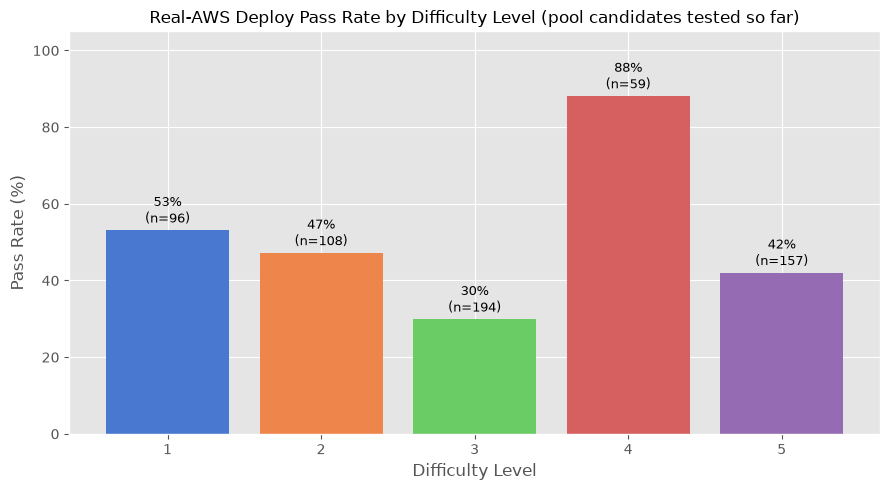

,difficulty,dest_file,deploy_status,error_preview
0,5,cfn_templates_greenfield/Sage-Bionetworks__Synapse-Stack-Builder/src/test/resources/vpc/private-...,ROLLBACK_COMPLETE,"bedrockagentVPCEndpoint: Resource handler returned message: "" (Service: Ec2, Status Code: 400, R..."
1,5,cfn_templates/widdix__aws-cf-templates/ecs/service-cluster-alb.yaml,ROLLBACK_COMPLETE,ROLLBACK_COMPLETE: no StackStatusReason or FAILED resource event found
2,5,cfn_templates/aws-samples__amazon-bedrock-agents-healthcare-lifesciences/multi_agent_collaborati...,ROLLBACK_FAILED,The following resource(s) failed to delete: [Collection].
3,5,cfn_templates/aws-samples__sample-nih-genai-assistant/bucketfiles/nih-grants-api.yaml,ROLLBACK_COMPLETE,"CognitoAuthorizer: Resource handler returned message: ""ProviderARNs need to be valid Cognito Use..."
4,5,cfn_templates/aws-samples__sample-nih-genai-assistant/bucketfiles/nih-grants-ws-api.yaml,ROLLBACK_COMPLETE,"NIHWSFunction: Resource handler returned message: ""Error occurred while GetObject. S3 Error Code..."
...,...,...,...,...
261,1,cfn_templates/eijikominami__aws-cloudformation-templates/notification/templates/chatbot.yaml,ROLLBACK_COMPLETE,cfn-eval-gt-check-95e58257af: Validation failed with 2 error(s). Call DescribeEvents to retrieve...
262,1,cfn_templates/paulvitic__peof/.aws/ecs/ingress/service-discovery-internal.yml,ROLLBACK_COMPLETE,ROLLBACK_COMPLETE: no StackStatusReason or FAILED resource event found
263,1,cfn_templates/aws-cloudformation__aws-cloudformation-samples/hooks/python-hooks/resource-tags/ex...,ROLLBACK_COMPLETE,ROLLBACK_COMPLETE: no StackStatusReason or FAILED resource event found
264,1,cfn_templates/Tianyi2__IRIS/data/cloudformation_collected_templates_new/template_13710_ecs-task-...,ROLLBACK_COMPLETE,"WorkerTaskDefinition: Resource handler returned message: ""Invalid request provided: Create TaskD..."


/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_7163/3237486538.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


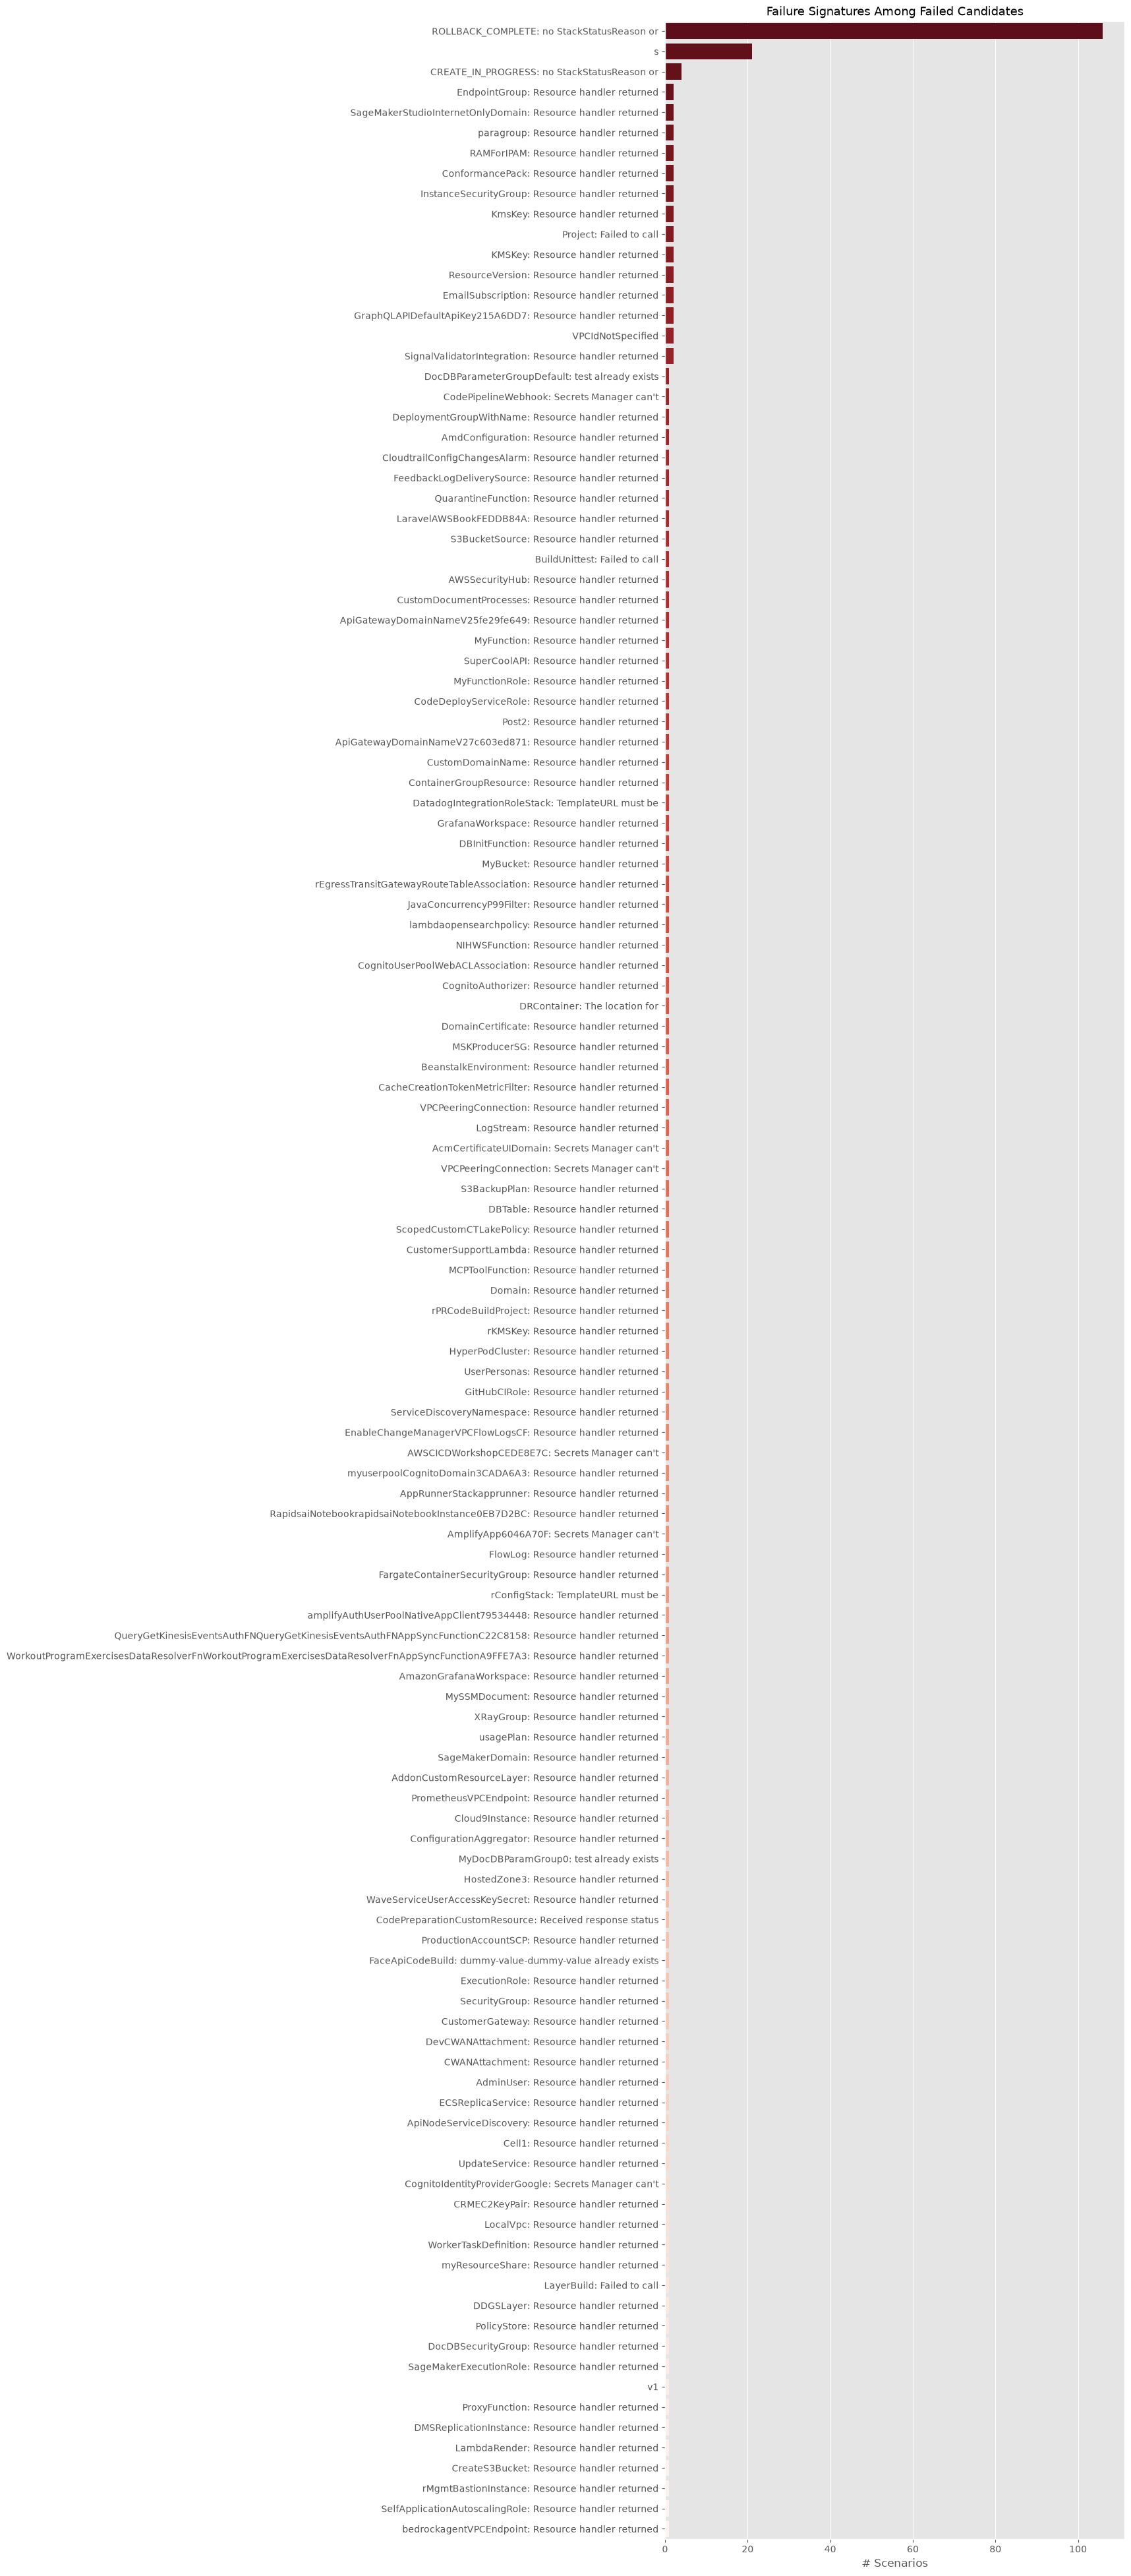


Candidates likely worth a minimal-fix triage pass (mechanical, verifiable, single-cause failures -- not external dependencies):
  [106x] ROLLBACK_COMPLETE: no StackStatusReason or
         - cfn_templates/widdix__aws-cf-templates/ecs/service-cluster-alb.yaml
         - cfn_templates/aws-samples__aws-service-catalog-reference-architectures/blog_content/securing-third-party-data-and-ml-apps/admin-setup-app.yaml
         - cfn_templates/aws-samples__cfn101-workshop/code/workspace/architecting-templates/application.template
         - cfn_templates/aws-samples__aws-hpc-recipes/recipes/pcs/cfd_cluster/assets/cluster-launch-templates.yaml
         - cfn_templates/aws-samples__aws-hpc-recipes/recipes/pcs/isolated_pcs/assets/cluster/pcs-isolated-cluster.yaml
         ... and 101 more
  [21x] s                                       
         - cfn_templates/kyhau__aws-tools/FinOps/cfn/cost-anomaly-detection.yml
         - cfn_templates/aws-cloudformation__rain/internal/cmd/build/tmpl/eventbrid

In [36]:
# ── 4b. Real-AWS Failure Analytics ────────────────────────────────────────────
# Failure-triage view over whatever's been tested so far in
# ground_truth_deploy_check_aws.csv, joined against the pool (section 1)
# rather than any frozen benchmark file -- covers every candidate ever
# tested, not just ones that happen to be in the current 250. Same
# triage discipline as the L5/real-AWS minimal-fix backlog documented in
# CLAUDE.md: distinguish a genuine, mechanical, verifiable content bug from
# an external dependency or a needs-live-debugging case before touching
# anything.
GT_DEPLOY_CACHE_PATH_ANALYTICS = DATASET_DIR / 'ground_truth_deploy_check_aws.csv'

if not GT_DEPLOY_CACHE_PATH_ANALYTICS.exists():
    print(f'⚠️ {GT_DEPLOY_CACHE_PATH_ANALYTICS.name} not found -- run the deploy-check section above '
          f'first (with RUN_DEPLOYMENT = True) to generate results.')
else:
    gt_results_analytics = pd.read_csv(GT_DEPLOY_CACHE_PATH_ANALYTICS)
    gt = df_pool.merge(gt_results_analytics, on='content_hash', how='inner')

    n_checked = len(gt)
    n_total = len(df_pool)
    n_pass = (gt['deploy_pass'] == True).sum()
    n_fail = (gt['deploy_pass'] == False).sum()
    n_error = gt['deploy_pass'].isna().sum()

    print(f'Checked so far: {n_checked} / {n_total} pool candidates ({n_checked / n_total:.1%})')
    print(f'  ✅ Deployed successfully : {n_pass} ({n_pass / n_checked:.1%})' if n_checked else '')
    print(f'  ❌ Deploy failed         : {n_fail} ({n_fail / n_checked:.1%})' if n_checked else '')
    print(f'  ⚠️  Validate/error/skip   : {n_error} ({n_error / n_checked:.1%})' if n_checked else '')

    if 'destroy_pass' in gt.columns:
        orphaned = gt[gt['destroy_pass'] == False]
        if not orphaned.empty:
            print(f"\n🚨 {len(orphaned)} stack(s) FAILED TO DELETE and may still exist in AWS:")
            cols = [c for c in ['dest_file', 'deployed_stack_name', 'destroy_error'] if c in orphaned.columns]
            with pd.option_context('display.max_colwidth', 120, 'display.width', 220):
                display(orphaned[cols].reset_index(drop=True))
            print('   Check the AWS Console / `aws cloudformation describe-stacks --profile default` directly.')
        else:
            n_attempted = gt['destroy_pass'].notna().sum()
            print(f'\n🧹 Cleanup: {n_attempted} stack(s) attempted deletion, 0 orphaned.')

    pass_by_diff = gt.groupby('difficulty')['deploy_pass'].apply(lambda s: (s == True).mean() * 100)
    counts_by_diff = gt.groupby('difficulty').size()

    plt.figure(figsize=(9, 5))
    bars = plt.bar(pass_by_diff.index.astype(str), pass_by_diff.values, color=sns.color_palette('muted'))
    plt.title('Real-AWS Deploy Pass Rate by Difficulty Level (pool candidates tested so far)', fontsize=12)
    plt.xlabel('Difficulty Level')
    plt.ylabel('Pass Rate (%)')
    plt.ylim(0, 105)
    for bar, diff in zip(bars, pass_by_diff.index):
        n = counts_by_diff[diff]
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                  f'{bar.get_height():.0f}%\n(n={n})', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    failed = gt[gt['deploy_pass'] == False].copy()
    if not failed.empty:
        failed['error_preview'] = failed['deploy_error'].astype(str).str.slice(0, 100)
        cols = [c for c in ['difficulty', 'dest_file', 'deploy_status', 'error_preview'] if c in failed.columns]
        with pd.option_context('display.max_colwidth', 100, 'display.width', 220):
            display(failed.sort_values('difficulty', ascending=False)[cols].reset_index(drop=True))
    else:
        print('\n🎉 No failures among checked candidates so far.')

    if not failed.empty:
        def _error_signature(msg):
            m = re.search(r'\(([A-Za-z][A-Za-z0-9_.]*)\)', str(msg))
            if m:
                return m.group(1)
            return ' '.join(str(msg).split()[:4]) or 'Unknown'

        failed['error_signature'] = failed['deploy_error'].apply(_error_signature)
        sig_counts = failed['error_signature'].value_counts()

        plt.figure(figsize=(9, max(3, 0.4 * len(sig_counts))))
        sns.barplot(y=sig_counts.index, x=sig_counts.values, hue=sig_counts.index,
                    palette='Reds_r', legend=False)
        plt.title('Failure Signatures Among Failed Candidates', fontsize=13)
        plt.xlabel('# Scenarios')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()

        print('\nCandidates likely worth a minimal-fix triage pass (mechanical, verifiable, '
              'single-cause failures -- not external dependencies):')
        for sig, cnt in sig_counts.items():
            examples = failed[failed['error_signature'] == sig]['dest_file'].tolist()
            print(f'  [{cnt:2d}x] {sig:<40s}')
            for ex in examples[:5]:
                print(f'         - {ex}')
            if len(examples) > 5:
                print(f'         ... and {len(examples) - 5} more')


In [101]:
# ── 5. Cost-Safety Sweep (aws-nuke) ───────────────────────────────────────────
# The deploy-check cell above already deletes each stack it creates and waits
# for that deletion to confirm (see destroy_pass/destroy_error in the cache).
# This cell is the backstop for anything that survives that anyway -- a stack
# whose delete_stack failed and was already flagged, a resource the template
# created outside CloudFormation's own tracking, or anything left over from
# an interrupted run. It runs a FULL-ACCOUNT aws-nuke sweep against the
# `default` profile using `nuke-config.yml` (which excludes only the "root"
# IAM user your CLI credentials belong to -- see that file's comments).
#
# Run this either:
#   - right after a deploy-check session (RUN_NUKE_SWEEP = False, run this
#     cell immediately after cell 12), or
#   - on its own, less frequently, independent of any deploy-check run --
#     this cell doesn't depend on anything the deploy-check cell defined.
#
# ⚠️  UNLIKE a manual `aws-nuke run`, this uses --no-prompt: once
# RUN_NUKE_SWEEP is True there is NO interactive confirmation before it
# deletes things -- that's the whole point of "automate this," but it means
# there's no human checkpoint left. Test manually first
# (`aws-nuke run --profile default -c nuke-config.yml --no-alias-check`,
# dry-run, review the output) before ever flipping this to True. Every run's
# full output is saved to a timestamped log under
# dataset/nuke_logs/ regardless of outcome, so a run can always be audited
# after the fact even though it's unattended.
RUN_NUKE_SWEEP = True

import subprocess
from datetime import datetime

NUKE_CONFIG_PATH = Path('nuke-config.yml')
NUKE_LOG_DIR = DATASET_DIR / 'nuke_logs'

if not RUN_NUKE_SWEEP:
    print('⏸️  RUN_NUKE_SWEEP is False -- skipping. This is a full-account, unattended')
    print('   `aws-nuke run --no-dry-run --no-prompt` -- test manually with a plain dry run')
    print('   first, then set RUN_NUKE_SWEEP = True when you\'re confident in the config.')
else:
    if not NUKE_CONFIG_PATH.exists():
        raise FileNotFoundError(f'{NUKE_CONFIG_PATH} not found -- expected it next to this notebook.')

    NUKE_LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = NUKE_LOG_DIR / f"nuke_{datetime.now().strftime('%Y%m%dT%H%M%S')}.log"

    cmd = [
        'aws-nuke', 'run',
        '--profile', 'default',
        '-c', str(NUKE_CONFIG_PATH),
        '--no-alias-check',
        '--no-dry-run',
        '--no-prompt',
    ]
    print(f'🧨 Running: {" ".join(cmd)}')
    print(f'   Full output -> {log_path}')

    result = subprocess.run(cmd, capture_output=True, text=True, timeout=1800)
    log_path.write_text(f"$ {' '.join(cmd)}\n\n--- stdout ---\n{result.stdout}\n\n--- stderr ---\n{result.stderr}\n")

    print(f'\nExit code: {result.returncode}')
    print('--- last 40 lines of output ---')
    for line in (result.stdout + result.stderr).splitlines()[-40:]:
        print(line)

    if result.returncode != 0:
        print(f'\n🚨 aws-nuke exited non-zero -- read the full log at {log_path} before assuming the account is clean.')
    else:
        print(f'\n✅ Sweep completed. Full log at {log_path}.')


🧨 Running: aws-nuke run --profile default -c nuke-config.yml --no-alias-check --no-dry-run --no-prompt
   Full output -> cfn_benchmark/dataset/nuke_logs/nuke_20260826T025504.log

Exit code: 1
--- last 40 lines of output ---
BatchedDeleteIncomplete: some objects have failed to be deleted.
caused by: failed to perform batch operation on "AWSLogs/386347569109/CloudTrail-Digest/us-east-1/2026/08/21/386347569109_CloudTrail-Digest_us-east-1_cfn-eval-gt-check-42aa4acadb-StateTrail-KNPHXTxUrrX3_us-east-1_20260821T193542Z.json.gz" to "cfn-eval-gt-check-42aa4acadb-trailbucket-ktta0epra5l0":
AccessDenied: Access Denied because object protected by object lock.
failed to perform batch operation on "AWSLogs/386347569109/CloudTrail/us-east-1/2026/08/22/386347569109_CloudTrail_us-east-1_20260822T0005Z_hxEdW66THIL6TmCZ.json.gz" to "cfn-eval-gt-check-42aa4acadb-trailbucket-ktta0epra5l0":
AccessDenied: Access Denied because object protected by object lock.
failed to perform batch operation on "AWSLogs/38

In [ ]:
# ── 6. Post-Deploy: Disable AWS Services Enabled By Pre-flight ──────────────
# The pre-flight cell above enables several AWS services/settings that bill
# on an ONGOING basis for as long as they stay enabled (AWS Config per
# configuration-item-recorded + per-rule-evaluation, Security Hub per
# security-check + per-finding, Amazon Inspector for EC2 per instance-hour
# scanned once its 15-day free trial lapses) -- none of that is something
# aws-nuke's own resource sweep reliably reverses: aws-nuke deletes
# resources by ARN (stacks, buckets, the Config recorder/delivery-channel
# CFN stack), but Security Hub's and Inspector's "enabled" state are
# account-level service subscriptions, not resources with an ARN aws-nuke
# necessarily targets. Left enabled between benchmark runs, they keep
# billing for nothing. This cell explicitly reverses everything the
# pre-flight cell turned on, run AFTER the nuke sweep (so the Config
# recorder's own stack -- and anything it delivered into its S3 bucket --
# is already gone before this tries to disable the service around it).
#
# Idempotent (checks current state before acting, same pattern as the
# pre-flight cell) -- safe to run even if some/all of these were never
# enabled, or already disabled by a previous run of this same cell.
RUN_POSTFLIGHT_TEARDOWN = True

import os
import boto3
import botocore

AWS_PROFILE = 'default'
AWS_REGION = os.environ.get('AWS_REGION', 'us-east-1')

_PREFLIGHT_STACK_NAME = 'cfn-eval-gt-config-prereq'


def _postflight_config():
    cfn = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('cloudformation')
    configservice = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('config')
    s3 = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('s3')

    try:
        desc = cfn.describe_stacks(StackName=_PREFLIGHT_STACK_NAME)
        status = desc['Stacks'][0]['StackStatus']
    except botocore.exceptions.ClientError:
        print(f"✅ Prereq stack {_PREFLIGHT_STACK_NAME!r} doesn't exist -- nothing to tear down.")
        return

    print(f"🔧 Tearing down AWS Config prerequisite stack {_PREFLIGHT_STACK_NAME!r} (status={status})...")
    try:
        configservice.stop_configuration_recorder(ConfigurationRecorderName='default')
        print("   Stopped configuration recorder.")
    except botocore.exceptions.ClientError as e:
        print(f"   (recorder already stopped or missing: {e.response.get('Error', {}).get('Code', '')})")

    # The delivery channel's own S3 bucket must be empty before CFN can
    # delete it -- Config may have written config-item snapshots into it.
    bucket_name = None
    for res in cfn.list_stack_resources(StackName=_PREFLIGHT_STACK_NAME)['StackResourceSummaries']:
        if res['LogicalResourceId'] == 'ConfigBucket':
            bucket_name = res['PhysicalResourceId']
            break
    if bucket_name:
        paginator = s3.get_paginator('list_object_versions')
        to_delete = []
        for page in paginator.paginate(Bucket=bucket_name):
            for v in page.get('Versions', []) + page.get('DeleteMarkers', []):
                to_delete.append({'Key': v['Key'], 'VersionId': v['VersionId']})
        for i in range(0, len(to_delete), 1000):
            batch = to_delete[i:i + 1000]
            if batch:
                s3.delete_objects(Bucket=bucket_name, Delete={'Objects': batch})
        if to_delete:
            print(f"   Emptied {len(to_delete)} object(s) from {bucket_name} before stack deletion.")

    cfn.delete_stack(StackName=_PREFLIGHT_STACK_NAME)
    waiter = cfn.get_waiter('stack_delete_complete')
    waiter.wait(StackName=_PREFLIGHT_STACK_NAME, WaiterConfig={'Delay': 10, 'MaxAttempts': 60})
    print("✅ Config recorder + delivery channel + bucket + role deleted.")


def _postflight_security_hub():
    securityhub = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('securityhub')
    try:
        securityhub.describe_hub()
    except botocore.exceptions.ClientError as e:
        code = e.response.get('Error', {}).get('Code', '')
        if code in ('InvalidAccessException', 'ResourceNotFoundException'):
            print('✅ Security Hub already disabled -- nothing to do.')
            return
        raise

    print('🔧 Disabling Security Hub...')
    securityhub.disable_security_hub()
    print('✅ Security Hub disabled.')


def _postflight_inspector_ec2():
    inspector2 = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('inspector2')
    sts = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('sts')
    account_id = sts.get_caller_identity()['Account']

    status = inspector2.batch_get_account_status(accountIds=[account_id])
    resource_state = status['accounts'][0]['resourceState'] if status['accounts'] else {}
    ec2_state = resource_state.get('ec2', {}).get('status')
    if ec2_state in (None, 'DISABLED', 'DISABLING'):
        print('✅ Amazon Inspector for EC2 already disabled -- nothing to do.')
        return

    print('🔧 Disabling Amazon Inspector for EC2...')
    inspector2.disable(accountIds=[account_id], resourceTypes=['EC2'])
    print('✅ Amazon Inspector for EC2 disabled.')


def _postflight_ami_block_public_access():
    ec2 = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION).client('ec2')
    current = ec2.get_image_block_public_access_state()
    if current.get('ImageBlockPublicAccessState') == 'block-new-sharing':
        print('✅ EC2 AMI block-public-access already restored -- nothing to do.')
        return

    print('🔧 Restoring EC2 "Block Public Access for AMIs" to its default...')
    ec2.enable_image_block_public_access(ImageBlockPublicAccessState='block-new-sharing')
    print('✅ AMI block-public-access restored (this setting has no cost either way -- restored for symmetry).')


if not RUN_POSTFLIGHT_TEARDOWN:
    print('⏸️  RUN_POSTFLIGHT_TEARDOWN is False -- skipping. Set to True to disable everything the')
    print('   pre-flight cell turned on (AWS Config, Security Hub, Inspector-for-EC2, AMI public-access),')
    print('   so none of it keeps billing between benchmark runs.')
else:
    _postflight_config()
    _postflight_security_hub()
    _postflight_inspector_ec2()
    _postflight_ami_block_public_access()
    print('\n✅ Post-flight teardown complete -- account restored to its pre-benchmark state.')


In [46]:
# %%
# ── 6b. Merge Prompts from cfn_output.csv (gemini_cfn_prompt_generator.py) ────
# gemini_cfn_prompt_generator.py generates/reviews prompts for
# cfn_benchmark/dataset/final_benchmark_real_aws_with_prompts.csv independently
# (a separate, Playwright-driven Gemini-web-UI tool -- see
# review-benchmark/gemini_cfn_prompt_generator.py), writing its own output to
# review-benchmark/cfn_output.csv rather than touching the frozen benchmark
# files directly. This cell folds that output back in, keyed by content_hash
# (this benchmark's stable per-scenario identifier -- there is no scenario_id
# column here, unlike the Terraform track), and runs BEFORE section 7
# (assembly) / section 8 (eval export) so both stages see the merged prompts,
# not stale ones.
#
# Default is FILL-BLANKS-ONLY, not overwrite: a row's existing user_prompt may
# already be hand-reviewed/frozen from an earlier pass, and cfn_output.csv is
# not automatically assumed authoritative the way the Terraform track's own
# merge cell treats tf_output.csv once fully reviewed. Flip
# OVERWRITE_EXISTING_PROMPTS to True only once cfn_output.csv itself has been
# fully reviewed and is known-correct for every row it covers.
#
# Only non-blank, non-"ERROR:"-prefixed prompts are ever taken from
# cfn_output.csv. gemini_cfn_prompt_generator.py also writes a tag_verified
# column (its response-matches-request verification tag, added to guard
# against Gemini-chat "context bleed" -- see that script's own docstring) --
# rows where the tag could not be verified are still merged (per this
# project's "don't discard, just flag" convention), but counted and surfaced
# below so they get a manual double-check rather than being silently trusted.

REVIEWED_PROMPTS_CSV = Path('/Users/iksena/Documents/research/review-benchmark/cfn_output.csv')

# Set to True to unconditionally overwrite every matching content_hash's
# prompt with cfn_output.csv's version, even if the target file already has a
# non-blank prompt there. False (default) only fills currently-blank prompts.
OVERWRITE_EXISTING_PROMPTS = False

if not REVIEWED_PROMPTS_CSV.exists():
    print(f"⏸️  {REVIEWED_PROMPTS_CSV} not found -- skipping prompt merge.")
else:
    df_reviewed = pd.read_csv(REVIEWED_PROMPTS_CSV, dtype=str)
    if 'content_hash' not in df_reviewed.columns or 'user_prompt' not in df_reviewed.columns:
        raise ValueError(
            f"{REVIEWED_PROMPTS_CSV.name} is missing 'content_hash' or 'user_prompt' -- wrong file?"
        )

    # Never take a blank or "ERROR: ..." placeholder prompt into the frozen benchmark.
    df_reviewed_valid = df_reviewed[
        df_reviewed['user_prompt'].notna()
        & (df_reviewed['user_prompt'].str.strip() != '')
        & (~df_reviewed['user_prompt'].str.startswith('ERROR:'))
    ].drop_duplicates('content_hash', keep='last')

    n_unverified = 0
    if 'tag_verified' in df_reviewed_valid.columns:
        n_unverified = int((df_reviewed_valid['tag_verified'].astype(str).str.lower() != 'true').sum())

    reviewed_prompt_map = dict(zip(df_reviewed_valid['content_hash'], df_reviewed_valid['user_prompt']))
    print(f"Loaded {len(reviewed_prompt_map)} usable prompt(s) from {REVIEWED_PROMPTS_CSV.name} "
          f"({len(df_reviewed) - len(df_reviewed_valid)} row(s) skipped as blank/ERROR/duplicate).")
    if n_unverified:
        print(f"   ⚠️  {n_unverified} of those have tag_verified != True -- "
              f"gemini_cfn_prompt_generator.py could not confirm the response matched the "
              f"request for these; worth a manual re-check before fully trusting them.")

    for _target_path in [DATASET_DIR / 'final_benchmark_real_aws_with_prompts.csv',
                          DATASET_DIR / 'final_benchmark_real_aws_custom.csv']:
        if not _target_path.exists():
            print(f"⏸️  {_target_path.name} not found -- skipping.")
            continue

        df_target = pd.read_csv(_target_path)
        if 'content_hash' not in df_target.columns:
            print(f"⏸️  {_target_path.name} has no 'content_hash' column -- skipping.")
            continue

        # Guard against pandas inferring an Arrow-backed/all-NaN dtype for
        # user_prompt that raises LossySetitemError on a plain string .loc
        # assignment (hit once on the Terraform track's equivalent cell).
        df_target['user_prompt'] = df_target['user_prompt'].astype('object')

        has_match = df_target['content_hash'].isin(reviewed_prompt_map)
        new_values = df_target['content_hash'].map(reviewed_prompt_map)
        is_blank = df_target['user_prompt'].isna() | (df_target['user_prompt'].astype(str).str.strip() == '')
        n_no_match = int((~has_match).sum())

        if OVERWRITE_EXISTING_PROMPTS:
            eligible = has_match
            differs = df_target['user_prompt'].fillna('') != new_values.fillna('')
            actually_changed = eligible & differs
            n_written = int(actually_changed.sum())
            n_already_matched = int((eligible & ~differs).sum())

            df_target.loc[eligible, 'user_prompt'] = new_values[eligible]
            df_target.to_csv(_target_path, index=False)

            print(f"✅ {_target_path.name}: overwrote {n_written} row(s) with the prompt from "
                  f"{REVIEWED_PROMPTS_CSV.name} (by content_hash).")
            if n_already_matched:
                print(f"   ℹ️ {n_already_matched} row(s) already matched exactly -- no change.")
        else:
            eligible = has_match & is_blank
            n_written = int(eligible.sum())
            n_skipped_had_prompt = int((has_match & ~is_blank).sum())

            df_target.loc[eligible, 'user_prompt'] = new_values[eligible]
            df_target.to_csv(_target_path, index=False)

            print(f"✅ {_target_path.name}: filled {n_written} previously-blank row(s) from "
                  f"{REVIEWED_PROMPTS_CSV.name} (by content_hash).")
            if n_skipped_had_prompt:
                print(f"   ℹ️ {n_skipped_had_prompt} row(s) already had a non-blank prompt -- left "
                      f"untouched (set OVERWRITE_EXISTING_PROMPTS = True to force-overwrite these too).")

        if n_no_match:
            print(f"   ℹ️ {n_no_match} row(s) have no matching content_hash in "
                  f"{REVIEWED_PROMPTS_CSV.name} -- not yet processed by gemini_cfn_prompt_generator.py.")


Loaded 250 usable prompt(s) from cfn_output.csv (0 row(s) skipped as blank/ERROR/duplicate).
✅ final_benchmark_real_aws_with_prompts.csv: filled 0 previously-blank row(s) from cfn_output.csv (by content_hash).
   ℹ️ 250 row(s) already had a non-blank prompt -- left untouched (set OVERWRITE_EXISTING_PROMPTS = True to force-overwrite these too).
✅ final_benchmark_real_aws_custom.csv: filled 0 previously-blank row(s) from cfn_output.csv (by content_hash).
   ℹ️ 250 row(s) already had a non-blank prompt -- left untouched (set OVERWRITE_EXISTING_PROMPTS = True to force-overwrite these too).


In [47]:
# %%
# ── 7. Real-AWS Benchmark Assembly ────────────────────────────────────────────
# Mirrors cfn_benchmark_builder.ipynb's cell 14 (stable row_number
# reconciliation + sample_diverse backfill + greedy-drop-most-overrepresented
# for excess), but gates on REAL-AWS deploy_pass from
# ground_truth_deploy_check_aws.csv instead of the LocalStack-sourced
# cfn_benchmark.csv, and NEVER pads a level to 50 with untested/failing
# candidates -- a level is only ever reported "full" when 50 candidates have
# actually deployed successfully on real AWS. This benchmark has its own
# independent row_number space from final_benchmark_with_prompts.csv (the
# LocalStack benchmark) -- the two candidate sets differ, so forcing shared
# numbers across them would be more confusing than helpful, and every audit
# script in this project already joins eval results to ground truth within
# ONE file only.
import pandas as pd
import numpy as np
import difflib
from collections import defaultdict
from pathlib import Path

REAL_AWS_CUSTOM_CSV = DATASET_DIR / 'final_benchmark_real_aws_custom.csv'
REAL_AWS_PROMPTS_CSV = DATASET_DIR / 'final_benchmark_real_aws_with_prompts.csv'
GT_DEPLOY_CACHE_PATH = DATASET_DIR / 'ground_truth_deploy_check_aws.csv'
# A human-curated diff345 snapshot (row_number/ground_truth_path/prompt/
# difficulty) -- see the "Protected baseline" block below. Section 8a keeps
# this file refreshed to the latest successfully-frozen diff345 each time
# the export pipeline completes, so it always reflects "the last known-good
# state", not a one-time, ever-staler pin.
PROTECTED_BASELINE_CSV = DATASET_DIR / 'cfn_eval_benchmark_real_aws_diff345_v1.csv'

TARGETS_PER_LEVEL = {1: 50, 2: 50, 3: 50, 4: 50, 5: 50}

if not GT_DEPLOY_CACHE_PATH.exists():
    raise FileNotFoundError(
        f"{GT_DEPLOY_CACHE_PATH} not found -- run the real-AWS deploy-check section "
        f"(RUN_DEPLOYMENT = True) at least once first."
    )

gt_cache = pd.read_csv(GT_DEPLOY_CACHE_PATH)[['content_hash', 'deploy_pass']].drop_duplicates('content_hash')
df_deployable_real = df_pool.merge(gt_cache, on='content_hash', how='inner')
df_deployable_real = df_deployable_real[df_deployable_real['deploy_pass'] == True].copy()
df_deployable_real['content'] = df_deployable_real['dest_file'].apply(
    lambda d: (BASE_DIR / str(d)).read_text(encoding='utf-8', errors='ignore') if (BASE_DIR / str(d)).exists() else ''
)
print(f"Real-AWS-verified, lint+Trivy-clean candidates: {len(df_deployable_real):,}")

# ── Protected baseline: never silently drop an already-reviewed scenario ────
# just because its CURRENT content_hash has no real-AWS deploy_pass entry
# yet. A manual content fix (e.g. swapping a hardcoded out-of-scope region,
# or any future greenfield edit) changes the content_hash, so it has no
# deploy_pass history under the new hash until RUN_DEPLOYMENT is actually
# rerun -- without this, the reconciliation below (which used to require
# BOTH old_dest_files membership AND a real deploy_pass=True) would silently
# drop it and backfill the vacated slot with something else, discarding the
# fix with no warning. Observed 2026-08-31: 5 manually-fixed scenarios
# (region-literal fixes) vanished from a single resample this exact way.
# PROTECTED_BASELINE_CSV names an explicit, human-reviewed diff345 snapshot
# whose scenarios are guaranteed to survive resampling as long as they're
# STILL lint+Trivy-clean in df_pool -- a genuinely broken or
# quality-excluded file is never force-kept, only ones merely missing
# real-AWS confirmation under their current hash. Their protected
# row_number/prompt take precedence over whatever the (possibly
# already-drifted) REAL_AWS_PROMPTS_CSV currently says, since pinning them
# to a stable identity is the whole point.
protected_ground_truth_paths = set()
protected_row_map, protected_prompt_map = {}, {}
if PROTECTED_BASELINE_CSV.exists():
    df_protected = pd.read_csv(PROTECTED_BASELINE_CSV)
    protected_ground_truth_paths = set(df_protected['ground_truth_path'])
    protected_row_map = dict(zip(df_protected['ground_truth_path'], df_protected['row_number']))
    protected_prompt_map = dict(zip(df_protected['ground_truth_path'], df_protected['prompt']))
    print(f"🔒 Loaded {len(protected_ground_truth_paths)} protected scenario(s) from "
          f"{PROTECTED_BASELINE_CSV.name}.")

    protected_still_valid = protected_ground_truth_paths & set(df_pool['dest_file'])
    protected_broken = protected_ground_truth_paths - protected_still_valid
    if protected_broken:
        print(f"⚠️ {len(protected_broken)} protected scenario(s) are no longer lint+Trivy-clean "
              f"in the current pool and CANNOT be protected: {sorted(protected_broken)}")

    protected_missing_deploy = protected_still_valid - set(
        df_deployable_real.loc[df_deployable_real['dest_file'].isin(protected_still_valid), 'dest_file']
    )
    if protected_missing_deploy:
        df_protected_extra = df_pool[df_pool['dest_file'].isin(protected_missing_deploy)].copy()
        df_protected_extra['deploy_pass'] = pd.NA  # no real-AWS confirmation yet -- ride along regardless
        df_protected_extra['content'] = df_protected_extra['dest_file'].apply(
            lambda d: (BASE_DIR / str(d)).read_text(encoding='utf-8', errors='ignore') if (BASE_DIR / str(d)).exists() else ''
        )
        print(f"🔒 {len(df_protected_extra)} protected scenario(s) have no real-AWS deploy_pass entry "
              f"under their current content_hash yet -- carried through anyway: "
              f"{sorted(df_protected_extra['dest_file'].tolist())}")
        df_deployable_real = pd.concat([df_deployable_real, df_protected_extra], ignore_index=True, sort=False)
else:
    print(f"ℹ️ No protected baseline found at {PROTECTED_BASELINE_CSV.name} -- skipping.")

# ── Reconcile against THIS benchmark's own previously-frozen file (not the
# LocalStack one) -- stable row_number per dest_file across reruns.
existing_row_map, existing_prompt_map, existing_difficulty_map = {}, {}, {}
existing_extra_maps = {}
max_existing_row_number = -1
old_dest_files = set()

if REAL_AWS_PROMPTS_CSV.exists():
    df_old = pd.read_csv(REAL_AWS_PROMPTS_CSV)
    existing_row_map = dict(zip(df_old['dest_file'], df_old['row_number']))
    max_existing_row_number = int(df_old['row_number'].max())
    existing_prompt_map = dict(zip(df_old['dest_file'], df_old['user_prompt']))
    existing_difficulty_map = dict(zip(df_old['dest_file'], df_old['difficulty']))
    old_dest_files = set(df_old['dest_file'])
    extra_cols = [c for c in df_old.columns if c not in df_deployable_real.columns
                  and c not in ('dest_file', 'row_number', 'user_prompt')]
    existing_extra_maps = {c: dict(zip(df_old['dest_file'], df_old[c])) for c in extra_cols}
    print(f"Loaded existing real-AWS benchmark: {len(df_old)} scenarios.")
else:
    print("No existing real-AWS benchmark found -- building from scratch.")

if protected_row_map:
    max_existing_row_number = max(max_existing_row_number, int(max(protected_row_map.values())))

# ── Carry through ALL currently-existing rows that are merely untested under
# their current content_hash (not confirmed failing) -- generalizes the
# protected-baseline "don't drop just because it's unconfirmed yet" logic
# above from the diff345 (L3-5) snapshot to every row already in
# final_benchmark_real_aws_with_prompts.csv across ALL levels (L1-5). A row
# that IS confirmed-failing under its current hash (deploy_pass == False) is
# deliberately NOT protected here -- it genuinely needs to be resampled or
# fixed, same as before. Without this, an existing row whose current content
# simply hasn't been real-AWS-tested yet (the overwhelmingly common case,
# since RUN_DEPLOYMENT only tests a bounded queue per run) would be silently
# dropped and replaced by a random resample on every rerun, discarding both
# the row and its already-written prompt for no reason.
if old_dest_files:
    gt_by_hash = dict(zip(gt_cache['content_hash'], gt_cache['deploy_pass']))
    pool_hash_by_dest = dict(zip(df_pool['dest_file'], df_pool['content_hash']))
    existing_missing_deploy = (old_dest_files & set(df_pool['dest_file'])) - set(df_deployable_real['dest_file'])
    existing_confirmed_failed = {
        d for d in existing_missing_deploy
        if gt_by_hash.get(pool_hash_by_dest.get(d)) == False
    }
    existing_untested = existing_missing_deploy - existing_confirmed_failed
    if existing_untested:
        df_existing_extra = df_pool[df_pool['dest_file'].isin(existing_untested)].copy()
        df_existing_extra['deploy_pass'] = pd.NA
        df_existing_extra['content'] = df_existing_extra['dest_file'].apply(
            lambda d: (BASE_DIR / str(d)).read_text(encoding='utf-8', errors='ignore') if (BASE_DIR / str(d)).exists() else ''
        )
        print(f"📌 {len(df_existing_extra)} existing scenario(s) have no real-AWS deploy_pass entry "
              f"under their current content_hash yet -- carried through (not confirmed failing) "
              f"rather than randomly resampled.")
        df_deployable_real = pd.concat([df_deployable_real, df_existing_extra], ignore_index=True, sort=False)
    if existing_confirmed_failed:
        print(f"❌ {len(existing_confirmed_failed)} existing scenario(s) have a CONFIRMED real-AWS "
              f"failure under their current content_hash -- NOT carried through, eligible for "
              f"resampling: {sorted(existing_confirmed_failed)}")


# This benchmark is assembled entirely independently of
# final_benchmark_with_prompts.csv (the LocalStack benchmark) -- no prompt
# reuse from it, no row_number sharing, no read of it at all. Every newly
# sampled row gets a blank user_prompt, filled in afterward by running
# generate_cfn_prompts.py pointed at this file via CFN_PROMPTS_CSV.

# MANUAL_EXCLUDE_SET / sample_diverse / _block_key come from the pool section above.
surviving_dest_files = (old_dest_files & set(df_deployable_real['dest_file'])) - MANUAL_EXCLUDE_SET
protected_restore = (protected_ground_truth_paths & set(df_deployable_real['dest_file'])) - MANUAL_EXCLUDE_SET
newly_restored = protected_restore - surviving_dest_files
if newly_restored:
    print(f"🔒 Restoring {len(newly_restored)} protected scenario(s) a previous run had dropped: "
          f"{sorted(newly_restored)}")
surviving_dest_files |= protected_restore

df_kept = df_deployable_real[df_deployable_real['dest_file'].isin(surviving_dest_files)].copy()
# Protected row_number/prompt take precedence over the (possibly
# already-drifted) existing_* maps for protected scenarios specifically --
# everything else resolves exactly as before.
combined_row_map = {**existing_row_map, **protected_row_map}
combined_prompt_map = {**existing_prompt_map, **protected_prompt_map}
df_kept['row_number'] = df_kept['dest_file'].map(combined_row_map)
df_kept['user_prompt'] = df_kept['dest_file'].map(combined_prompt_map)
for _col, _mapping in existing_extra_maps.items():
    df_kept[_col] = df_kept['dest_file'].map(_mapping)

kept_by_block = defaultdict(list)
for _, row in df_kept.iterrows():
    kept_by_block[_block_key(row)].append(row['content'])

final_dfs = []
next_row_number = max_existing_row_number + 1
scenarios_dropped, scenarios_added = [], []
level_status = []

print("\n⚖️ Assembling real-AWS benchmark (target 50/level, honest shortfall reporting)...")

for level in range(1, 6):
    target = TARGETS_PER_LEVEL.get(level, 0)
    df_lvl_kept = df_kept[df_kept['difficulty'] == level].copy()
    n_kept = len(df_lvl_kept)
    sampled = pd.DataFrame()

    if n_kept > target:
        excess = n_kept - target
        protected_in_level = set(df_lvl_kept.loc[
            df_lvl_kept['dest_file'].isin(protected_ground_truth_paths), 'dest_file'
        ])
        df_lvl_kept = df_lvl_kept.set_index('aws_services')
        for _ in range(excess):
            # Never greedy-drop a protected scenario to make room -- walk the
            # over-represented-architecture ordering and skip past any whose
            # sole remaining candidate is protected.
            dropped_one = False
            for top_arch in df_lvl_kept.index.value_counts().index:
                arch_rows = df_lvl_kept.loc[[top_arch]]
                droppable = arch_rows[~arch_rows['dest_file'].isin(protected_in_level)]
                if droppable.empty:
                    continue
                row_to_drop = droppable.iloc[0]
                scenarios_dropped.append(row_to_drop['dest_file'])
                df_lvl_kept = df_lvl_kept[df_lvl_kept['dest_file'] != row_to_drop['dest_file']]
                dropped_one = True
                break
            if not dropped_one:
                print(f"  ⚠️ Level {level}: {excess} over target but every remaining excess "
                      f"candidate is protected -- leaving {len(df_lvl_kept)} in place rather "
                      f"than dropping a protected scenario.")
                break
        df_lvl_kept = df_lvl_kept.reset_index()
        print(f"  ➖ Level {level}: dropped {len(scenarios_dropped)} excess (redundant-first, "
              f"protected scenarios exempted) toward {target}.")

    elif n_kept < target:
        shortfall = target - n_kept
        candidates = df_deployable_real[
            (df_deployable_real['difficulty'] == level) &
            (~df_deployable_real['dest_file'].isin(df_kept['dest_file'])) &
            (~df_deployable_real['dest_file'].isin(MANUAL_EXCLUDE_SET))
        ].copy()

        ordered = sample_diverse(candidates, len(candidates), group_col='aws_services').to_dict('records')
        accepted = []
        accepted_content_by_block = defaultdict(list)
        for rec in ordered:
            if len(accepted) >= shortfall:
                break
            key = _block_key(rec)
            against = kept_by_block.get(key, []) + accepted_content_by_block.get(key, [])
            is_dup = any(difflib.SequenceMatcher(None, rec['content'], other).quick_ratio() >= 0.90 for other in against)
            if not is_dup:
                accepted.append(rec)
                accepted_content_by_block[key].append(rec['content'])
                scenarios_added.append(rec['dest_file'])

        sampled = pd.DataFrame(accepted)
        if not sampled.empty:
            assigned = list(range(next_row_number, next_row_number + len(sampled)))
            next_row_number += len(sampled)
            sampled['row_number'] = assigned
            sampled['user_prompt'] = np.nan
            df_lvl_kept = pd.concat([df_lvl_kept, sampled], ignore_index=True)

        n_have = len(df_lvl_kept)
        if n_have < target:
            print(f"  🚧 Level {level}: only {n_have}/{target} real-AWS-verified -- {target - n_have} short. "
                  f"See the testing-queue section's queue_by_level[{level}] for what to test next.")
        else:
            print(f"  ➕ Level {level}: kept {n_kept}, added {len(sampled)} real-AWS-verified to reach {n_have}.")

    else:
        print(f"  ✅ Level {level}: exactly {target} real-AWS-verified.")

    level_status.append({'difficulty': level, 'target': target, 'have': len(df_lvl_kept)})
    final_dfs.append(df_lvl_kept)

df_final = pd.concat(final_dfs, ignore_index=True).sort_values('row_number').reset_index(drop=True)
if 'content' in df_final.columns:
    df_final = df_final.drop(columns=['content'])

# Final safety net: a genuine row_number collision should never happen given
# the reconciliation above (protected numbers are folded into
# max_existing_row_number before any fresh number is ever handed out), but
# raise loudly rather than silently write a broken file if one somehow
# slips through -- matching this project's own row-number stability guard
# precedent (cfn_benchmark_builder.ipynb cell 14).
_dupe_rns = df_final['row_number'][df_final['row_number'].duplicated()].unique()
if len(_dupe_rns):
    raise AssertionError(
        f"❌ {len(_dupe_rns)} duplicate row_number value(s) after assembly: {sorted(_dupe_rns)} -- "
        f"NOT saving. This should be structurally impossible; investigate before rerunning."
    )

df_final.to_csv(REAL_AWS_CUSTOM_CSV, index=False)
df_final.to_csv(REAL_AWS_PROMPTS_CSV, index=False)

print(f"\n💾 Saved → {REAL_AWS_CUSTOM_CSV.name} and {REAL_AWS_PROMPTS_CSV.name} ({len(df_final)} rows)")
print("\nPer-level status:")
for s in level_status:
    flag = '✅' if s['have'] >= s['target'] else f"🚧 short by {s['target'] - s['have']}"
    print(f"  L{s['difficulty']}: {s['have']}/{s['target']}  {flag}")
if scenarios_dropped:
    print(f"\nDropped {len(scenarios_dropped)} scenario(s) this run.")
if scenarios_added:
    print(f"Added {len(scenarios_added)} scenario(s) this run.")

missing_prompts = df_final['user_prompt'].isna().sum()
if missing_prompts:
    print(f"\n⚠️ {missing_prompts} row(s) still need a prompt -- run:")
    print(f"   CFN_PROMPTS_CSV={REAL_AWS_PROMPTS_CSV} python3 generate_cfn_prompts.py")


Real-AWS-verified, lint+Trivy-clean candidates: 278
🔒 Loaded 150 protected scenario(s) from cfn_eval_benchmark_real_aws_diff345_v1.csv.
Loaded existing real-AWS benchmark: 250 scenarios.

⚖️ Assembling real-AWS benchmark (target 50/level, honest shortfall reporting)...
  ✅ Level 1: exactly 50 real-AWS-verified.
  ✅ Level 2: exactly 50 real-AWS-verified.
  ✅ Level 3: exactly 50 real-AWS-verified.
  ✅ Level 4: exactly 50 real-AWS-verified.
  ✅ Level 5: exactly 50 real-AWS-verified.

💾 Saved → final_benchmark_real_aws_custom.csv and final_benchmark_real_aws_with_prompts.csv (250 rows)

Per-level status:
  L1: 50/50  ✅
  L2: 50/50  ✅
  L3: 50/50  ✅
  L4: 50/50  ✅
  L5: 50/50  ✅


In [48]:
# %%
# ── 7b. Real-AWS Post-Resample Near-Duplicate Check ───────────────────────
# Section 1's dedup-aware sampling loop (_block_key + difflib check) only
# guards against introducing a NEW near-duplicate alongside the EXISTING
# kept set -- it never re-scans the kept set against itself. Two rows that
# each independently entered "kept" at different points in time (e.g. one
# carried forward across many reruns, another manually fixed into a new
# dest_file under cfn_templates_greenfield/) are never compared against
# each other, so a pre-existing near-duplicate pair can silently persist
# across every future resample. This cell runs TWO complementary checks
# against the freshly-assembled final_benchmark_real_aws_with_prompts.csv:
#
#   1. Content-similarity: same blocking-key + difflib.quick_ratio>=0.90
#      methodology already used elsewhere in the pipeline, checked across
#      ALL pairs (not just new-vs-kept).
#   2. Same-source-path: normalizes cfn_templates_greenfield/ back to
#      cfn_templates/ and flags any two rows pointing at the same
#      underlying repo file, REGARDLESS of textual similarity. This catches
#      the case a manual ground-truth edit diverges enough (by wording,
#      generalized parameters, etc.) to fall under the 0.90 content
#      threshold while still being the same real-world scenario counted
#      twice -- exactly what happened with rows 286/346 below.
#
# Same failure mode already diagnosed once in the LocalStack benchmark (see
# CLAUDE.md, rows 286/346 there) -- a manual greenfield fix and its own
# untouched original source file both entering "kept" independently.
#
# Remedy once a pair is confirmed: per this project's layered-dedup
# convention (see CLAUDE.md), add the dest_file you want dropped to
# MANUAL_EXCLUDE_DEST_FILES in section 1 (this notebook's own copy) and rerun
# cells 14/17 -- the resample loop will backfill a fresh, truly distinct
# replacement at the same row_number.
import difflib
from collections import defaultdict

PROMPTS_CSV = DATASET_DIR / 'final_benchmark_real_aws_with_prompts.csv'

df_check = pd.read_csv(PROMPTS_CSV)

def read_cfn_content(dest_file):
    p = BASE_DIR / str(dest_file)
    return p.read_text(encoding='utf-8', errors='ignore') if p.exists() else ''

df_check['content'] = df_check['dest_file'].apply(read_cfn_content)

# ── Check 1: content-similarity, block-key optimized ──────────────────────
def _block_key(row):
    return (row['n_resources'], frozenset(str(row.get('resource_types', '')).split(' | ')))

blocks = defaultdict(list)
for _, row in df_check.iterrows():
    blocks[_block_key(row)].append(row)

DUP_THRESHOLD = 0.90
content_dup_pairs = []
for key, rows in blocks.items():
    if len(rows) < 2:
        continue
    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            a, b = rows[i], rows[j]
            ratio = difflib.SequenceMatcher(None, a['content'], b['content']).quick_ratio()
            if ratio >= DUP_THRESHOLD:
                content_dup_pairs.append((a, b, ratio))

# ── Check 2: same normalized source path, any similarity ──────────────────
CONTENT_ROOTS = ['cfn_templates_greenfield/', 'cfn_templates/']

def normalize_source_path(dest_file):
    for root in CONTENT_ROOTS:
        if str(dest_file).startswith(root):
            return str(dest_file)[len(root):]
    return str(dest_file)

df_check['source_path_norm'] = df_check['dest_file'].apply(normalize_source_path)
path_groups = defaultdict(list)
for _, row in df_check.iterrows():
    path_groups[row['source_path_norm']].append(row)

source_path_dups = {path: rows for path, rows in path_groups.items() if len(rows) > 1}

any_found = bool(content_dup_pairs) or bool(source_path_dups)

if content_dup_pairs:
    print(f"⚠️ Content-similarity check: {len(content_dup_pairs)} near-duplicate pair(s) (quick_ratio >= {DUP_THRESHOLD}):")
    for a, b, ratio in sorted(content_dup_pairs, key=lambda t: -t[2]):
        print(f"\n  similarity={ratio:.3f}")
        print(f"    row {a['row_number']} (difficulty {a['difficulty']}): {a['dest_file']}")
        print(f"    row {b['row_number']} (difficulty {b['difficulty']}): {b['dest_file']}")
else:
    print(f"✅ Content-similarity check: no pairs found (quick_ratio >= {DUP_THRESHOLD}).")

print()
if source_path_dups:
    print(f"⚠️ Same-source-path check: {len(source_path_dups)} repo file(s) used by more than one row:")
    for path, rows in source_path_dups.items():
        print(f"\n  source: {path}")
        for row in rows:
            print(f"    row {row['row_number']} (difficulty {row['difficulty']}): {row['dest_file']}")
else:
    print("✅ Same-source-path check: no repo file is used by more than one row.")

if any_found:
    print("\nTo resolve: add the dest_file you want dropped to MANUAL_EXCLUDE_DEST_FILES in section 1 "
          "(this notebook's real-AWS pool section, kept in sync with cfn_benchmark_builder.ipynb's own "
          "cell 14) and rerun sections 1 and 7.")


✅ Content-similarity check: no pairs found (quick_ratio >= 0.9).

✅ Same-source-path check: no repo file is used by more than one row.


In [49]:
# %%
# ── 8. Format Real-AWS Dataset for Evaluation ─────────────────────────────────
import pandas as pd

PROMPTS_CSV = DATASET_DIR / 'final_benchmark_real_aws_with_prompts.csv'
FINAL_EVAL_CSV = DATASET_DIR / 'cfn_eval_benchmark_real_aws.csv'

if not PROMPTS_CSV.exists():
    raise FileNotFoundError(f"⚠️ {PROMPTS_CSV} not found. Run section 7 (Real-AWS Benchmark Assembly) "
                             f"first, then generate_cfn_prompts.py (pointed at this file via "
                             f"CFN_PROMPTS_CSV) to backfill prompts for newly sampled rows.")

# 1. Load the prompts dataset. Section 7 already seeds this file directly from the
#    reconciled final_benchmark_custom.csv (row_number carried over for kept
#    scenarios, freshly assigned for newly sampled ones), and
#    generate_cfn_prompts.py resumes from it in place -- so no separate
#    content_hash merge against a second "custom" CSV is needed here; that
#    merge was the source of the previous 'df_merged is not defined' bug.
df_prompts = pd.read_csv(PROMPTS_CSV)
print(f"Loaded {len(df_prompts)} total scenarios from {PROMPTS_CSV.name}")

missing_prompts = df_prompts['user_prompt'].isna().sum()
if missing_prompts:
    print(f"⚠️ {missing_prompts} row(s) still have no generated prompt -- "
          f"run:\n"
          f"   CFN_PROMPTS_CSV={PROMPTS_CSV} python3 generate_cfn_prompts.py\n"
          f"before finalising evaluation data.")

# 2. Format columns to match the standard evaluation pipeline.
#    row_number is preserved as-is from df_prompts (stable across pipeline
#    re-runs for scenarios that were kept; freshly assigned only for new ones).
df_out = pd.DataFrame({
    'row_number': df_prompts['row_number'],
    'ground_truth_path': df_prompts['dest_file'],
    'prompt': df_prompts['user_prompt'],
    'difficulty': df_prompts['difficulty'],
})
df_out = df_out.sort_values('row_number').reset_index(drop=True)

# 3. Sanity check: row_number must be unique (no accidental collisions between
#    kept and newly-sampled scenarios).
dupe_rows = df_out['row_number'].duplicated().sum()
if dupe_rows:
    raise ValueError(f"❌ {dupe_rows} duplicate row_number value(s) detected in the final dataset -- "
                      f"check section 7's row_number assignment before saving.")

# 4. Save to disk
df_out.to_csv(FINAL_EVAL_CSV, index=False)

print(f"\n✅ Successfully formatted {len(df_out)} rows for evaluation.")
print(f"📁 Saved to: {FINAL_EVAL_CSV}\n")

# Preview the final dataset
display(df_out.head())


Loaded 250 total scenarios from final_benchmark_real_aws_with_prompts.csv

✅ Successfully formatted 250 rows for evaluation.
📁 Saved to: cfn_benchmark/dataset/cfn_eval_benchmark_real_aws.csv



,row_number,ground_truth_path,prompt,difficulty
0,0.0,cfn_templates/esabitova__aws-digito-artifacts-...,We need a CloudFormation template that creates...,1
1,1.0,cfn_templates/Vaarun-C__DiagramsToCode/Classes...,We need a CloudFormation template that creates...,1
2,2.0,cfn_templates/aws-samples__aws-config-pci-fsbp...,We need a CloudFormation template that creates...,1
3,3.0,cfn_templates/aws-samples__sample-developer-tu...,We need a CloudFormation template that creates...,1
4,4.0,cfn_templates/aws-samples__apigw-multi-region-...,We need a CloudFormation template that creates...,1


In [50]:
# %%
# ── 8a. Diff345 Changelog (compare against the previously-frozen file) ───────
# Runs BEFORE section 8b overwrites cfn_eval_benchmark_real_aws_diff345.csv,
# so "old" here always means "whatever was frozen going into this run" --
# never a stale/arbitrary snapshot. Two things happen:
#   1. The current on-disk diff345 file (if any) is preserved verbatim as
#      cfn_eval_benchmark_real_aws_diff345_v1.csv -- this doubles as section
#      7's PROTECTED_BASELINE_CSV, so the scenario set frozen here is what
#      the NEXT assembly run is guaranteed not to silently drop, not just an
#      audit-trail copy. Keep this filename in sync with section 7's own
#      PROTECTED_BASELINE_CSV constant if either ever changes.
#   2. The row_number-keyed diff itself: which rows are newly added, which
#      were dropped, and for rows present in both, whether the prompt and/or
#      ground_truth_path changed -- distinguishing a prompt-only edit (this
#      review round's rubric fixes) from a ground-truth-path change (a
#      manual-fix greenfield swap) from a genuinely new/replaced scenario.
import pandas as pd

DIFF345_EVAL_CSV = DATASET_DIR / 'cfn_eval_benchmark_real_aws_diff345.csv'
DIFF345_OLD_CSV = DATASET_DIR / 'cfn_eval_benchmark_real_aws_diff345_v1.csv'

if not FINAL_EVAL_CSV.exists():
    raise FileNotFoundError(f"⚠️ {FINAL_EVAL_CSV} not found. Run section 8 (Format Real-AWS Dataset "
                             f"for Evaluation) first.")

# Recompute the diff345 slice section 8b is about to write -- same source file
# and column mapping, just not saved to disk yet.
df_full_eval = pd.read_csv(FINAL_EVAL_CSV)
df_new345 = df_full_eval[df_full_eval['difficulty'].isin([3, 4, 5])].copy()
df_new345 = df_new345.sort_values('row_number').reset_index(drop=True)

if not DIFF345_EVAL_CSV.exists():
    print(f"ℹ️ {DIFF345_EVAL_CSV.name} doesn't exist yet -- nothing to diff against "
          f"(this must be the first time section 8b has run). Skipping changelog; "
          f"all {len(df_new345)} rows will be written as a fresh file.")
else:
    df_old345 = pd.read_csv(DIFF345_EVAL_CSV)

    # Preserve the pre-this-run file verbatim before anything overwrites it.
    df_old345.to_csv(DIFF345_OLD_CSV, index=False)
    print(f"💾 Preserved the previous diff345 ({len(df_old345)} rows) → {DIFF345_OLD_CSV.name}\n")

    old_by_rn = df_old345.set_index('row_number')
    new_by_rn = df_new345.set_index('row_number')

    old_rns = set(old_by_rn.index)
    new_rns = set(new_by_rn.index)
    added_rns = sorted(new_rns - old_rns)
    removed_rns = sorted(old_rns - new_rns)
    shared_rns = sorted(old_rns & new_rns)

    changed = []  # (row_number, reasons list, old_path, new_path)
    for rn in shared_rns:
        o, n = old_by_rn.loc[rn], new_by_rn.loc[rn]
        reasons = []
        if o['ground_truth_path'] != n['ground_truth_path']:
            reasons.append('ground truth changed')
        if o['prompt'] != n['prompt']:
            reasons.append('prompt changed')
        if o['difficulty'] != n['difficulty']:
            reasons.append('difficulty changed')
        if reasons:
            changed.append({
                'row_number': rn,
                'reason': ' + '.join(reasons),
                'old_ground_truth_path': o['ground_truth_path'],
                'new_ground_truth_path': n['ground_truth_path'],
            })

    changed_row_numbers = sorted(c['row_number'] for c in changed)

    print(f"Diff345 changelog vs. previously-frozen file:")
    print(f"  Added row_numbers   : {added_rns if added_rns else '(none)'}")
    print(f"  Removed row_numbers : {removed_rns if removed_rns else '(none)'}")
    print(f"  Changed row_numbers : {changed_row_numbers if changed_row_numbers else '(none)'}")
    print(f"  Unchanged           : {len(shared_rns) - len(changed)} / {len(shared_rns)} shared rows")

    if added_rns:
        print(f"\nAdded rows ({len(added_rns)}):")
        for rn in added_rns:
            n = new_by_rn.loc[rn]
            print(f"  row {rn}: new scenario — {n['ground_truth_path']}")

    if removed_rns:
        print(f"\nRemoved rows ({len(removed_rns)}):")
        for rn in removed_rns:
            o = old_by_rn.loc[rn]
            print(f"  row {rn}: no longer in the benchmark — {o['ground_truth_path']}")

    if changed:
        print(f"\nChanged rows ({len(changed)}):")
        for c in changed:
            print(f"  row {c['row_number']}: {c['reason']}")
            if c['old_ground_truth_path'] != c['new_ground_truth_path']:
                print(f"      ground_truth_path: {c['old_ground_truth_path']}")
                print(f"                      -> {c['new_ground_truth_path']}")

    # DataFrame form for programmatic use / display in the notebook.
    df_diff345_changelog = pd.DataFrame(changed)
    if not df_diff345_changelog.empty:
        display(df_diff345_changelog)


💾 Preserved the previous diff345 (150 rows) → cfn_eval_benchmark_real_aws_diff345_v1.csv

Diff345 changelog vs. previously-frozen file:
  Added row_numbers   : (none)
  Removed row_numbers : (none)
  Changed row_numbers : (none)
  Unchanged           : 150 / 150 shared rows


In [51]:
# %%
# ── 8b. Format Real-AWS Dataset for Evaluation (L3/L4/L5 subset) ──────────────
# Same source file and column mapping as section 8, filtered down to just
# difficulty levels 3, 4, and 5 -- this is the slice the multi-agent
# evaluation is being prioritized against right now, mirroring the project's
# existing '_diff_345' naming convention already used for the LocalStack
# benchmark (see IaCGOD/data/cfn_eval_benchmark_diff_345.csv).
import pandas as pd

DIFF345_EVAL_CSV = DATASET_DIR / 'cfn_eval_benchmark_real_aws_diff345.csv'

if not FINAL_EVAL_CSV.exists():
    raise FileNotFoundError(f"⚠️ {FINAL_EVAL_CSV} not found. Run section 8 (Format Real-AWS Dataset "
                             f"for Evaluation) first.")

df_full_eval = pd.read_csv(FINAL_EVAL_CSV)
df_diff345 = df_full_eval[df_full_eval['difficulty'].isin([3, 4, 5])].copy()
df_diff345 = df_diff345.sort_values('row_number').reset_index(drop=True)

dupe_rows_345 = df_diff345['row_number'].duplicated().sum()
if dupe_rows_345:
    raise ValueError(f"❌ {dupe_rows_345} duplicate row_number value(s) detected in the L3/4/5 slice.")

missing_prompts_345 = df_diff345['prompt'].isna().sum()
if missing_prompts_345:
    print(f"⚠️ {missing_prompts_345} row(s) in the L3/4/5 slice still have no generated prompt.")

df_diff345.to_csv(DIFF345_EVAL_CSV, index=False)

print(f"✅ Formatted {len(df_diff345)} L3/L4/L5 rows for evaluation "
      f"({(df_diff345['difficulty'] == 3).sum()} L3, "
      f"{(df_diff345['difficulty'] == 4).sum()} L4, "
      f"{(df_diff345['difficulty'] == 5).sum()} L5).")
print(f"📁 Saved to: {DIFF345_EVAL_CSV}\n")

display(df_diff345.head())


✅ Formatted 150 L3/L4/L5 rows for evaluation (50 L3, 50 L4, 50 L5).
📁 Saved to: cfn_benchmark/dataset/cfn_eval_benchmark_real_aws_diff345.csv



,row_number,ground_truth_path,prompt,difficulty
0,70.0,cfn_templates/Tianyi2__IRIS/data/cloudformatio...,We need a CloudFormation template that creates...,3
1,71.0,cfn_templates/aws-samples__aws-cloud-complianc...,We need a CloudFormation template that creates...,3
2,72.0,cfn_templates/Barnard-PL-Labs__IaCAnalysis/pip...,We need a CloudFormation template that creates...,3
3,73.0,cfn_templates/Tianyi2__IaCGen/Data/groud_truth...,We need a CloudFormation template that creates...,3
4,74.0,cfn_templates/Tianyi2__IRIS/data/cloudformatio...,We need a CloudFormation template that creates...,3


LocalStack diff345: 150 rows -- {3: 50, 4: 50, 5: 50}
Real-AWS diff345:   150 rows -- {3: 50, 4: 50, 5: 50}

Scenario overlap (by ground_truth_path):
  Shared (deployable on both targets)      : 109
  Only in LocalStack diff345                : 41
  Only in Real-AWS diff345                  : 41
  Jaccard overlap                            : 57.1%


,Only LocalStack,Shared,Only Real-AWS
difficulty,,,
3,18,32,18
4,10,40,10
5,14,36,14


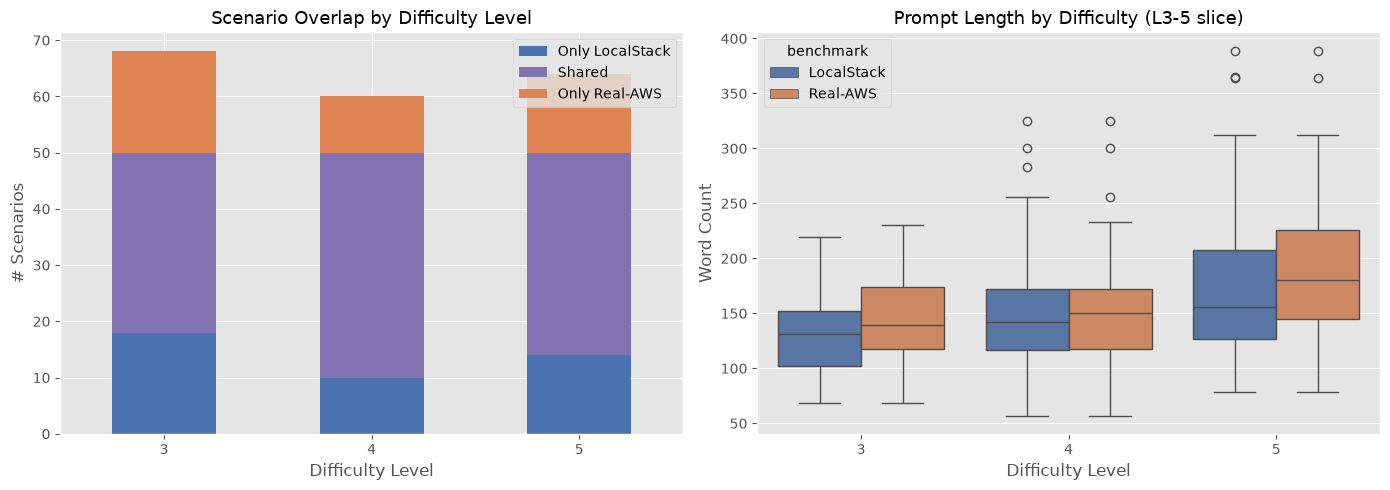


Prompt length (words), L3-5 slice only:
            count   mean    50%   min    max
benchmark                                   
LocalStack  150.0  152.8  143.5  57.0  389.0
Real-AWS    150.0  161.1  153.5  57.0  389.0


In [52]:
# %%
# ── 8c. Compare Real-AWS vs LocalStack L3/L4/L5 Benchmark (diff345) ───────────
# Direct comparison of the two "diff345" slices -- cfn_eval_benchmark_diff_345.csv
# (LocalStack-deployable, built by cfn_benchmark_builder.ipynb) vs
# cfn_eval_benchmark_real_aws_diff345.csv (real-AWS-deployable, section 8b above)
# -- both restricted to difficulty levels 3-5, the levels prioritized for the
# current multi-agent evaluation round. This is scoped to just these two files
# (not the full 250-scenario benchmarks compared in section 9 onward) since
# that's the exact pair the evaluation is being run against right now.
import pandas as pd

LOCALSTACK_DIFF345_CSV = DATASET_DIR / 'cfn_eval_benchmark_diff_345.csv'
REAL_AWS_DIFF345_CSV = DATASET_DIR / 'cfn_eval_benchmark_real_aws_diff345.csv'

if not LOCALSTACK_DIFF345_CSV.exists():
    raise FileNotFoundError(f"⚠️ {LOCALSTACK_DIFF345_CSV} not found -- this is produced by "
                             f"cfn_benchmark_builder.ipynb's own L3/4/5 export, not this notebook.")
if not REAL_AWS_DIFF345_CSV.exists():
    raise FileNotFoundError(f"⚠️ {REAL_AWS_DIFF345_CSV} not found -- run section 8b above first.")

df_ls345 = pd.read_csv(LOCALSTACK_DIFF345_CSV)
df_ra345 = pd.read_csv(REAL_AWS_DIFF345_CSV)

print(f"LocalStack diff345: {len(df_ls345)} rows -- "
      f"{df_ls345['difficulty'].value_counts().sort_index().to_dict()}")
print(f"Real-AWS diff345:   {len(df_ra345)} rows -- "
      f"{df_ra345['difficulty'].value_counts().sort_index().to_dict()}")

# 1. Scenario overlap by ground_truth_path -- both files share the same base
#    directory structure (cfn_benchmark/), so an exact path match is a
#    meaningful "same underlying scenario" signal. A manual-fix scenario whose
#    dest_file was rewritten (cfn_templates/... -> cfn_templates_greenfield/...)
#    for one benchmark but not the other will correctly show up as "only in
#    one" here, not as a false match.
ls_paths = set(df_ls345['ground_truth_path'])
ra_paths = set(df_ra345['ground_truth_path'])
shared_paths = ls_paths & ra_paths
only_ls_paths = ls_paths - ra_paths
only_ra_paths = ra_paths - ls_paths

print(f"\nScenario overlap (by ground_truth_path):")
print(f"  Shared (deployable on both targets)      : {len(shared_paths)}")
print(f"  Only in LocalStack diff345                : {len(only_ls_paths)}")
print(f"  Only in Real-AWS diff345                  : {len(only_ra_paths)}")
print(f"  Jaccard overlap                            : {len(shared_paths) / len(ls_paths | ra_paths):.1%}")

# 2. Overlap broken down by difficulty level.
overlap_rows = []
for lvl in [3, 4, 5]:
    lvl_ls = set(df_ls345.loc[df_ls345['difficulty'] == lvl, 'ground_truth_path'])
    lvl_ra = set(df_ra345.loc[df_ra345['difficulty'] == lvl, 'ground_truth_path'])
    overlap_rows.append({
        'difficulty': lvl,
        'Only LocalStack': len(lvl_ls - lvl_ra),
        'Shared': len(lvl_ls & lvl_ra),
        'Only Real-AWS': len(lvl_ra - lvl_ls),
    })
overlap_df = pd.DataFrame(overlap_rows).set_index('difficulty')
display(overlap_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overlap_df.plot(kind='bar', stacked=True, ax=axes[0],
                 color=['#4c72b0', '#8172b2', '#dd8452'])
axes[0].set_title('Scenario Overlap by Difficulty Level', fontsize=13)
axes[0].set_xlabel('Difficulty Level')
axes[0].set_ylabel('# Scenarios')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title=None)

# 3. Prompt length comparison for this specific L3-5 slice (independent of the
#    full-benchmark prompt-length comparison in section 17 further below).
df_ls345 = df_ls345.copy()
df_ra345 = df_ra345.copy()
df_ls345['prompt_word_count'] = df_ls345['prompt'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0)
df_ra345['prompt_word_count'] = df_ra345['prompt'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0)

df_ls345['benchmark'] = 'LocalStack'
df_ra345['benchmark'] = 'Real-AWS'
df_345_compare = pd.concat([df_ls345, df_ra345], ignore_index=True)

sns.boxplot(data=df_345_compare, x='difficulty', y='prompt_word_count', hue='benchmark',
            palette={'LocalStack': '#4c72b0', 'Real-AWS': '#dd8452'}, ax=axes[1])
axes[1].set_title('Prompt Length by Difficulty (L3-5 slice)', fontsize=13)
axes[1].set_xlabel('Difficulty Level')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

print(f"\nPrompt length (words), L3-5 slice only:")
print(df_345_compare.groupby('benchmark')['prompt_word_count'].describe()[
    ['count', 'mean', '50%', 'min', 'max']].round(1).to_string())


In [55]:
# ── 9. Load Both Frozen Benchmarks (for comparison) ───────────────────────────
# Everything above this point (sections 1-8) builds and gates the real-AWS
# benchmark independently, off the raw pipeline caches only. Everything
# below this point is pure description/comparison -- it's the only place in
# this notebook that reads the two FINAL frozen benchmark files, and it
# reads both of them side by side rather than favoring either one.
LOCALSTACK_BENCHMARK_CSV = DATASET_DIR / 'final_benchmark_with_prompts.csv'
REAL_AWS_BENCHMARK_CSV = DATASET_DIR / 'final_benchmark_real_aws_with_prompts.csv'

df_localstack = pd.read_csv(LOCALSTACK_BENCHMARK_CSV)
df_localstack['benchmark'] = 'LocalStack'
print(f"Loaded {len(df_localstack)} scenarios from {LOCALSTACK_BENCHMARK_CSV.name}")

if REAL_AWS_BENCHMARK_CSV.exists():
    df_real_aws = pd.read_csv(REAL_AWS_BENCHMARK_CSV)
    df_real_aws['benchmark'] = 'Real-AWS'
    print(f"Loaded {len(df_real_aws)} scenarios from {REAL_AWS_BENCHMARK_CSV.name}")
else:
    df_real_aws = pd.DataFrame(columns=list(df_localstack.columns))
    print(f"⚠️ {REAL_AWS_BENCHMARK_CSV.name} not found yet -- run the real-AWS assembly section "
          f"above at least once. Comparison charts below will show the LocalStack benchmark only.")

for _d, _name in ((df_localstack, 'LocalStack'), (df_real_aws, 'Real-AWS')):
    if len(_d) and len(_d) != _d['row_number'].nunique():
        print(f"⚠️ {_name} benchmark has duplicate row_number values -- check it before trusting "
              f"its charts below.")

BENCHMARK_PALETTE = {'LocalStack': '#4c72b0', 'Real-AWS': '#dd8452'}
BENCHMARK_ORDER = ['LocalStack', 'Real-AWS']

# One combined frame, used by every comparison chart below via hue='benchmark'.
df_compare = pd.concat([df_localstack, df_real_aws], ignore_index=True, sort=False)

print('\nScenario count by benchmark:')
print(df_compare['benchmark'].value_counts().reindex(BENCHMARK_ORDER).to_string())
print('\nDifficulty distribution by benchmark:')
print(df_compare.groupby('benchmark')['difficulty'].value_counts().unstack().reindex(BENCHMARK_ORDER).to_string())

# Prompt length, computed once here (not per-chart-section) so every section
# below can rely on it. Row-wise rather than a vectorized .str chain -- a
# mixed-dtype user_prompt column (some rows real strings, others actual NaN
# after pd.concat) makes .astype(str).str.split() unreliable; str(x) on a
# scalar always behaves.
def _word_count(x):
    return len(str(x).split()) if pd.notna(x) else 0

def _char_count(x):
    return len(str(x)) if pd.notna(x) else 0

df_compare['prompt_word_count'] = df_compare['user_prompt'].apply(_word_count)
df_compare['prompt_char_count'] = df_compare['user_prompt'].apply(_char_count)
df_compare['has_prompt'] = df_compare['user_prompt'].notna()


Loaded 250 scenarios from final_benchmark_with_prompts.csv
Loaded 250 scenarios from final_benchmark_real_aws_with_prompts.csv

Scenario count by benchmark:
benchmark
LocalStack    250
Real-AWS      250

Difficulty distribution by benchmark:
difficulty   1   2   3   4   5
benchmark                     
LocalStack  50  50  50  50  50
Real-AWS    50  50  50  50  50


,Difficulty Level,LoC (this benchmark),#Resources (this benchmark),LoC (DPIaC-Eval),#Resources (DPIaC-Eval)
0,1,< 80,< 2,< 50,< 2
1,2,80-149,2-3,< 100,< 4
2,3,150-249,4-7,< 150,< 6
3,4,250-399,8-11,< 200,< 12
4,5,>= 400,>= 12,>= 200,>= 12


Task was destroyed but it is pending!
task: <Task pending name='Task-346' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/iksena/miniconda3/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-347' coro=<Kernel.shell_main() running at /Users/iksena/miniconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/iksena/miniconda3/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/iksena/miniconda3/lib/python3.13/site-packages/matplotlib/transforms.py:193: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-347' coro=<Kernel.shell_main() running at /Users/iksena/miniconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


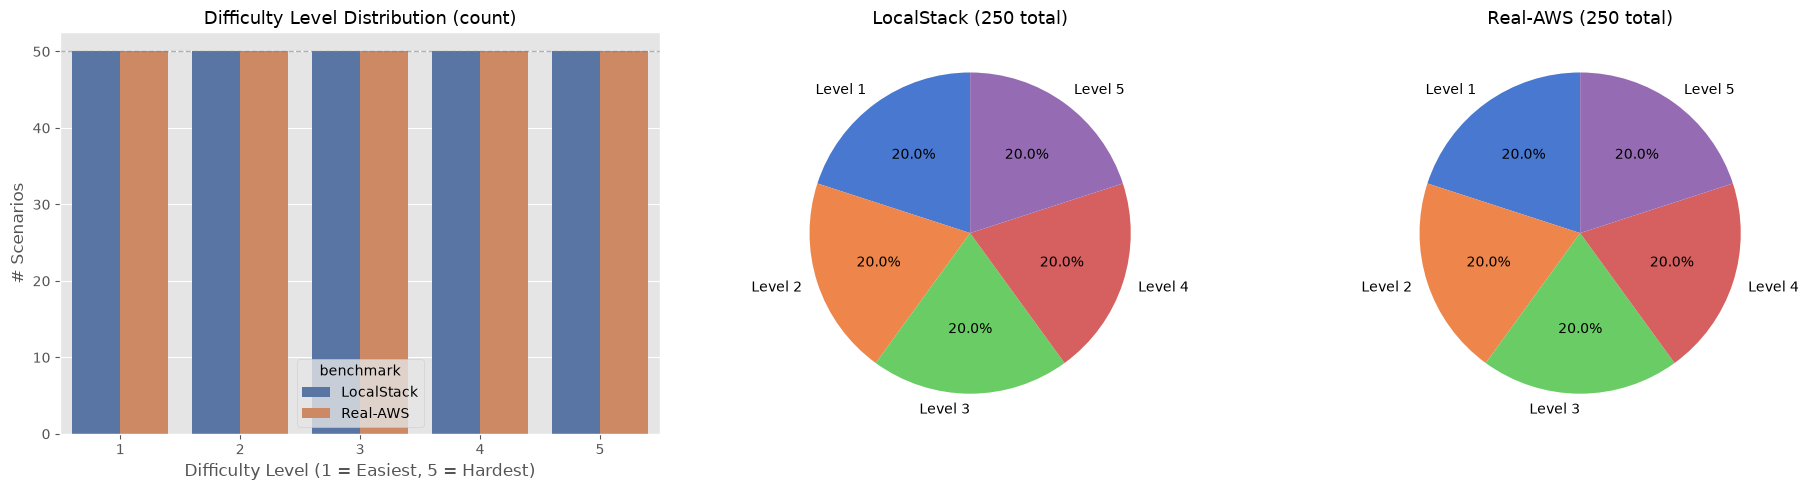

In [56]:
# ── 10. Difficulty-Level Methodology & Distribution ───────────────────────────
# Mirrors DPIaC-Eval's Table 1 (difficulty criteria) + Fig. 3b (difficulty
# distribution). Our own joint LOC x #Resource classifier (see CLAUDE.md,
# "Difficulty-level methodology") is TF-aligned rather than DPIaC-Eval's own
# thresholds -- shown side by side for reference. Both frozen benchmarks
# share the same classifier and 50/level target; shown together so any
# real-AWS shortfall (a level not yet at 50) is visible at a glance.
difficulty_criteria = pd.DataFrame({
    'Difficulty Level': [1, 2, 3, 4, 5],
    'LoC (this benchmark)':        ['< 80', '80-149', '150-249', '250-399', '>= 400'],
    '#Resources (this benchmark)': ['< 2',  '2-3',    '4-7',     '8-11',    '>= 12'],
    'LoC (DPIaC-Eval)':            ['< 50', '< 100',  '< 150',   '< 200',   '>= 200'],
    '#Resources (DPIaC-Eval)':     ['< 2',  '< 4',     '< 6',    '< 12',    '>= 12'],
})
display(difficulty_criteria)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.countplot(data=df_compare, x='difficulty', hue='benchmark', hue_order=BENCHMARK_ORDER,
              palette=BENCHMARK_PALETTE, ax=axes[0])
axes[0].set_title('Difficulty Level Distribution (count)', fontsize=13)
axes[0].set_xlabel('Difficulty Level (1 = Easiest, 5 = Hardest)')
axes[0].set_ylabel('# Scenarios')
axes[0].axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)

for ax, bench in zip(axes[1:], BENCHMARK_ORDER):
    d = df_compare[df_compare['benchmark'] == bench]
    if d.empty:
        ax.set_title(f'{bench} (not built yet)', fontsize=13)
        ax.axis('off')
        continue
    counts = d['difficulty'].value_counts().sort_index()
    ax.pie(counts.values, labels=[f'Level {i}' for i in counts.index],
           autopct='%1.1f%%', startangle=90, colors=sns.color_palette('muted'))
    ax.set_title(f'{bench} ({len(d)} total)', fontsize=13)

plt.tight_layout()
plt.show()


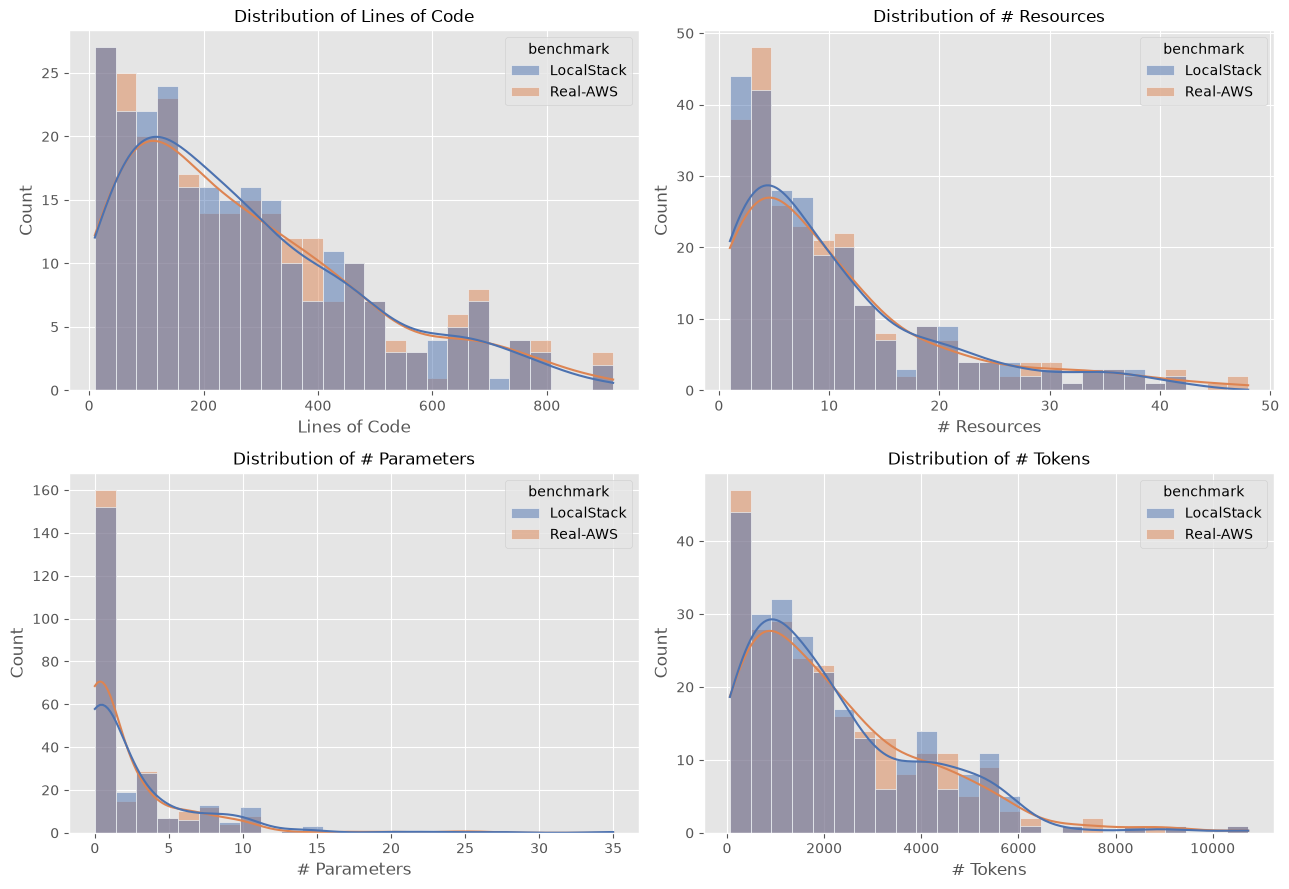

benchmark           LocalStack  Real-AWS
loc          count       250.0     250.0
             mean        269.1     272.6
             std         206.3     212.2
             min          10.0      10.0
             25%         105.0      96.2
             50%         222.5     225.5
             75%         400.8     392.8
             max         901.0     916.0
n_resources  count       250.0     250.0
             mean         10.3      10.9
             std           9.4      10.2
             min           1.0       1.0
             25%           4.0       3.0
             50%           7.0       8.0
             75%          13.8      14.0
             max          42.0      48.0
n_parameters count       250.0     250.0
             mean          2.7       2.3
             std           4.5       3.8
             min           0.0       0.0
             25%           0.0       0.0
             50%           1.0       1.0
             75%           3.0       3.0
             max

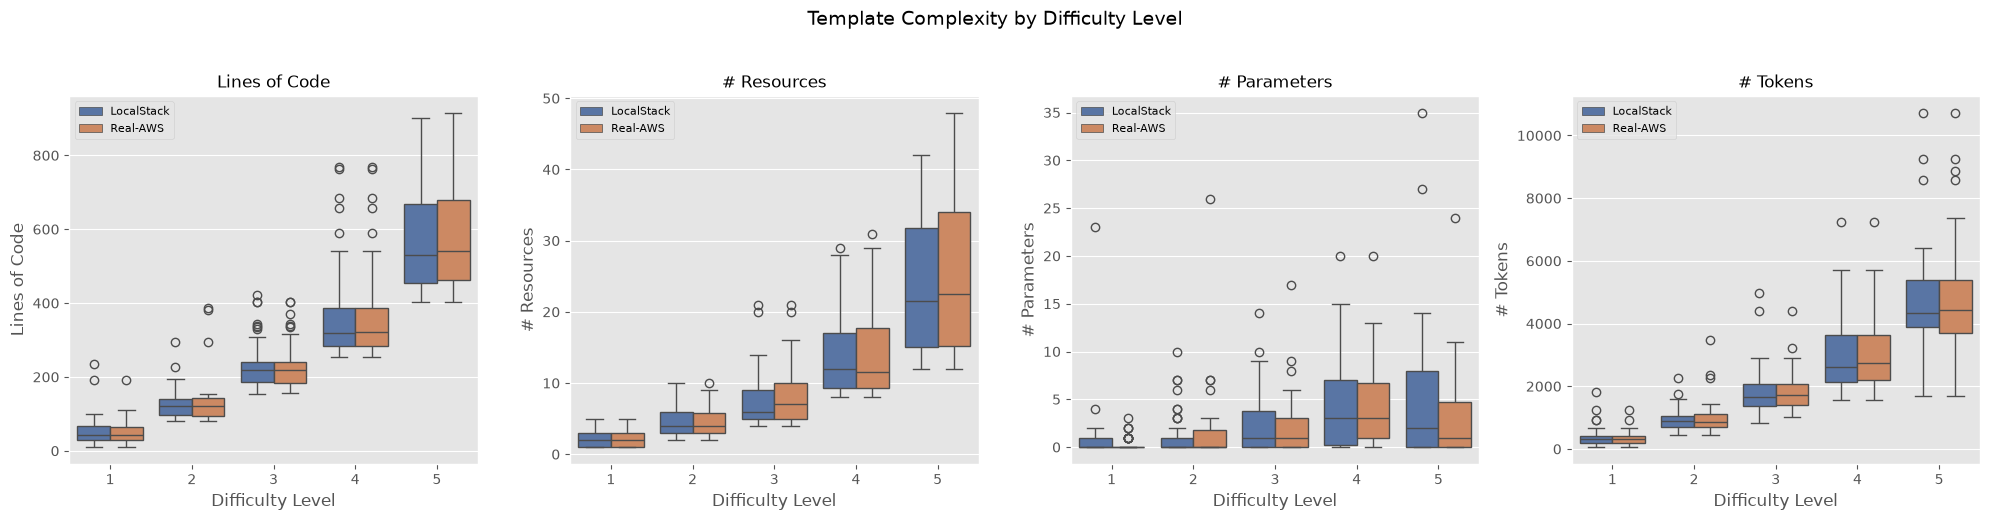

In [57]:
# ── 11. Template Complexity Distributions (LOC / Resources / Parameters / Tokens) ─
metrics = ['loc', 'n_resources', 'n_parameters', 'tokens']
metric_labels = {'loc': 'Lines of Code', 'n_resources': '# Resources',
                  'n_parameters': '# Parameters', 'tokens': '# Tokens'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, m in zip(axes.flat, metrics):
    sns.histplot(data=df_compare, x=m, hue='benchmark', hue_order=BENCHMARK_ORDER,
                 palette=BENCHMARK_PALETTE, bins=25, kde=True, ax=ax, alpha=0.5)
    ax.set_title(f'Distribution of {metric_labels[m]}', fontsize=12)
    ax.set_xlabel(metric_labels[m])
plt.tight_layout()
plt.show()

print(df_compare.groupby('benchmark')[metrics].describe().round(1).T.to_string())

# ── Complexity by difficulty level (validates the stratification visually) ──
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, m in zip(axes, metrics):
    sns.boxplot(data=df_compare, x='difficulty', y=m, hue='benchmark', hue_order=BENCHMARK_ORDER,
                palette=BENCHMARK_PALETTE, ax=ax)
    ax.set_title(metric_labels[m], fontsize=12)
    ax.set_xlabel('Difficulty Level')
    ax.set_ylabel(metric_labels[m])
    ax.legend(fontsize=8)
plt.suptitle('Template Complexity by Difficulty Level', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()


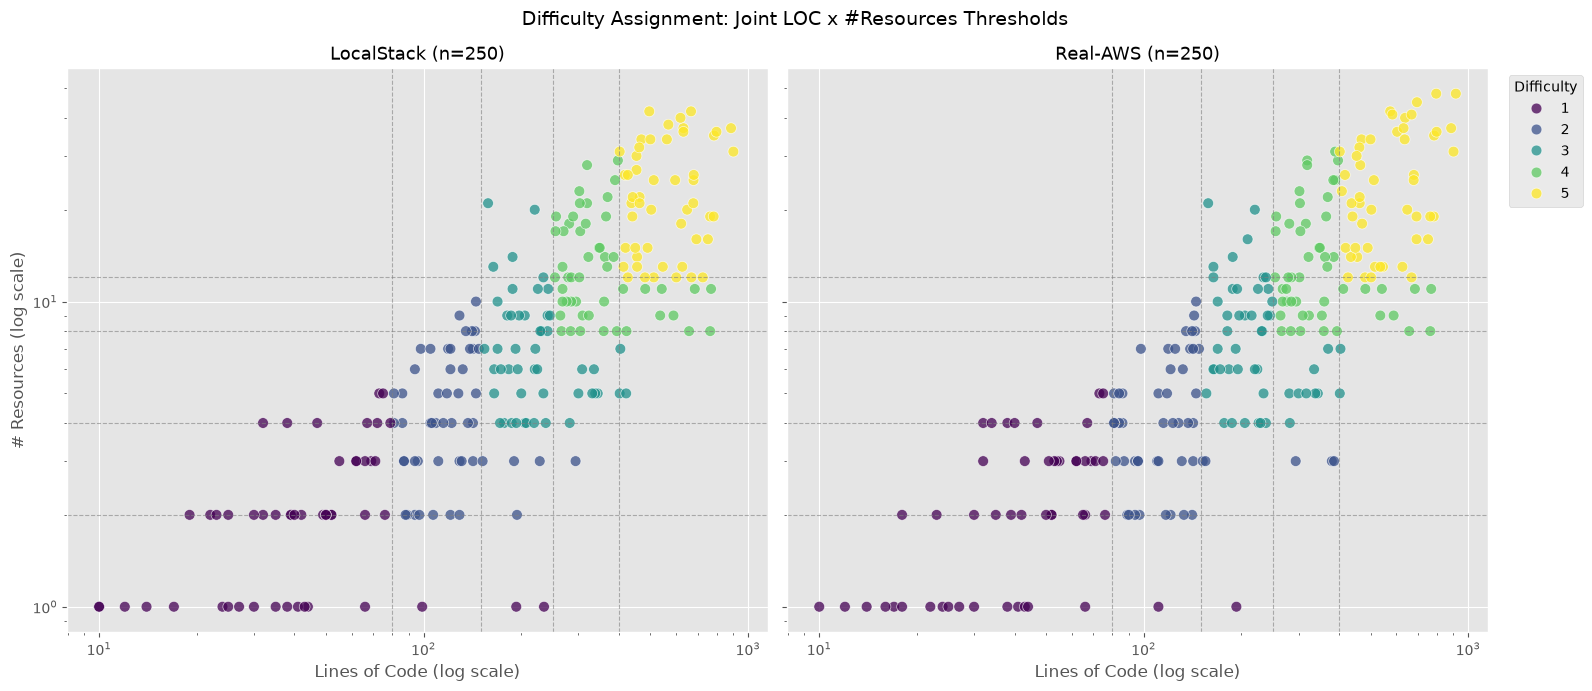

In [58]:
# ── 12. Joint LOC x Resource-Count Difficulty Boundary (this benchmark's own
#      classifier, visualized directly) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Draw the joint LOC x #Resource thresholds actually used by
# calculate_difficulty_cfn() (cell 6 of cfn_benchmark_builder.ipynb) so the
# scatter directly shows *why* each point landed at its difficulty level.
thresholds = [(80, 2), (150, 4), (250, 8), (400, 12)]

for i, (ax, bench) in enumerate(zip(axes, BENCHMARK_ORDER)):
    d = df_compare[df_compare['benchmark'] == bench]
    if d.empty:
        ax.set_title(f'{bench} (not built yet)', fontsize=13)
        ax.axis('off')
        continue
    sns.scatterplot(
        data=d, x='loc', y='n_resources', hue='difficulty', palette='viridis',
        s=60, alpha=0.75, edgecolor='white', linewidth=0.5, ax=ax,
        legend='full' if i == len(axes) - 1 else False,
    )
    for loc_t, res_t in thresholds:
        ax.axvline(loc_t, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.axhline(res_t, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'{bench} (n={len(d)})', fontsize=13)
    ax.set_xlabel('Lines of Code (log scale)')
    ax.set_ylabel('# Resources (log scale)')

if not df_compare[df_compare['benchmark'] == BENCHMARK_ORDER[-1]].empty:
    axes[-1].legend(title='Difficulty', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('Difficulty Assignment: Joint LOC x #Resources Thresholds', fontsize=14)
plt.tight_layout()
plt.show()


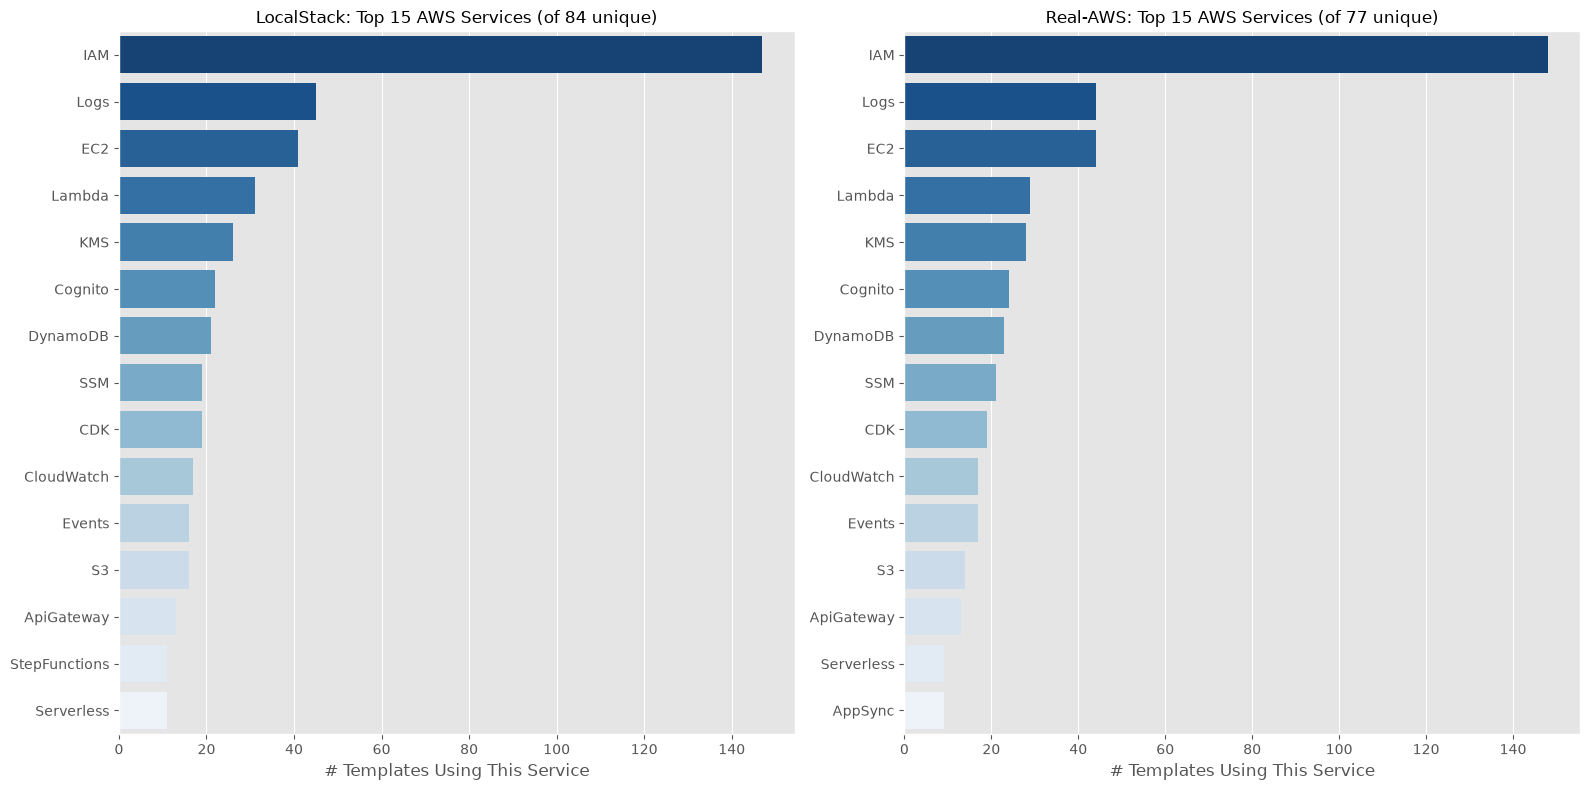

LocalStack: 84 unique AWS services, avg 2.5 services/template
Real-AWS: 77 unique AWS services, avg 2.4 services/template


In [59]:
# ── 13. AWS Service Distribution ──────────────────────────────────────────────
# Mirrors DPIaC-Eval Fig. 3a (top services by template frequency), computed
# per benchmark side by side rather than assuming they share the same
# top-N -- the two candidate pools differ, so their most-common services can
# too.
n_unique_services_by_bench = {}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, bench in zip(axes, BENCHMARK_ORDER):
    d = df_compare[df_compare['benchmark'] == bench]
    if d.empty:
        ax.set_title(f'{bench} (not built yet)', fontsize=12)
        ax.axis('off')
        n_unique_services_by_bench[bench] = 0
        continue
    service_counter = Counter()
    for services in d['aws_services'].dropna():
        for svc in str(services).split(', '):
            if svc:
                service_counter[svc] += 1
    n_unique_services_by_bench[bench] = len(service_counter)
    top_services = pd.DataFrame(service_counter.most_common(15), columns=['Service', 'Templates'])
    sns.barplot(data=top_services, y='Service', x='Templates', hue='Service',
                palette='Blues_r', legend=False, ax=ax)
    ax.set_title(f'{bench}: Top 15 AWS Services (of {len(service_counter)} unique)', fontsize=12)
    ax.set_xlabel('# Templates Using This Service')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

for bench in BENCHMARK_ORDER:
    d = df_compare[df_compare['benchmark'] == bench]
    if d.empty:
        continue
    avg_services = d['aws_services'].dropna().apply(lambda s: len(str(s).split(', '))).mean()
    print(f'{bench}: {n_unique_services_by_bench[bench]} unique AWS services, '
          f'avg {avg_services:.1f} services/template')


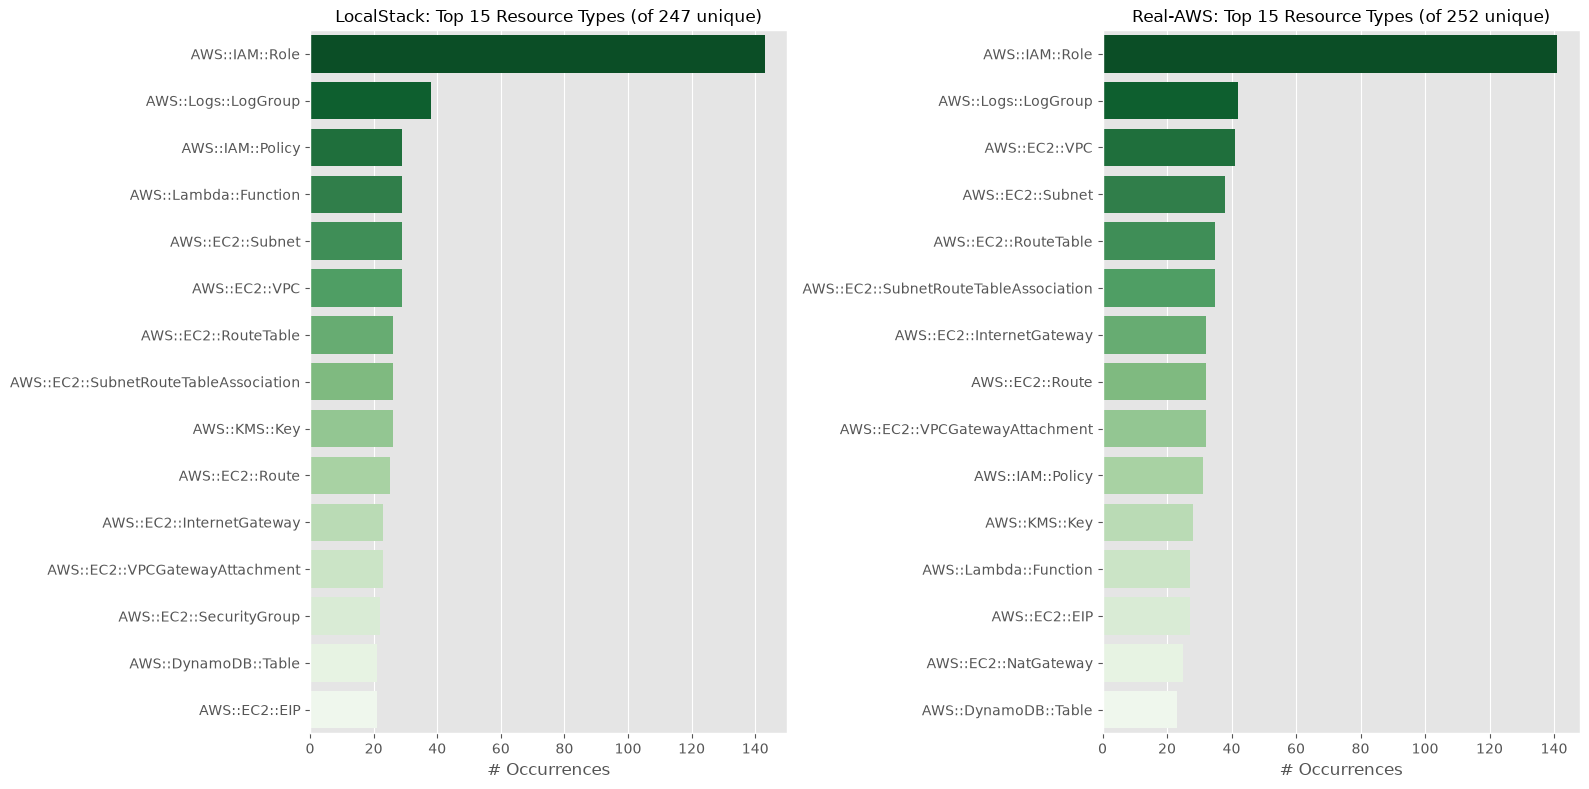

LocalStack: 247 unique CFN resource types represented
Real-AWS: 252 unique CFN resource types represented


In [60]:
# ── 14. CFN Resource Type Distribution ────────────────────────────────────────
n_unique_types_by_bench = {}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, bench in zip(axes, BENCHMARK_ORDER):
    d = df_compare[df_compare['benchmark'] == bench]
    if d.empty:
        ax.set_title(f'{bench} (not built yet)', fontsize=12)
        ax.axis('off')
        n_unique_types_by_bench[bench] = 0
        continue
    resource_type_counter = Counter()
    for types in d['resource_types'].dropna():
        for rtype in str(types).split(' | '):
            if rtype:
                resource_type_counter[rtype] += 1
    n_unique_types_by_bench[bench] = len(resource_type_counter)
    top_types = pd.DataFrame(resource_type_counter.most_common(15), columns=['Resource Type', 'Count'])
    sns.barplot(data=top_types, y='Resource Type', x='Count', hue='Resource Type',
                palette='Greens_r', legend=False, ax=ax)
    ax.set_title(f'{bench}: Top 15 Resource Types (of {len(resource_type_counter)} unique)', fontsize=12)
    ax.set_xlabel('# Occurrences')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

for bench in BENCHMARK_ORDER:
    print(f'{bench}: {n_unique_types_by_bench[bench]} unique CFN resource types represented')


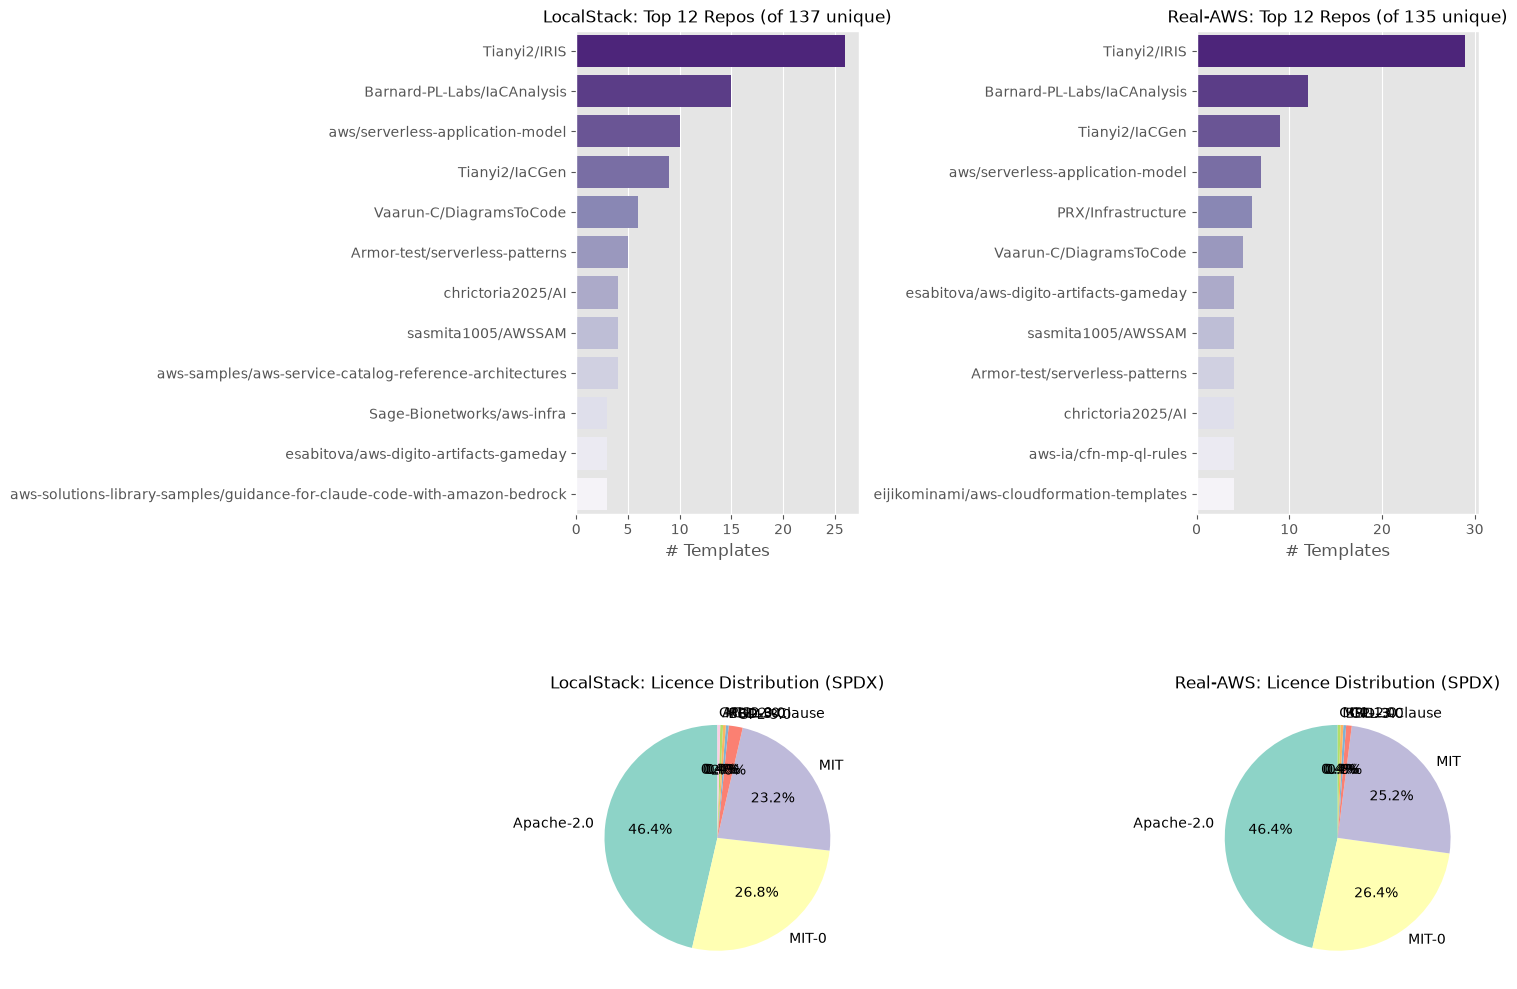

LocalStack: 137 unique source repositories, max 26 templates from a single repo (Tianyi2/IRIS)
Real-AWS: 135 unique source repositories, max 29 templates from a single repo (Tianyi2/IRIS)


In [61]:
# ── 15. Source Diversity & Licensing ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for col, bench in enumerate(BENCHMARK_ORDER):
    d = df_compare[df_compare['benchmark'] == bench]
    ax_repo, ax_lic = axes[0][col], axes[1][col]
    if d.empty:
        ax_repo.set_title(f'{bench} (not built yet)', fontsize=12)
        ax_repo.axis('off')
        ax_lic.axis('off')
        continue

    top_repos = d['source_slug'].value_counts().head(12)
    sns.barplot(y=top_repos.index, x=top_repos.values, hue=top_repos.index,
                ax=ax_repo, palette='Purples_r', legend=False)
    ax_repo.set_title(f'{bench}: Top 12 Repos (of {d["source_slug"].nunique()} unique)', fontsize=12)
    ax_repo.set_xlabel('# Templates')
    ax_repo.set_ylabel('')

    licence_counts = d['licence_spdx'].value_counts()
    ax_lic.pie(licence_counts.values, labels=licence_counts.index, autopct='%1.1f%%',
               startangle=90, colors=sns.color_palette('Set3'))
    ax_lic.set_title(f'{bench}: Licence Distribution (SPDX)', fontsize=12)

plt.tight_layout()
plt.show()

for bench in BENCHMARK_ORDER:
    d = df_compare[df_compare['benchmark'] == bench]
    if d.empty:
        continue
    print(f'{bench}: {d["source_slug"].nunique()} unique source repositories, '
          f'max {d["source_slug"].value_counts().max()} templates from a single repo '
          f'({d["source_slug"].value_counts().idxmax()})')


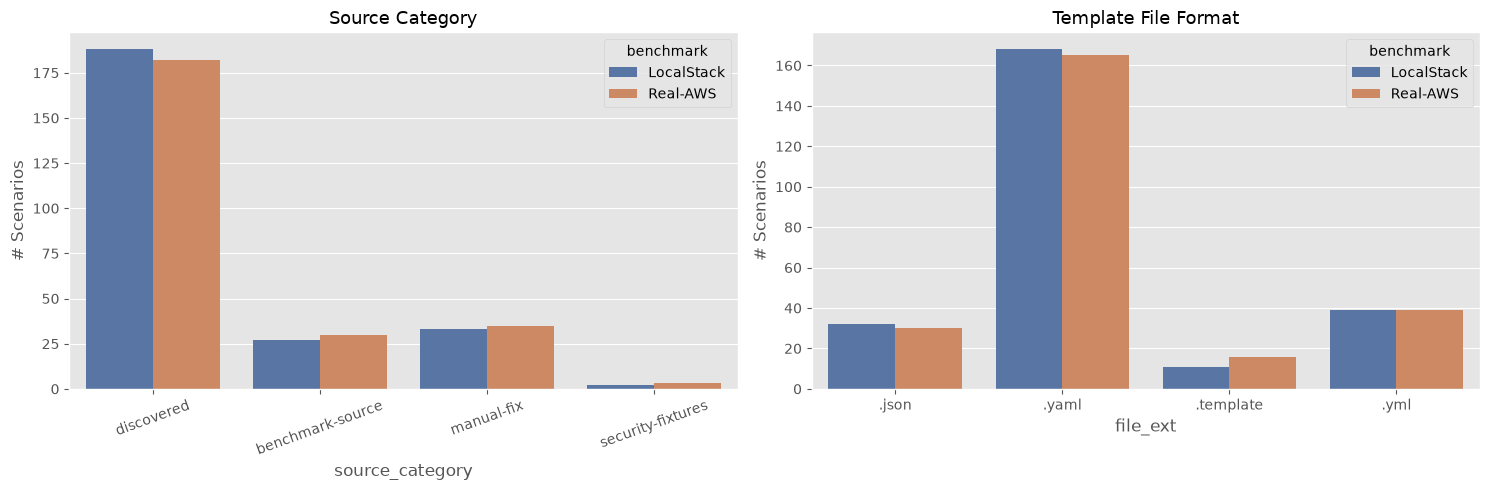

source_category breakdown by benchmark:
source_category  benchmark-source  discovered  manual-fix  security-fixtures
benchmark                                                                   
LocalStack                     27         188          33                  2
Real-AWS                       30         182          35                  3


In [62]:
# ── 16. Source Category & File Format ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df_compare, x='source_category', hue='benchmark', hue_order=BENCHMARK_ORDER,
              palette=BENCHMARK_PALETTE, ax=axes[0])
axes[0].set_title('Source Category', fontsize=13)
axes[0].set_ylabel('# Scenarios')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=df_compare, x='file_ext', hue='benchmark', hue_order=BENCHMARK_ORDER,
              palette=BENCHMARK_PALETTE, ax=axes[1])
axes[1].set_title('Template File Format', fontsize=13)
axes[1].set_ylabel('# Scenarios')

plt.tight_layout()
plt.show()

print('source_category breakdown by benchmark:')
print(df_compare.groupby('benchmark')['source_category'].value_counts().unstack().reindex(BENCHMARK_ORDER).to_string())


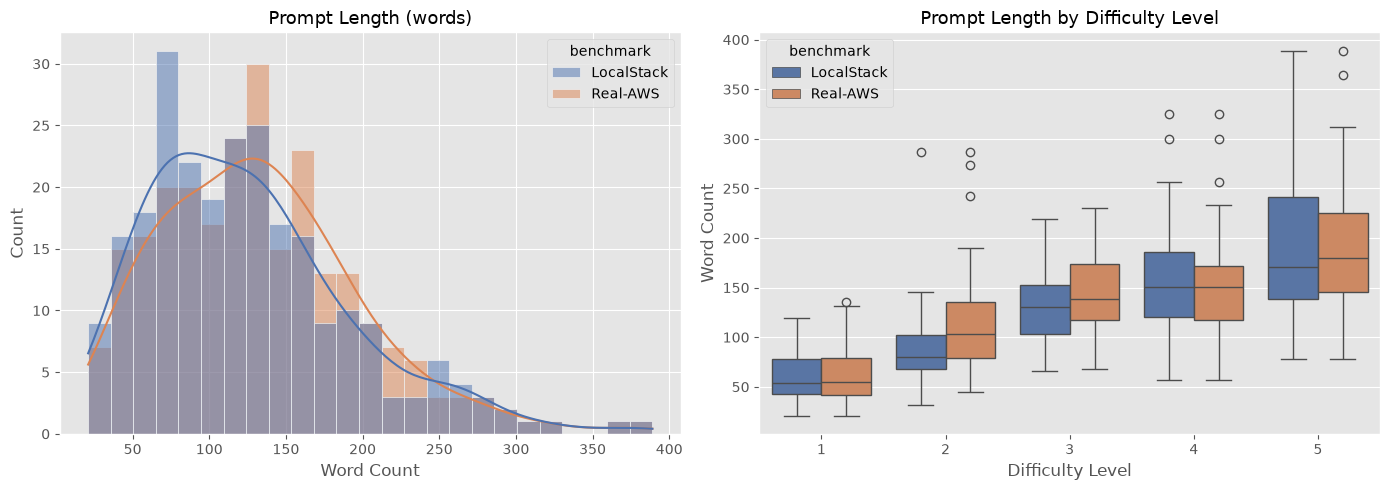


LocalStack (0 scenario(s) still missing a prompt):
       prompt_word_count  prompt_char_count
count              250.0              250.0
mean               125.3              833.2
std                 66.6              454.3
min                 21.0              155.0
25%                 75.2              496.8
50%                117.0              767.0
75%                157.8             1041.8
max                389.0             2574.0

Real-AWS (0 scenario(s) still missing a prompt):
       prompt_word_count  prompt_char_count
count              250.0              250.0
mean               132.5              886.4
std                 64.9              446.3
min                 21.0              155.0
25%                 83.0              548.2
50%                127.0              843.5
75%                169.5             1156.5
max                389.0             2574.0


In [63]:
# ── 17. Prompt Characteristics ────────────────────────────────────────────────
# prompt_word_count / prompt_char_count / has_prompt were computed once in
# section 9 -- blank prompts (not yet backfilled by generate_cfn_prompts.py)
# are excluded via has_prompt so they don't skew the distribution toward
# short "prompts".
_has_prompt = df_compare['has_prompt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_compare[_has_prompt], x='prompt_word_count', hue='benchmark',
             hue_order=BENCHMARK_ORDER, palette=BENCHMARK_PALETTE, bins=25, kde=True,
             ax=axes[0], alpha=0.5)
axes[0].set_title('Prompt Length (words)', fontsize=13)
axes[0].set_xlabel('Word Count')

sns.boxplot(data=df_compare[_has_prompt], x='difficulty', y='prompt_word_count', hue='benchmark',
            hue_order=BENCHMARK_ORDER, palette=BENCHMARK_PALETTE, ax=axes[1])
axes[1].set_title('Prompt Length by Difficulty Level', fontsize=13)
axes[1].set_xlabel('Difficulty Level')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

for bench in BENCHMARK_ORDER:
    d = df_compare[(df_compare['benchmark'] == bench) & _has_prompt]
    if d.empty:
        continue
    n_missing = (df_compare['benchmark'] == bench).sum() - len(d)
    print(f'\n{bench} ({n_missing} scenario(s) still missing a prompt):')
    print(d[['prompt_word_count', 'prompt_char_count']].describe().round(1).to_string())


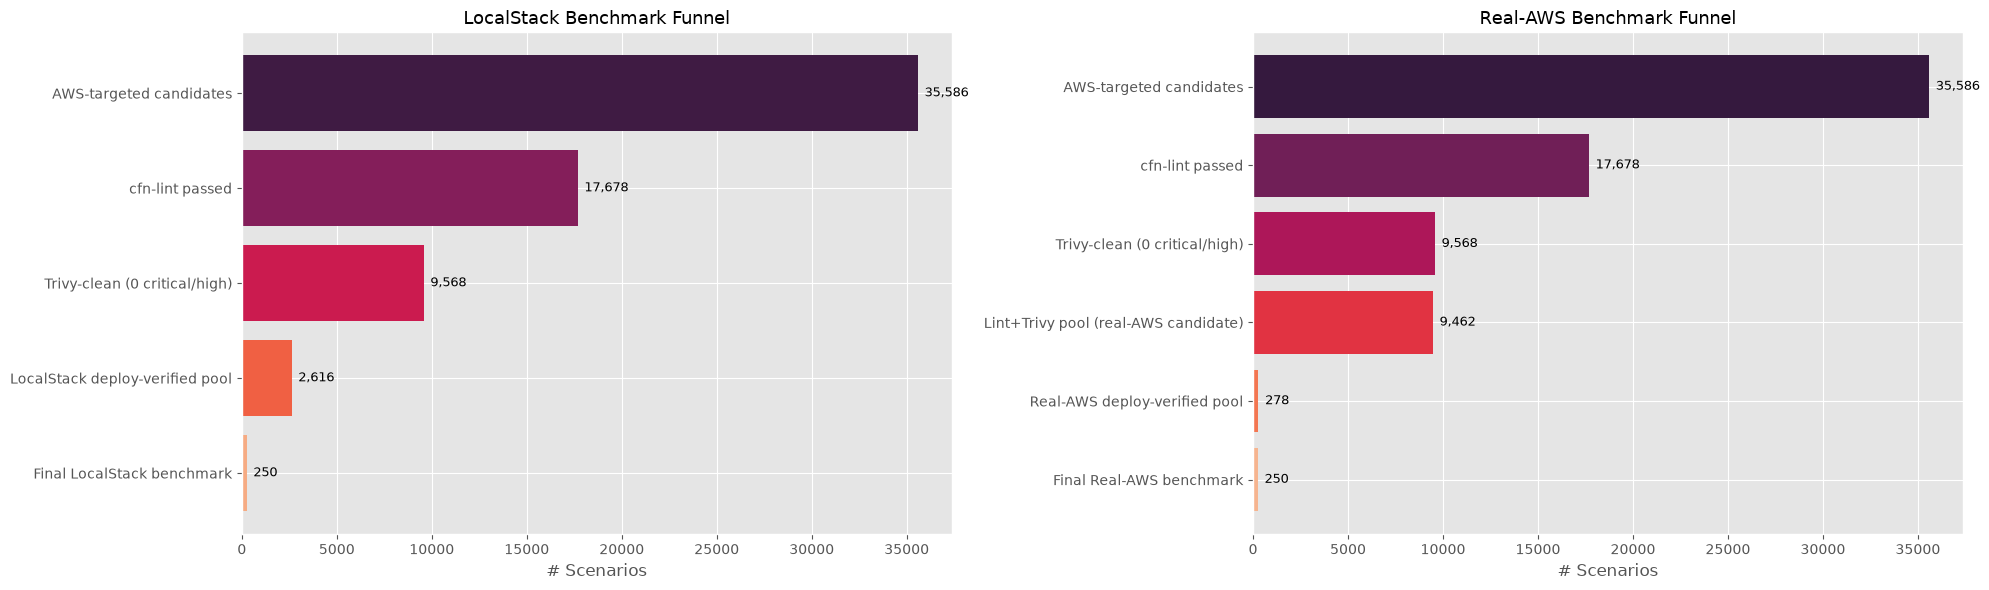

LocalStack overall yield: 250 / 35,586 = 0.7% of AWS-targeted candidates.
Real-AWS overall yield:   250 / 35,586 = 0.7% of AWS-targeted candidates.


In [64]:
# ── 18. Benchmark Construction Funnel ─────────────────────────────────────────
# How each final benchmark was whittled down from the raw discovered pool.
# Both benchmarks share the same upstream gates (AWS-targeted -> cfn-lint ->
# Trivy-clean, all deploy-target-independent) and only diverge at the
# deployability-verification stage: LocalStack's own deploy_cache-gated pool
# (cfn_benchmark.csv) for one, this notebook's own real-AWS
# ground_truth_deploy_check_aws.csv-gated pool for the other. Computed fresh
# from the on-disk caches rather than hardcoded, so it stays accurate across
# reruns.
AWS_CACHE_PATH = DATASET_DIR / 'df_aws_cache.csv'
LINT_CACHE_PATH = DATASET_DIR / 'lint_cache.csv'
SEC_CACHE_PATH = DATASET_DIR / 'security_cache.csv'
LOCALSTACK_DEPLOY_POOL_PATH = DATASET_DIR / 'cfn_benchmark.csv'

shared_stages = []
if AWS_CACHE_PATH.exists():
    df_aws_funnel = pd.read_csv(AWS_CACHE_PATH, low_memory=False)
    shared_stages.append(('AWS-targeted candidates', len(df_aws_funnel)))

    if LINT_CACHE_PATH.exists():
        lint_funnel = pd.read_csv(LINT_CACHE_PATH, low_memory=False)[['content_hash', 'lint_pass']].drop_duplicates('content_hash')
        m = df_aws_funnel.merge(lint_funnel, on='content_hash', how='left')
        lint_passed = m[m['lint_pass'] == True]
        shared_stages.append(('cfn-lint passed', len(lint_passed)))

        if SEC_CACHE_PATH.exists():
            sec_funnel = pd.read_csv(SEC_CACHE_PATH, low_memory=False)[
                ['content_hash', 'trivy_critical', 'trivy_high']].drop_duplicates('content_hash')
            m2 = lint_passed.merge(sec_funnel, on='content_hash', how='left')
            sec_clean = m2[(m2['trivy_critical'].fillna(-1) == 0) & (m2['trivy_high'].fillna(-1) == 0)]
            shared_stages.append(('Trivy-clean (0 critical/high)', len(sec_clean)))

localstack_stages = list(shared_stages)
if LOCALSTACK_DEPLOY_POOL_PATH.exists():
    localstack_pool = pd.read_csv(LOCALSTACK_DEPLOY_POOL_PATH, low_memory=False)
    localstack_stages.append(('LocalStack deploy-verified pool', len(localstack_pool)))
localstack_stages.append(('Final LocalStack benchmark', len(df_localstack)))

# Recompute the real-AWS candidate/deploy-verified pool sizes from their own
# on-disk artifacts rather than assuming df_pool/df_deployable_real are still
# in memory from earlier sections -- this cell should give a correct answer
# even if only sections 9+ were run this session (e.g. re-visualizing an
# already-built pair of benchmarks without rerunning the whole pipeline).
REAL_AWS_POOL_CSV_FUNNEL = DATASET_DIR / 'real_aws_candidate_pool.csv'
GT_DEPLOY_CACHE_PATH_FUNNEL = DATASET_DIR / 'ground_truth_deploy_check_aws.csv'

real_aws_stages = list(shared_stages)
if REAL_AWS_POOL_CSV_FUNNEL.exists():
    real_aws_pool_funnel = pd.read_csv(REAL_AWS_POOL_CSV_FUNNEL, low_memory=False)
    real_aws_stages.append(('Lint+Trivy pool (real-AWS candidate)', len(real_aws_pool_funnel)))
    if GT_DEPLOY_CACHE_PATH_FUNNEL.exists():
        gt_funnel = pd.read_csv(GT_DEPLOY_CACHE_PATH_FUNNEL)[['content_hash', 'deploy_pass']].drop_duplicates('content_hash')
        real_aws_deploy_verified = real_aws_pool_funnel.merge(gt_funnel, on='content_hash', how='inner')
        real_aws_deploy_verified = real_aws_deploy_verified[real_aws_deploy_verified['deploy_pass'] == True]
        real_aws_stages.append(('Real-AWS deploy-verified pool', len(real_aws_deploy_verified)))
real_aws_stages.append(('Final Real-AWS benchmark', len(df_real_aws)))

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, stages, title in zip(
    axes, [localstack_stages, real_aws_stages],
    ['LocalStack Benchmark Funnel', 'Real-AWS Benchmark Funnel'],
):
    funnel_df = pd.DataFrame(stages, columns=['Stage', 'Count'])
    bars = ax.barh(funnel_df['Stage'], funnel_df['Count'], color=sns.color_palette('rocket', len(funnel_df)))
    ax.invert_yaxis()
    ax.set_xlabel('# Scenarios')
    ax.set_title(title, fontsize=13)
    for bar, count in zip(bars, funnel_df['Count']):
        ax.text(bar.get_width() + max(funnel_df['Count']) * 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{count:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

if shared_stages:
    ls_yield = len(df_localstack) / shared_stages[0][1]
    print(f'LocalStack overall yield: {len(df_localstack):,} / {shared_stages[0][1]:,} = {ls_yield:.1%} '
          f'of AWS-targeted candidates.')
    if len(df_real_aws):
        ra_yield = len(df_real_aws) / shared_stages[0][1]
        print(f'Real-AWS overall yield:   {len(df_real_aws):,} / {shared_stages[0][1]:,} = {ra_yield:.1%} '
              f'of AWS-targeted candidates.')


,Benchmark,Scenarios,Avg LoC,Avg # Resources,AWS Services,Difficulty Levels
0,This benchmark (LocalStack),250.0,269.1,10.3,84,5.0
1,This benchmark (Real-AWS),250.0,272.6,10.9,77,5.0
2,DPIaC-Eval,153.0,155.0,7.0,58,5.0
3,IaC-Eval,NaN,42.0,4.0,~60,NaN


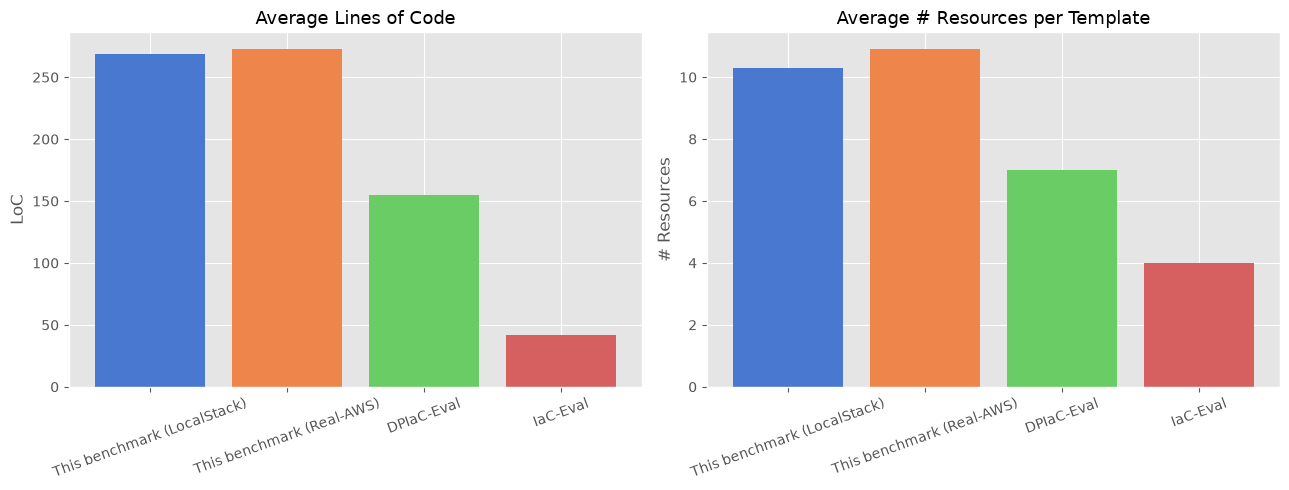

In [66]:
# ── 19. Comparison with Published IaC Benchmarks ─────────────────────────────
# DPIaC-Eval and IaC-Eval numbers are taken directly from Zhang et al. 2025
# (Section 3.2, "Comparison with IaC-Eval Benchmark"): DPIaC-Eval reports an
# average of 155 LoC and 7 resources/template vs IaC-Eval's 42 LoC and 4
# resources/template, across ~60 AWS services each. Both of our own
# benchmarks are shown as separate rows.
comparison = pd.DataFrame({
    'Benchmark': ['This benchmark (LocalStack)', 'This benchmark (Real-AWS)', 'DPIaC-Eval', 'IaC-Eval'],
    'Scenarios': [len(df_localstack), len(df_real_aws) or None, 153, None],
    'Avg LoC': [
        round(df_localstack['loc'].mean(), 1),
        round(df_real_aws['loc'].mean(), 1) if len(df_real_aws) else None,
        155, 42,
    ],
    'Avg # Resources': [
        round(df_localstack['n_resources'].mean(), 1),
        round(df_real_aws['n_resources'].mean(), 1) if len(df_real_aws) else None,
        7, 4,
    ],
    'AWS Services': [
        n_unique_services_by_bench.get('LocalStack'),
        n_unique_services_by_bench.get('Real-AWS') or None,
        58, '~60',
    ],
    'Difficulty Levels': [5, 5 if len(df_real_aws) else None, 5, None],
})
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bench_names = comparison['Benchmark']
avg_loc_plot = pd.to_numeric(comparison['Avg LoC'], errors='coerce').fillna(0)
avg_res_plot = pd.to_numeric(comparison['Avg # Resources'], errors='coerce').fillna(0)

axes[0].bar(bench_names, avg_loc_plot, color=sns.color_palette('muted'))
axes[0].set_title('Average Lines of Code', fontsize=13)
axes[0].set_ylabel('LoC')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(bench_names, avg_res_plot, color=sns.color_palette('muted'))
axes[1].set_title('Average # Resources per Template', fontsize=13)
axes[1].set_ylabel('# Resources')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


In [67]:
# ── 20. Summary Statistics (paper-ready) ─────────────────────────────────────
for bench in BENCHMARK_ORDER:
    d = df_compare[df_compare['benchmark'] == bench]
    print('=' * 70)
    print(f'CFN BENCHMARK SUMMARY — {bench}')
    print('=' * 70)
    if d.empty:
        print('(not built yet)')
        print()
        continue

    n_unique_svc = n_unique_services_by_bench.get(bench, 0)
    n_unique_rtype = n_unique_types_by_bench.get(bench, 0)
    print(f'Total scenarios              : {len(d)}')
    print(f'Difficulty levels            : {sorted(d["difficulty"].unique())} (target 50 each)')
    print(f'Unique AWS services          : {n_unique_svc}')
    print(f'Unique CFN resource types    : {n_unique_rtype}')
    print(f'Unique source repositories   : {d["source_slug"].nunique()}')
    print(f'Licences represented         : {d["licence_spdx"].nunique()} '
          f'({", ".join(sorted(d["licence_spdx"].dropna().unique()))})')
    print()
    print(f'Avg / Median LoC             : {d["loc"].mean():.1f} / {d["loc"].median():.1f}')
    print(f'Avg / Median # Resources     : {d["n_resources"].mean():.1f} / {d["n_resources"].median():.1f}')
    print(f'Avg / Median # Parameters    : {d["n_parameters"].mean():.1f} / {d["n_parameters"].median():.1f}')
    print(f'Avg / Median # Tokens        : {d["tokens"].mean():.1f} / {d["tokens"].median():.1f}')
    _prompt_words = d.loc[d['has_prompt'], 'prompt_word_count']
    if len(_prompt_words):
        print(f'Avg / Median prompt length   : {_prompt_words.mean():.1f} / {_prompt_words.median():.1f} words')
    print()
    print('source_category breakdown:')
    for cat, cnt in d['source_category'].value_counts().items():
        print(f'  {cat:<20s} {cnt:4d}')
    print('=' * 70)
    print()


CFN BENCHMARK SUMMARY — LocalStack
Total scenarios              : 250
Difficulty levels            : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] (target 50 each)
Unique AWS services          : 84
Unique CFN resource types    : 247
Unique source repositories   : 137
Licences represented         : 8 (AGPL-3.0, Apache-2.0, BSD-3-Clause, GPL-2.0, GPL-3.0, MIT, MIT-0, MPL-2.0)

Avg / Median LoC             : 269.1 / 222.5
Avg / Median # Resources     : 10.3 / 7.0
Avg / Median # Parameters    : 2.7 / 1.0
Avg / Median # Tokens        : 2175.2 / 1692.0
Avg / Median prompt length   : 125.3 / 117.0 words

source_category breakdown:
  discovered            188
  manual-fix             33
  benchmark-source       27
  security-fixtures       2

CFN BENCHMARK SUMMARY — Real-AWS
Total scenarios              : 250
Difficulty levels            : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] (target 50 each)
Unique AWS services          : 77
Unique CFN resource

In [39]:
# %%
# ── Add ground-truth code column to the L3/L4/L5 real-AWS eval CSV ───────────
import pandas as pd

DIFF345_EVAL_CSV = DATASET_DIR / 'cfn_eval_benchmark_real_aws_diff345.csv'
OUTPUT_CSV = DATASET_DIR / 'cfn_eval_benchmark_real_aws_diff345_with_code.csv'

df = pd.read_csv(DIFF345_EVAL_CSV)
df['ground_truth_code'] = df['ground_truth_path'].apply(
    lambda p: (BASE_DIR / p).read_text(encoding='utf-8', errors='ignore') if pd.notna(p) else ''
)

df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Wrote {len(df)} rows with ground_truth_code to: {OUTPUT_CSV}")

✅ Wrote 150 rows with ground_truth_code to: cfn_benchmark/dataset/cfn_eval_benchmark_real_aws_diff345_with_code.csv
